# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
secondary_mushroom = fetch_ucirepo(id=848) 
  
# data (as pandas dataframes) 
X = secondary_mushroom.data.features 
y = secondary_mushroom.data.targets 
  
# metadata 
print(secondary_mushroom.metadata) 
  
# variable information 
print(secondary_mushroom.variables)

{'uci_id': 848, 'name': 'Secondary Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/848/data.csv', 'abstract': 'Dataset of simulated mushrooms for binary classification into edible and poisonous.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 61068, 'num_features': 20, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2021, 'last_updated': 'Wed Apr 10 2024', 'dataset_doi': '10.24432/C5FP5Q', 'creators': ['Dennis Wagner', 'D. Heider', 'Georges Hattab'], 'intro_paper': {'ID': 259, 'type': 'NATIVE', 'title': 'Mushroom data creation, curation, and simulation to support classification tasks', 'authors': 'Dennis Wagner, D. Heider, Georges Hattab', 'venue': 'Scientific Reports', 'year': 2021, 'journal': None, '

In [3]:
import pandas as pd

df = pd.concat([X, y], axis=1)
df.head(10)

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,...,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season,class
0,15.26,x,g,o,f,e,NaN,w,16.95,17.09,...,y,w,u,w,t,g,NaN,d,w,p
1,16.60,x,g,o,f,e,NaN,w,17.99,18.19,...,y,w,u,w,t,g,NaN,d,u,p
2,14.07,x,g,o,f,e,NaN,w,17.80,17.74,...,y,w,u,w,t,g,NaN,d,w,p
3,14.17,f,h,e,f,e,NaN,w,15.77,15.98,...,y,w,u,w,t,p,NaN,d,w,p
4,14.64,x,h,o,f,e,NaN,w,16.53,17.20,...,y,w,u,w,t,p,NaN,d,w,p
5,15.34,x,g,o,f,e,NaN,w,17.84,18.79,...,y,w,u,w,t,p,NaN,d,u,p
6,14.85,f,h,o,f,e,NaN,w,17.71,16.89,...,y,w,u,w,t,g,NaN,d,w,p
7,14.86,x,h,e,f,e,NaN,w,17.03,17.44,...,y,w,u,w,t,p,NaN,d,u,p
8,12.85,f,g,o,f,e,NaN,w,17.27,18.69,...,y,w,u,w,t,p,NaN,d,a,p
9,13.55,f,g,e,f,e,NaN,w,16.04,16.88,...,y,w,u,w,t,p,NaN,d,w,p


In [4]:
# for quick computaiton we are considering first 10000 sample 

data = df.sample(n=10000, random_state=48)

# Generating synthetic data

In [6]:
# Import SDV libraries
import sdv
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)


from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# Number of synthetic rows to generate per model
n_samples = 10000

# Define models in one place
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data= data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())


Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 21/21 [00:00<00:00, 132.48it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 119.26it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 21/21 [00:00<00:00, 90.50it/s]|
Column Shapes Score: 92.0%

(2/2) Evaluating Column Pair Trends: |██████████| 210/210 [00:03<00:00, 55.46it/s]|
Column Pair Trends Score: 83.79%

Overall Score (Average): 87.89%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 21/21 [00:00<00:00, 253.74it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 200.97it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 21/21 [00:00<00:00, 132.14it/s]|
Column Shapes Score: 92.64%

(2/2) Eva

,Model,Diagnostic Score,Quality Score
0,TVAE,1.0,0.914558
1,GaussianCopula,1.0,0.909833
2,CopulaGAN,1.0,0.892834
3,CTGAN,1.0,0.878921



Best model by quality score: TVAE


,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,...,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season,class
0,4.96,p,y,w,f,NaN,c,g,5.14,6.03,...,NaN,w,NaN,NaN,f,f,NaN,m,s,e
1,9.43,f,t,y,f,x,NaN,y,6.97,19.10,...,NaN,n,NaN,NaN,f,f,NaN,d,a,p
2,9.06,x,e,y,f,a,c,w,10.41,22.42,...,y,u,NaN,NaN,f,f,NaN,d,a,e
3,6.72,o,w,n,f,f,f,w,4.61,18.16,...,NaN,n,NaN,NaN,f,f,NaN,d,s,e
4,6.98,b,h,n,f,e,c,w,9.37,11.06,...,NaN,w,NaN,w,t,l,NaN,d,a,p


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 357.84it/s]|
Column Shapes Score: 91.79%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:00<00:00, 270.59it/s]|
Column Pair Trends Score: 83.79%

Overall Score (Average): 87.79%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 524.65it/s]|
Column Shapes Score: 92.33%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:00<00:00, 291.34it/s]|
Column Pair Trends Score: 85.93%

Overall Score (Average): 89.13%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 359.52it/s]|
Column Shapes Score: 92.2%

(2/2) Evaluating Column Pair Trends: |██████████| 190/190 [00:00<00:00, 268.75it/s]|
Column Pair Trends Score: 90.34%

Overall Score (Average): 91.27%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 20/20 [00:00<00:00, 467.35it/s]|
Column Shapes Score: 98.4%

(2/2) Evaluating Column Pa

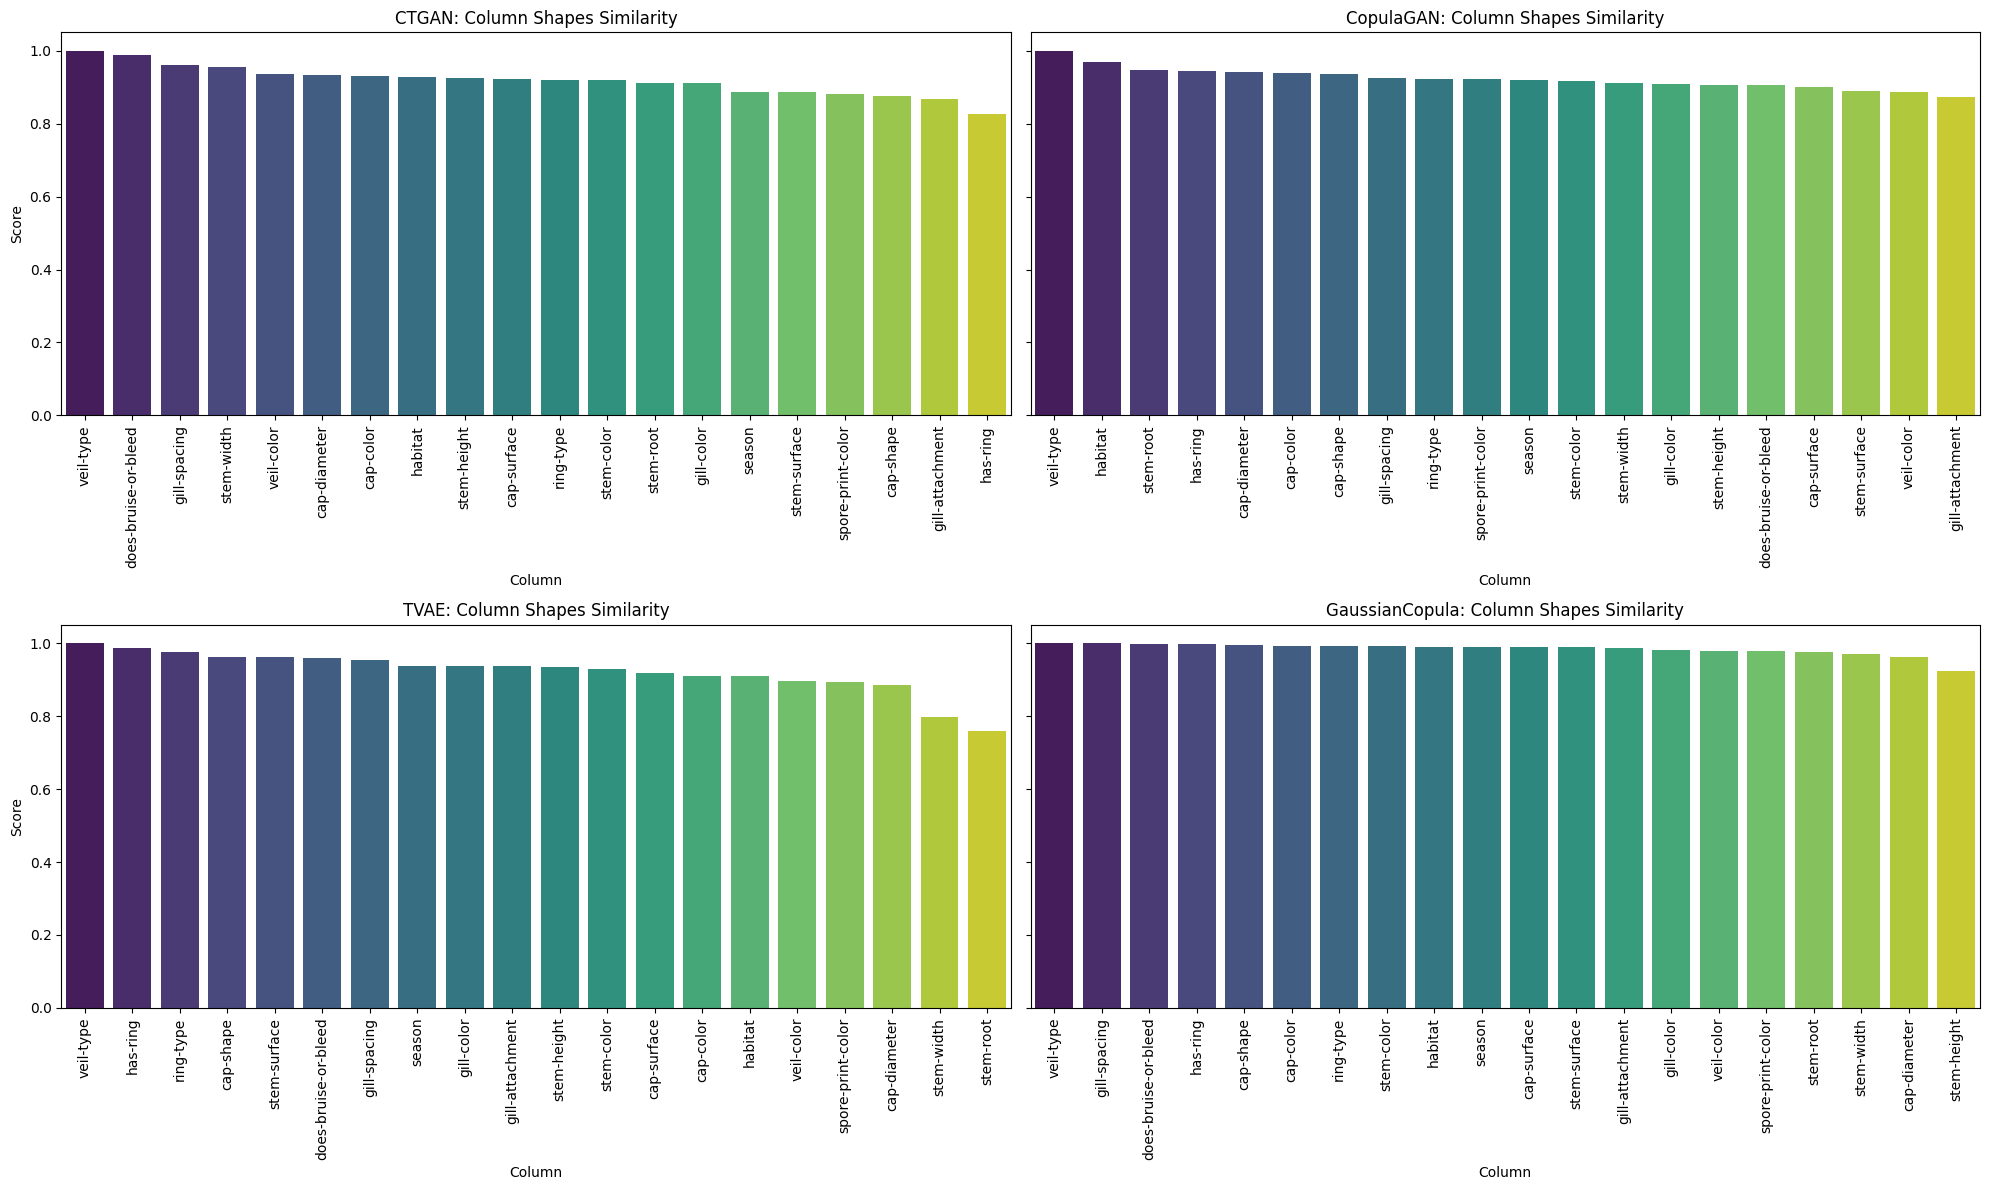

                  Column        Metric     Score  Model
0              veil-type  TVComplement  1.000000  CTGAN
1   does-bruise-or-bleed  TVComplement  0.986700  CTGAN
2           gill-spacing  TVComplement  0.960662  CTGAN
3             stem-width  KSComplement  0.954500  CTGAN
4             veil-color  TVComplement  0.935548  CTGAN
5           cap-diameter  KSComplement  0.932400  CTGAN
6              cap-color  TVComplement  0.929500  CTGAN
7                habitat  TVComplement  0.927500  CTGAN
8            stem-height  KSComplement  0.925900  CTGAN
9            cap-surface  TVComplement  0.923477  CTGAN
10             ring-type  TVComplement  0.920472  CTGAN
11            stem-color  TVComplement  0.918400  CTGAN
12             stem-root  TVComplement  0.910530  CTGAN
13            gill-color  TVComplement  0.910200  CTGAN
14                season  TVComplement  0.886000  CTGAN
15          stem-surface  TVComplement  0.885966  CTGAN
16     spore-print-color  TVComplement  0.880660

In [9]:
import warnings
warnings.filterwarnings("ignore")

from sdv.evaluation.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "class"

real_eval = data.drop(columns=[target_col], errors="ignore").copy()

metadata_eval = SingleTableMetadata()
metadata_eval.detect_from_dataframe(real_eval)

column_shape_details = {}

for model_name in model_order:
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synth_eval.reindex(columns=real_eval.columns)

    qr = QualityReport()
    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata_eval.to_dict()
    )

    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column",
        y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)

print(combined_details.head(20))

### 1.2. Jensen–Shannon divergence

In [10]:
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    real = pd.to_numeric(real, errors="coerce").dropna().to_numpy()
    synth = pd.to_numeric(synth, errors="coerce").dropna().to_numpy()

    if len(real) == 0 or len(synth) == 0:
        return np.array([0.5, 0.5]), np.array([0.5, 0.5])

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)

    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame, synth_df: pd.DataFrame, bins=30, normalize=True) -> pd.DataFrame:
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        if num_cols:
            scaler = MinMaxScaler()
            real[num_cols] = scaler.fit_transform(real[num_cols])
            synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        js_div = jensenshannon(p, q, base=2) ** 2
        results.append({"Feature": col, "JS_Divergence": float(js_div)})

    return pd.DataFrame(results).sort_values("JS_Divergence", ascending=False).reset_index(drop=True)

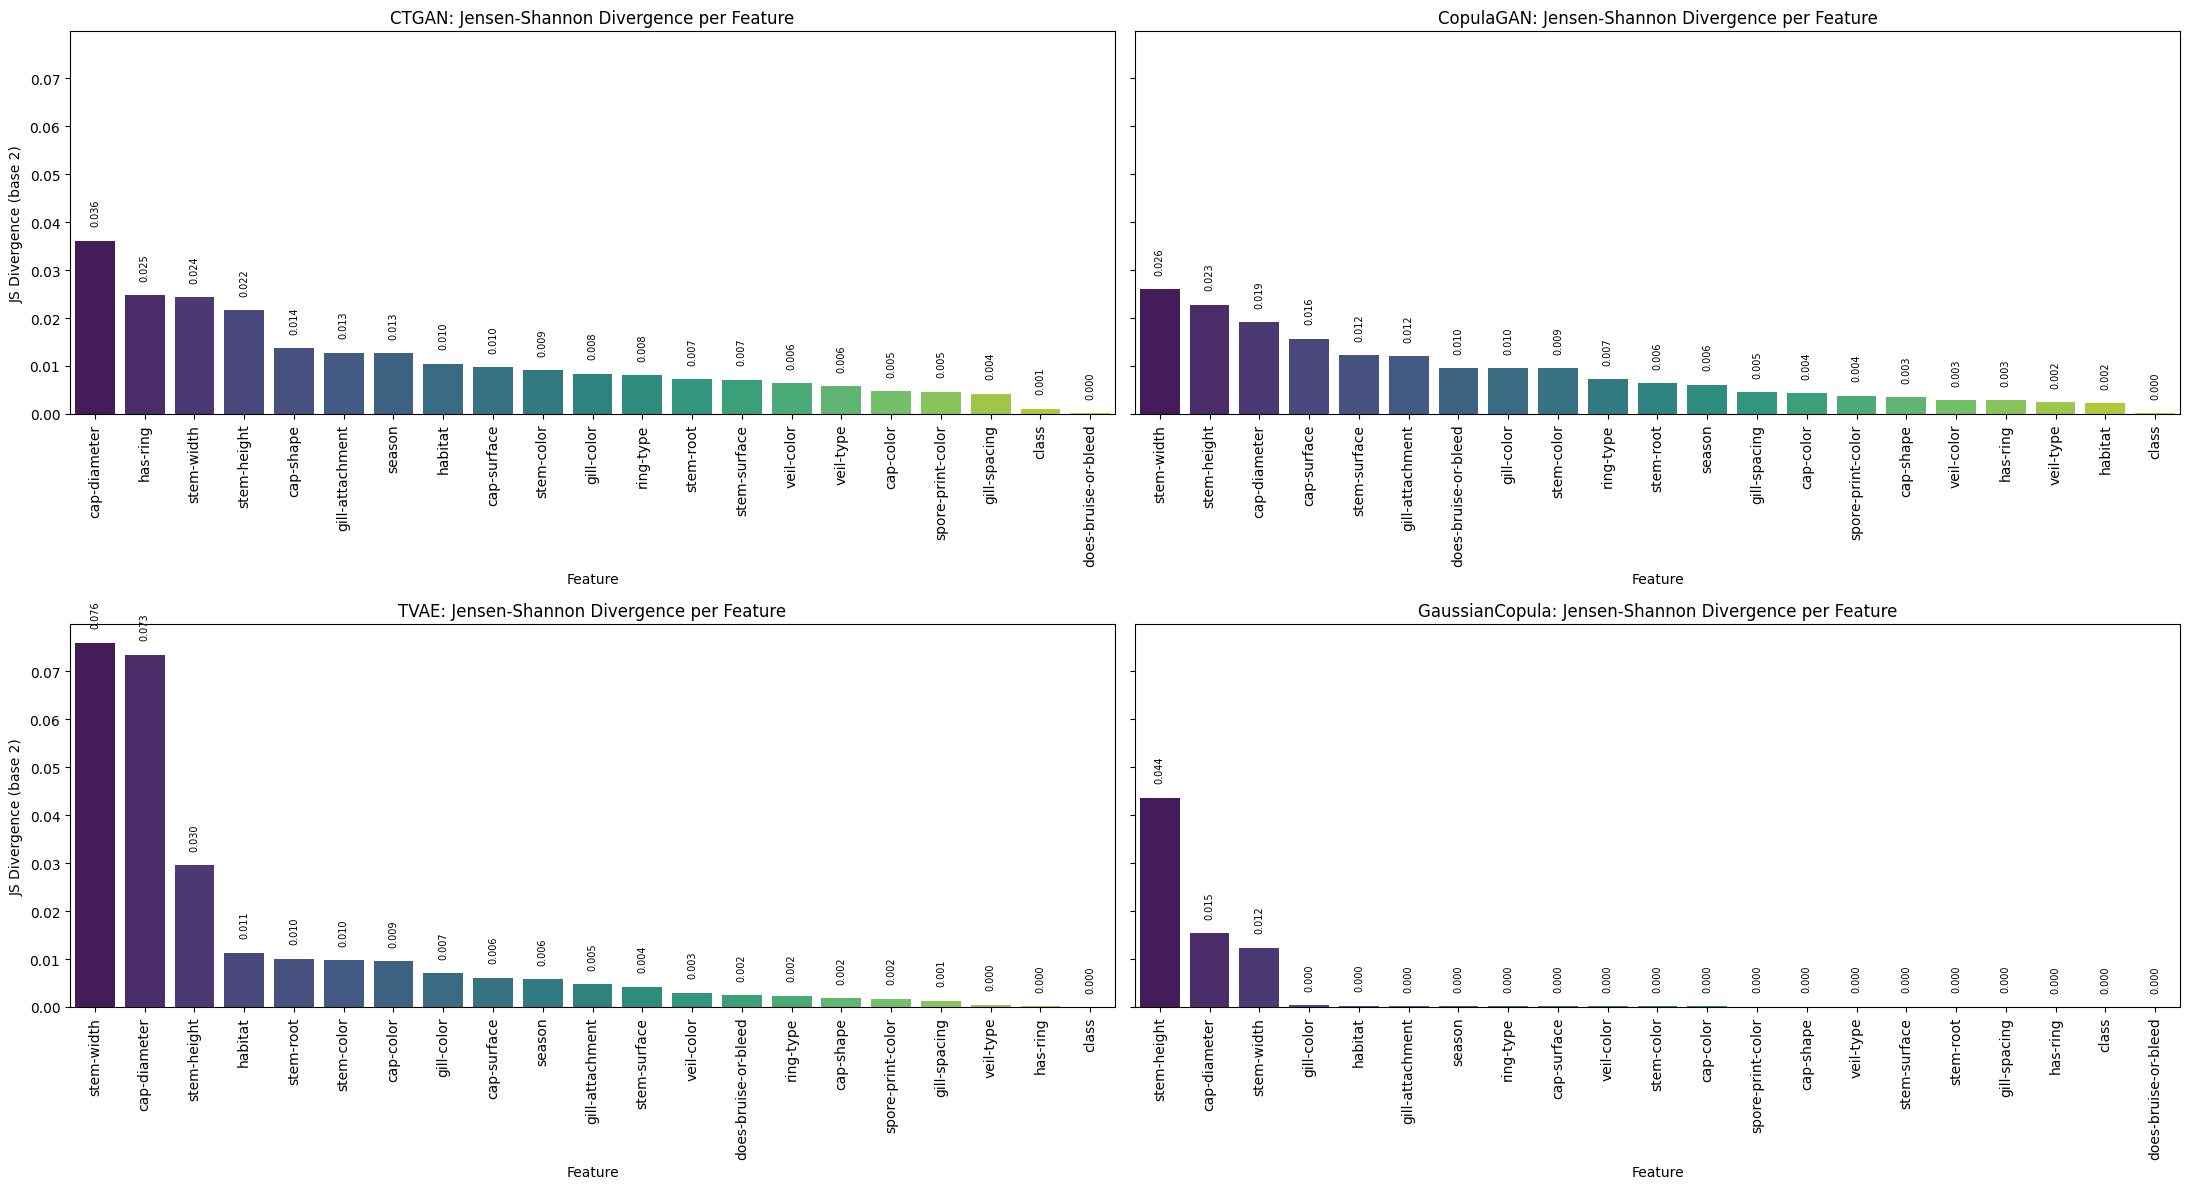

,Feature,JS_Divergence,Model
0,cap-diameter,0.036141,CTGAN
1,has-ring,0.024758,CTGAN
2,stem-width,0.024386,CTGAN
3,stem-height,0.021663,CTGAN
4,cap-shape,0.013728,CTGAN
5,gill-attachment,0.012757,CTGAN
6,season,0.012672,CTGAN
7,habitat,0.010460,CTGAN
8,cap-surface,0.009707,CTGAN
9,stem-color,0.009103,CTGAN


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"

js_results_by_model = {}

for model_name in model_order:
    real_eval = data.drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()

    common_cols = real_eval.columns.intersection(synth_eval.columns)
    real_eval = real_eval[common_cols]
    synth_eval = synth_eval[common_cols]

    js_df = compute_js_divergence(
        real_eval,
        synth_eval,
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)

    js_results_by_model[model_name] = js_df

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]

    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

### 1.3 Wasserstein Distance



CTGAN - Wasserstein Distance:
cap-diameter: 0.0087
stem-height: 0.0109
stem-width: 0.0106

CopulaGAN - Wasserstein Distance:
cap-diameter: 0.0036
stem-height: 0.0123
stem-width: 0.0128

TVAE - Wasserstein Distance:
cap-diameter: 0.0182
stem-height: 0.0160
stem-width: 0.0306

GaussianCopula - Wasserstein Distance:
cap-diameter: 0.0075
stem-height: 0.0170
stem-width: 0.0062

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,CopulaGAN,0.009572,0.012347,0.012771
1,CTGAN,0.010058,0.010559,0.010900
2,GaussianCopula,0.010206,0.007453,0.016970
3,TVAE,0.021590,0.018210,0.030566


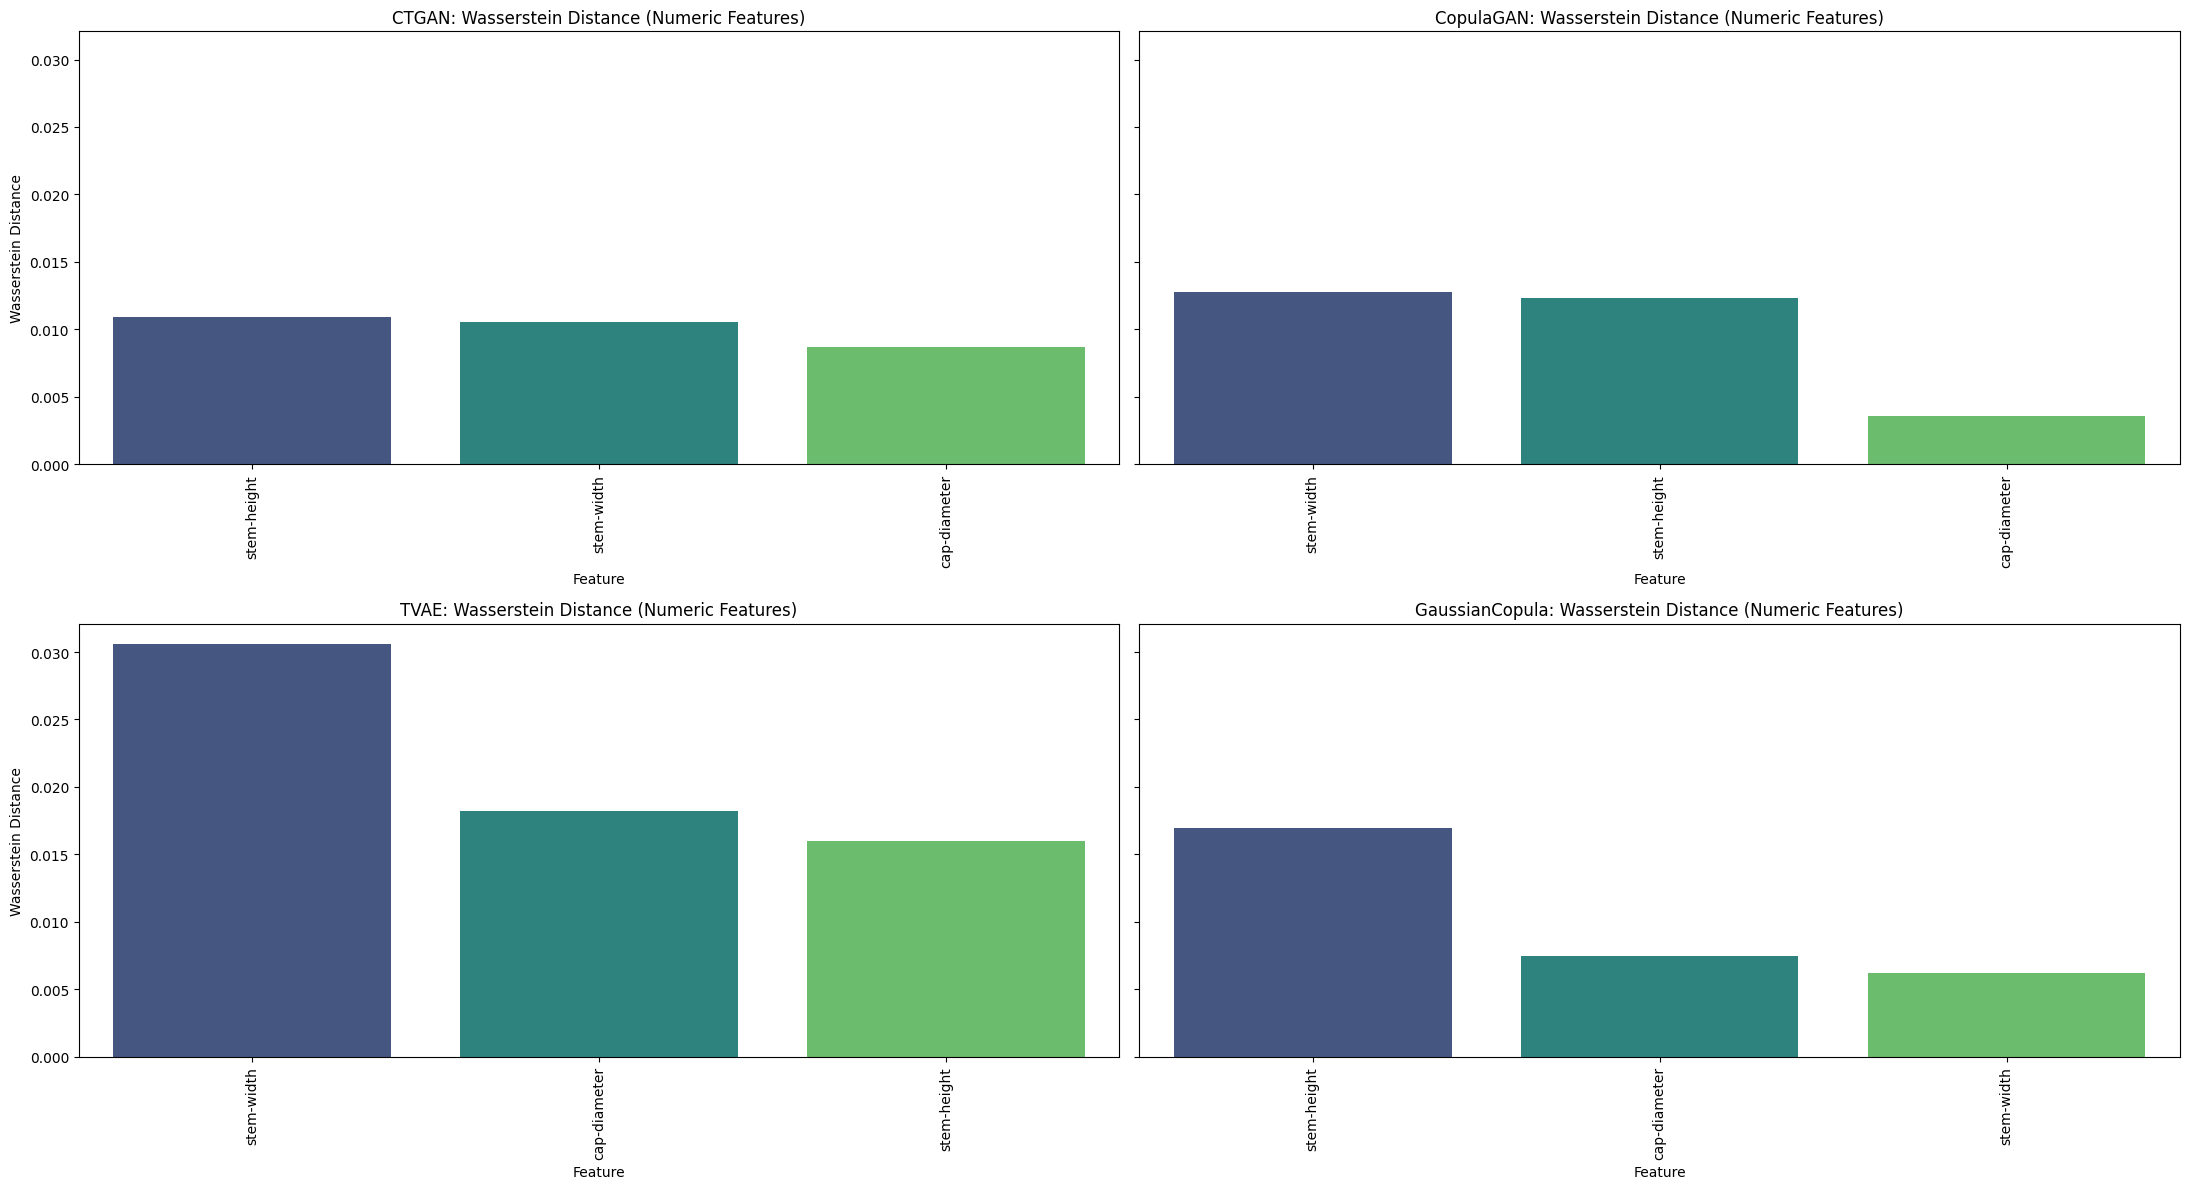

In [12]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "traffic_volume"

# Use numeric features only (Wasserstein here is numeric-distribution based)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != target_col]

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data[feature_cols]),
    columns=feature_cols
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name][data.columns].copy()

    # keep same numeric feature set/order
    synth_num = synth_df[feature_cols].copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=feature_cols
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in feature_cols:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, float(dist)))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": float(dist_df["Wasserstein_Distance"].mean()),
        "Median_Wasserstein": float(dist_df["Wasserstein_Distance"].median()),
        "Max_Wasserstein": float(dist_df["Wasserstein_Distance"].max()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance (Numeric Features)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [15]:
import numpy as np
import pandas as pd
import gower

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "class"
drop_cols = [target_col]

X_real = data.drop(columns=drop_cols, errors="ignore").copy()

gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True).copy()
    Xs = X_synth[common_cols].reset_index(drop=True).copy()

    num_cols = Xr.select_dtypes(include=[np.number]).columns
    Xr[num_cols] = Xr[num_cols].astype(np.float64)
    Xs[num_cols] = Xs[num_cols].astype(np.float64)

    gower_real = 1.0 - gower.gower_matrix(Xr)
    gower_synth = 1.0 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = float(np.max(real_upper))
    avg_intra_real = float(np.mean(real_upper))
    max_intra_synth = float(np.max(synth_upper))
    avg_intra_synth = float(np.mean(synth_upper))

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1.0 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = float(np.max(cross_block))
    avg_cross = float(np.mean(cross_block))

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)


CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.8998, Avg = 0.3458

Intra-set Similarity (Synthetic):
Max = 0.8991, Avg = 0.3372

Cross-set Similarity (Real vs Synthetic):
Max = 0.8498, Avg = 0.3382

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.8998, Avg = 0.3458

Intra-set Similarity (Synthetic):
Max = 0.8999, Avg = 0.3309

Cross-set Similarity (Real vs Synthetic):
Max = 0.8981, Avg = 0.3363

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.8998, Avg = 0.3458

Intra-set Similarity (Synthetic):
Max = 0.8987, Avg = 0.3707

Cross-set Similarity (Real vs Synthetic):
Max = 0.8995, Avg = 0.3575

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.8998, Avg = 0.3458

Intra-set Similarity (Synthetic):
Max = 0.7476, Avg = 0.3425

Cross-set Similarity (Real vs Synthetic):
Max = 0.7485, Avg = 0.3451


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,0.899795,0.345825,0.899072,0.337168,0.849781,0.338231
1,CopulaGAN,0.899795,0.345825,0.899948,0.330869,0.898077,0.336320
2,TVAE,0.899795,0.345825,0.898735,0.370707,0.899512,0.357493
3,GaussianCopula,0.899795,0.345825,0.747648,0.342463,0.748515,0.345135


### 1.5 t-SNE Visualization


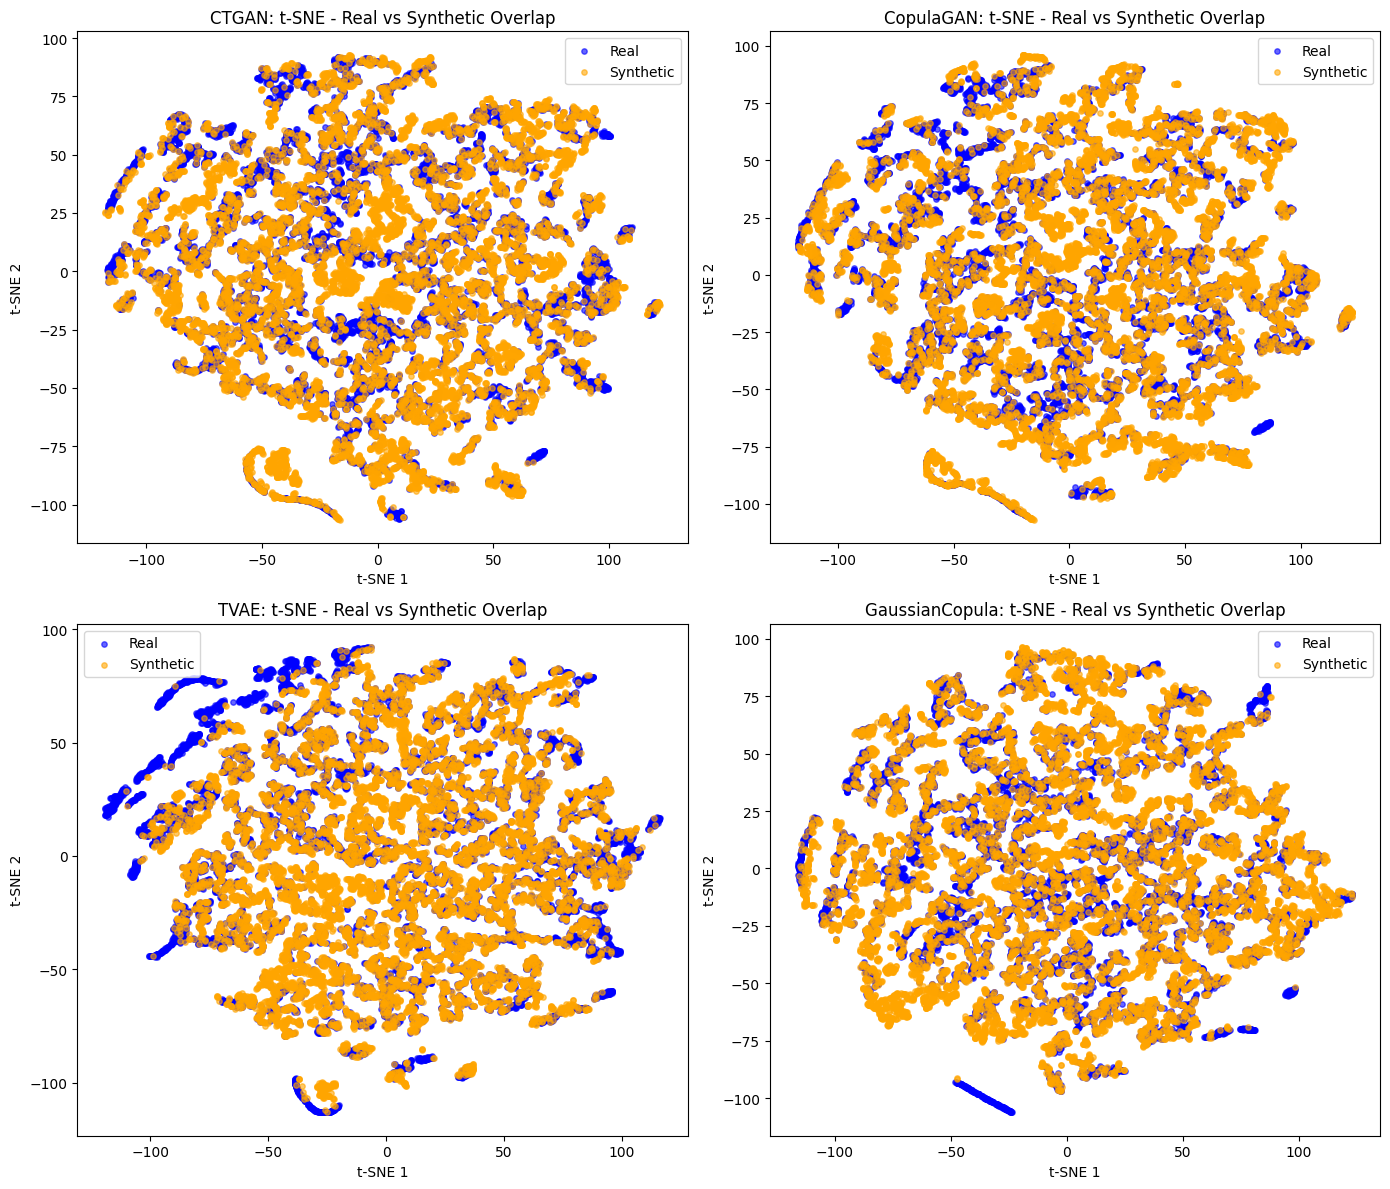

In [16]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "class"

# Keep only numeric feature columns and exclude the target
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_num = data[feature_cols].copy()

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_num),
    columns=feature_cols
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name].copy()

    # Keep only matching numeric feature columns
    synth_num = synth_df.reindex(columns=feature_cols).copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=feature_cols
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(
        n_components=2,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue",
        alpha=0.6,
        s=15,
        label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange",
        alpha=0.6,
        s=15,
        label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [17]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

def _sample_rows(X, max_rows=2000, seed=42):
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

def _median_gamma(X, Y):
    Z = np.vstack([X, Y])
    n = Z.shape[0]
    take = min(1200, n)
    idx = np.random.default_rng(42).choice(n, size=take, replace=False)
    Zs = Z[idx]
    d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
    vals = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return 1.0 / (2.0 * med)

def compute_mmd_rbf_safe(X, Y, gamma=None):
    if gamma is None:
        gamma = _median_gamma(X, Y)
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "class"
drop_cols = [target_col]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()

# Keep numeric only for RBF MMD
real_features = real_features.select_dtypes(include=[np.number]).copy()

mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    Xr = _sample_rows(X_real_scaled, max_rows=2000, seed=42)
    Xs = _sample_rows(X_synth_scaled, max_rows=2000, seed=42)

    mmd_score = compute_mmd_rbf_safe(Xr, Xs, gamma=None)
    mmd_results.append({"Model": model_name, "MMD_Score": float(mmd_score)})

    print(f"{model_name} - MMD score: {mmd_score:.6f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)


CTGAN - MMD score: 0.004656
CopulaGAN - MMD score: 0.006614
TVAE - MMD score: 0.027479
GaussianCopula - MMD score: 0.002653

MMD comparison (lower is better):


,Model,MMD_Score
0,GaussianCopula,0.002653
1,CTGAN,0.004656
2,CopulaGAN,0.006614
3,TVAE,0.027479


### 1.7 Cosine Similarity


In [18]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "class"
drop_cols = [target_col]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_features = real_features.select_dtypes(include=[np.number]).copy()

similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = float(np.mean(cross_sim))
    max_sim = float(np.max(cross_sim))

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: 0.0289
Maximum cosine similarity: 1.0000

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: 0.0146
Maximum cosine similarity: 1.0000

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0384
Maximum cosine similarity: 1.0000

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: 0.0268
Maximum cosine similarity: 1.0000

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.038429,1.0
1,CTGAN,0.028863,1.0
2,GaussianCopula,0.026794,1.0
3,CopulaGAN,0.014609,1.0


### 1.8 Nearest Neighbours 


In [19]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "class"
drop_cols = [target_col]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
real_features = real_features.select_dtypes(include=[np.number]).copy()

privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    synth_features = synth_features.select_dtypes(include=[np.number]).copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = float(np.mean(distances))
    min_nn_dist = float(np.min(distances))
    p5_nn_dist = float(np.percentile(distances, 5))

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.1594
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.0175

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.1683
Minimum NN Distance (Synthetic -> Real): 0.0000
5th Percentile NN Distance: 0.0174

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.0822
Minimum NN Distance (Synthetic -> Real): 0.0019
5th Percentile NN Distance: 0.0179

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.1326
Minimum NN Distance (Synthetic -> Real): 0.0020
5th Percentile NN Distance: 0.0207

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,CopulaGAN,0.168347,0.000000,0.017392
1,CTGAN,0.159398,0.000000,0.017528
2,GaussianCopula,0.132641,0.001952,0.020658
3,TVAE,0.082171,0.001909,0.017908


# 2. Stats

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,3.741476,3.537238,5.865425
1,CopulaGAN,5.295110,5.162361,6.301205
2,TVAE,3.943863,3.699088,29.795889
3,GaussianCopula,1.336700,1.856007,5.820726


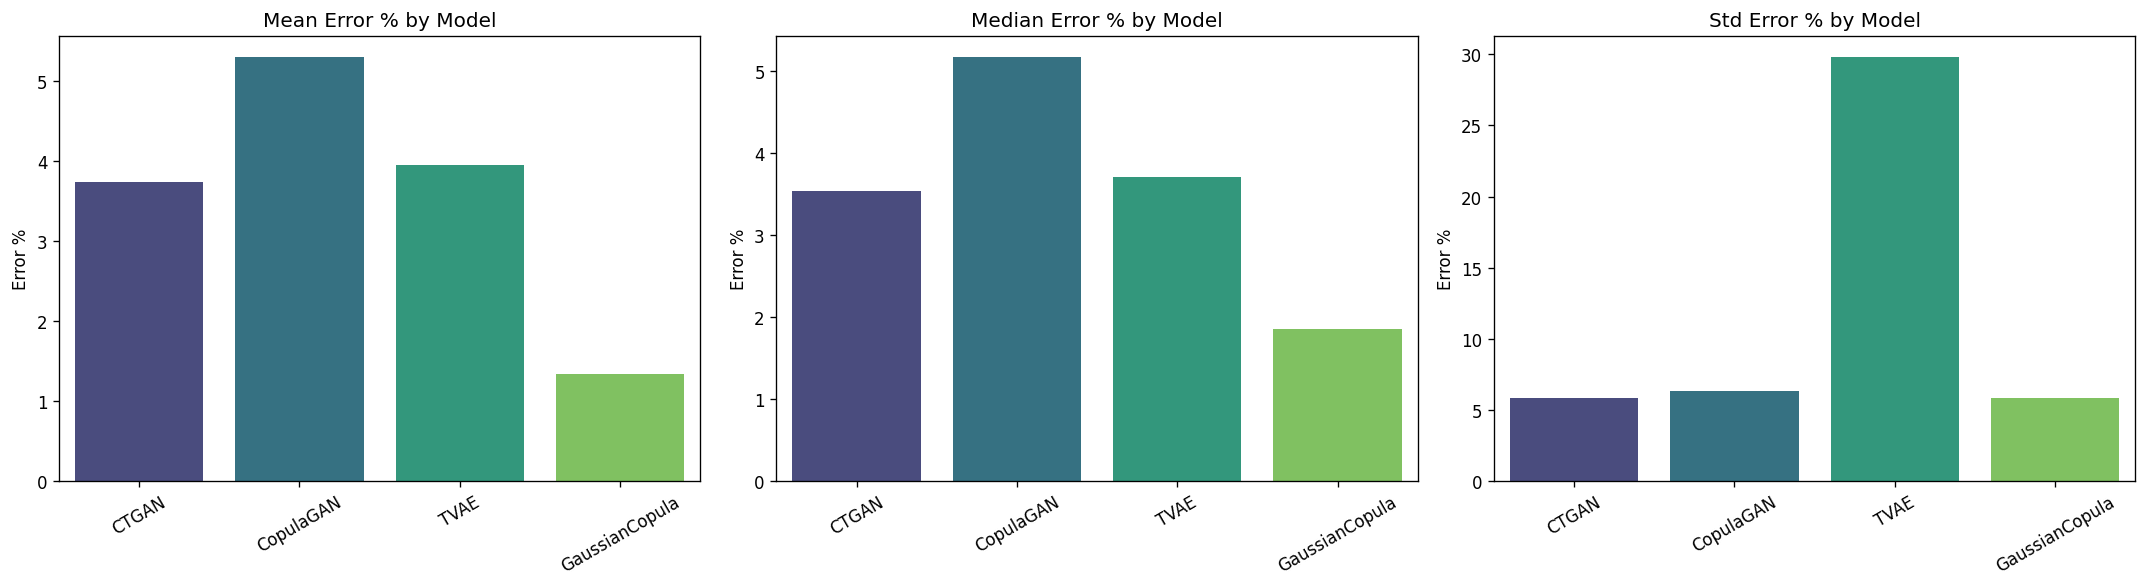

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "class"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.reindex(columns=real_df.columns)

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100.0
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100.0

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()

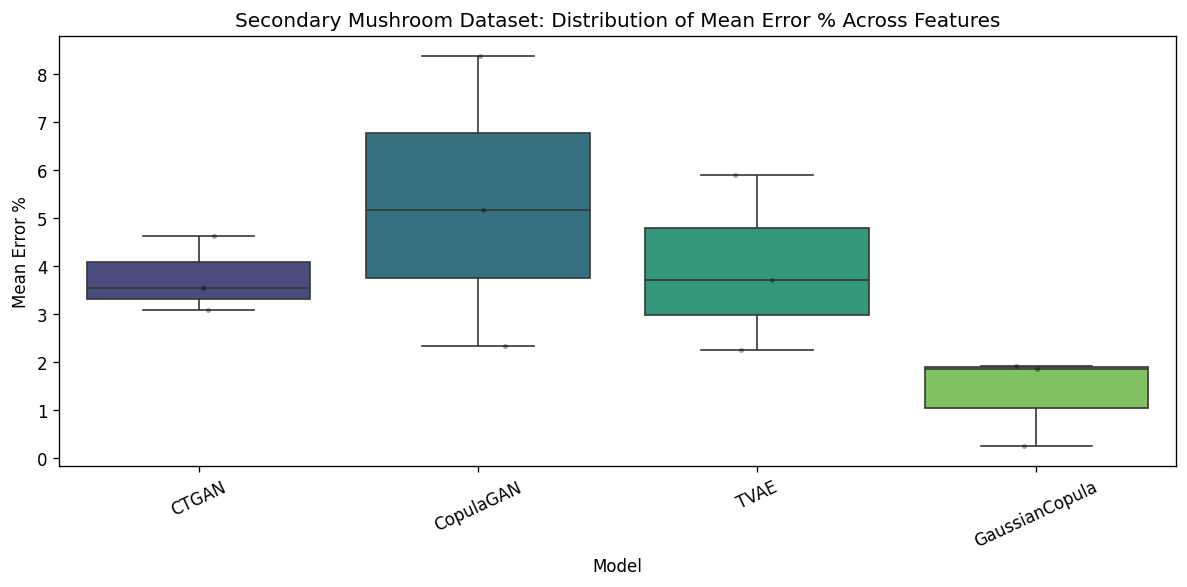

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)

plt.title("Secondary Mushroom Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

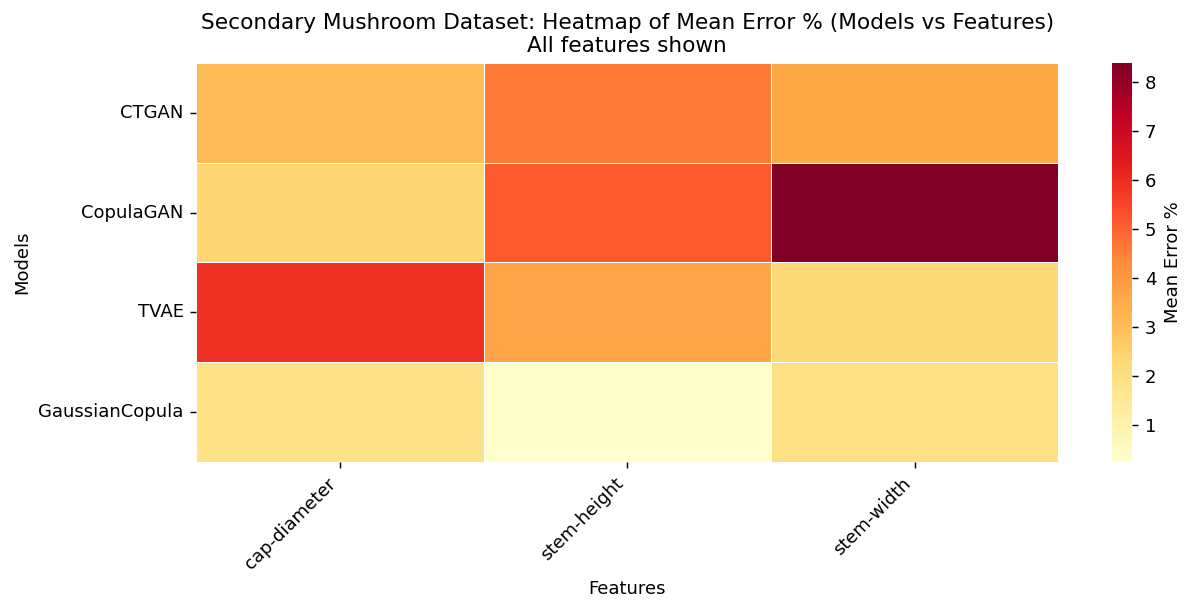

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Secondary Mushroom Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [25]:
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality_mushroom(real_df, synth_df, target="class"):
    common_cols = real_df.columns.intersection(synth_df.columns)

    real_df = real_df[common_cols].copy()
    synth_df = synth_df[common_cols].copy()

    num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c != target]

    if len(num_cols) == 0:
        return (
            pd.DataFrame(columns=["var_a", "var_b", "delta_corr"]),
            pd.DataFrame(columns=["feature", "delta_target_relation"])
        )

    scaler = MinMaxScaler()
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    corr_df = (
        pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
        if results_corr else
        pd.DataFrame(columns=["var_a", "var_b", "delta_corr"])
    )

    target_df = pd.DataFrame(columns=["feature", "delta_target_relation"])
    return corr_df, target_df


In [26]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = data.copy()
target_col = "class"

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.reindex(columns=real_df.columns)

    corr_results, target_results = bivariate_quality_mushroom(
        real_df=real_df,
        synth_df=synth_df,
        target=target_col
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))

    print(f"\n{model_name} - Features that differ most by relation to {target_col}:")
    display(target_results.head(10))

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results["delta_corr"].iloc[0] if not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results["delta_corr"].head(10).mean() if not corr_results.empty else None,
        "TopTargetDiff": target_results["delta_target_relation"].iloc[0] if not target_results.empty else None,
        "MeanTop10TargetDiff": target_results["delta_target_relation"].head(10).mean() if not target_results.empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
1,cap-diameter,stem-width,0.327562
2,stem-height,stem-width,0.161475
0,cap-diameter,stem-height,0.084363



CTGAN - Features that differ most by relation to class:


,feature,delta_target_relation



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
1,cap-diameter,stem-width,0.089522
2,stem-height,stem-width,0.062725
0,cap-diameter,stem-height,0.034047



GaussianCopula - Features that differ most by relation to class:


,feature,delta_target_relation


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,0.327562,0.191134,None,None
1,CopulaGAN,0.362680,0.226248,None,None
2,TVAE,0.157087,0.121318,None,None
3,GaussianCopula,0.089522,0.062098,None,None


### 3 Multivariate Analysis


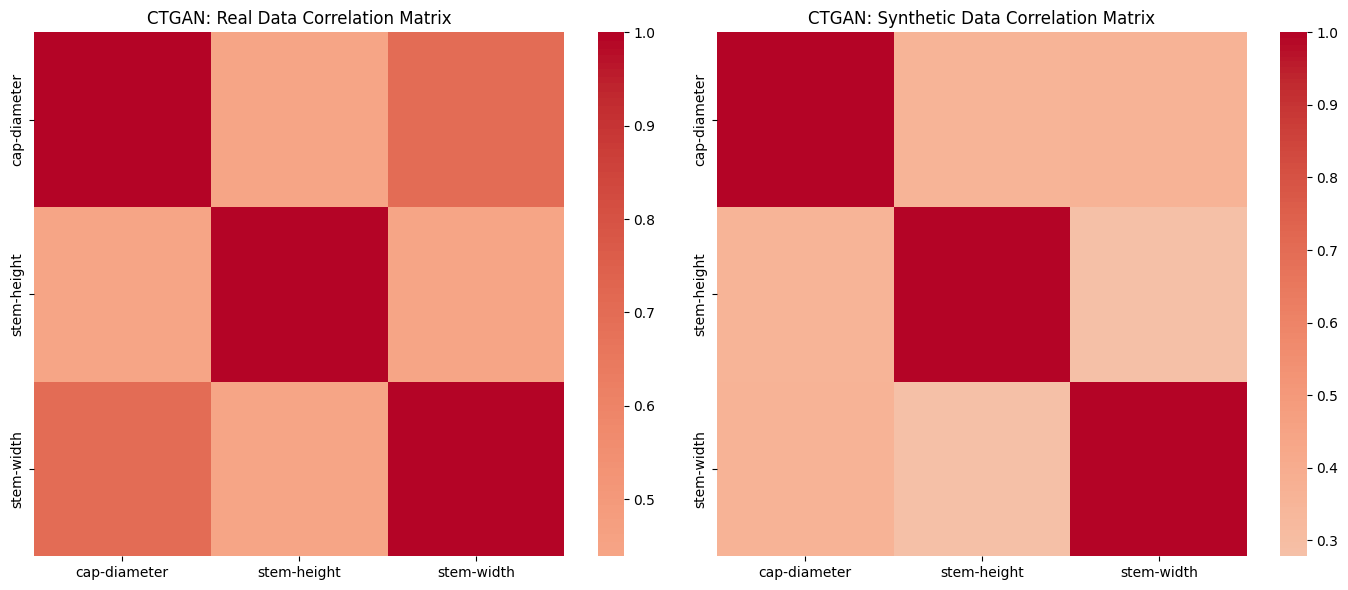

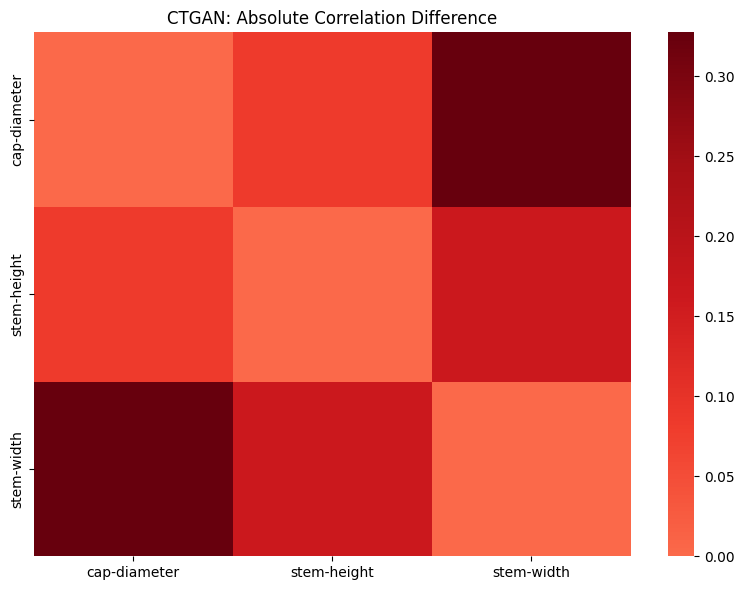

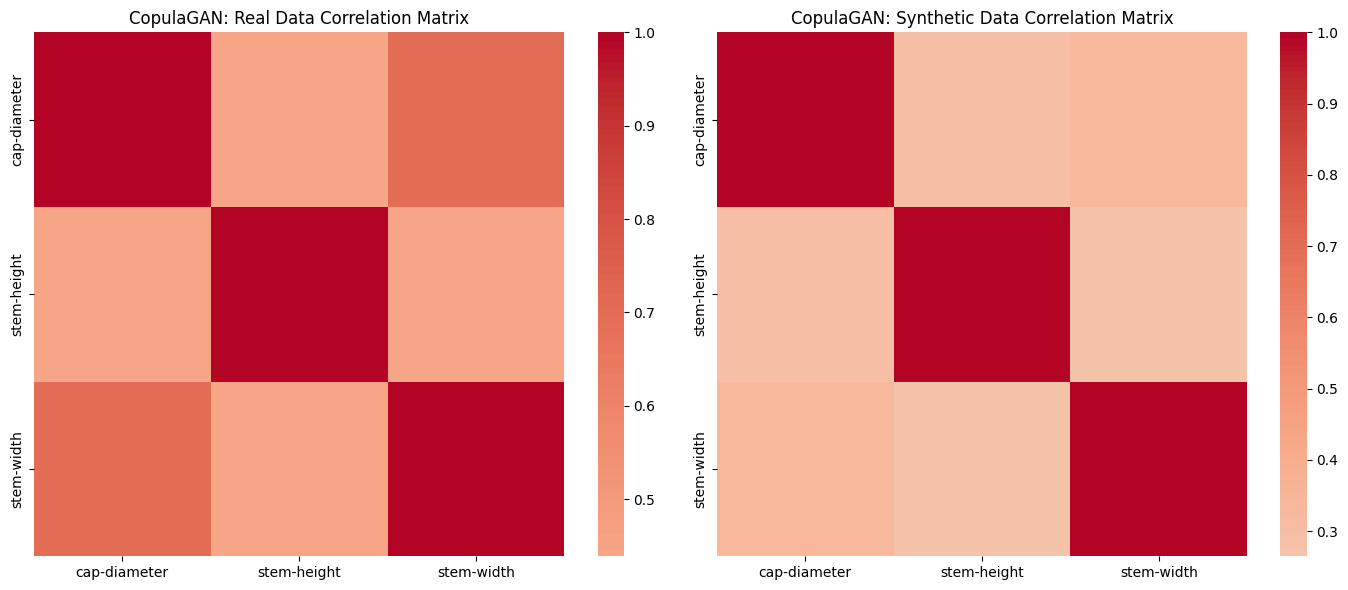

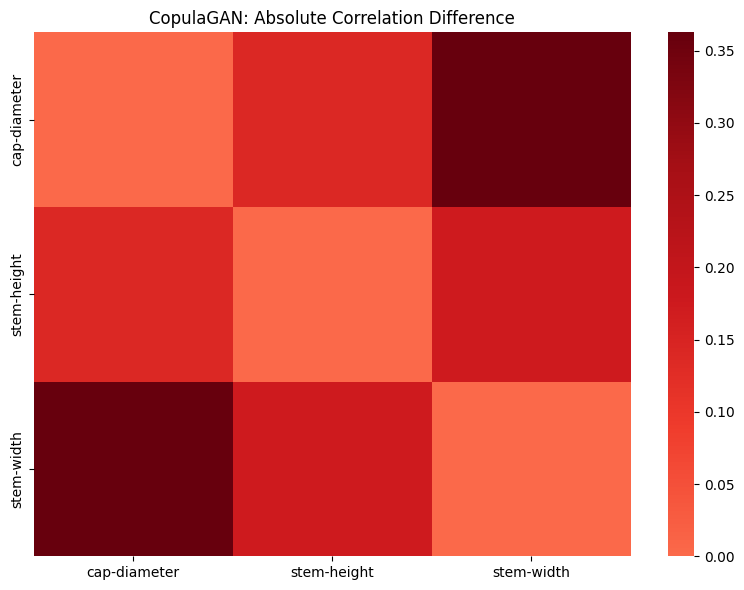

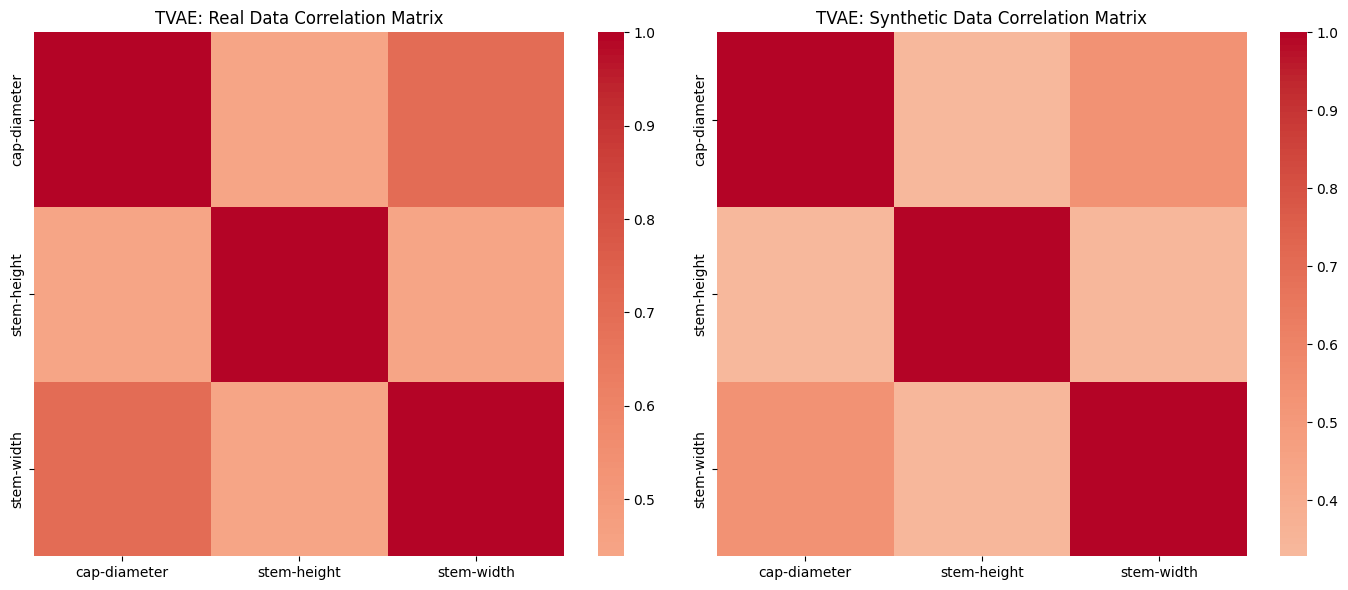

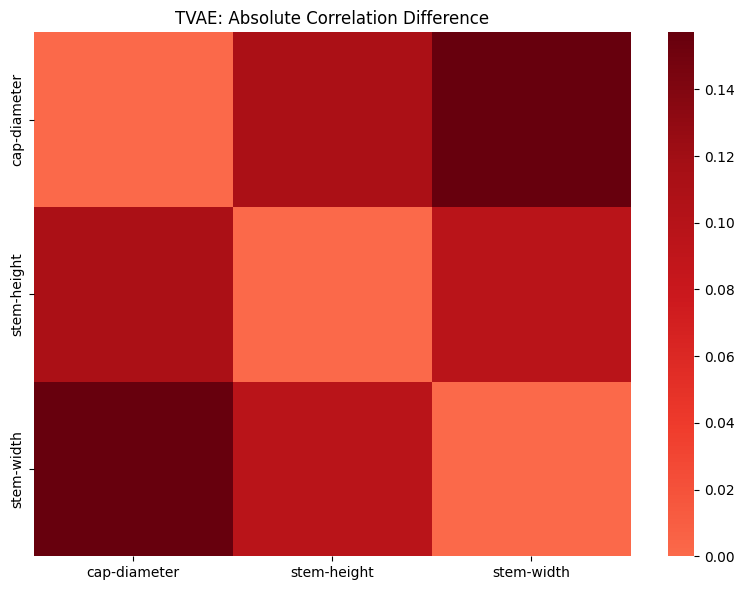

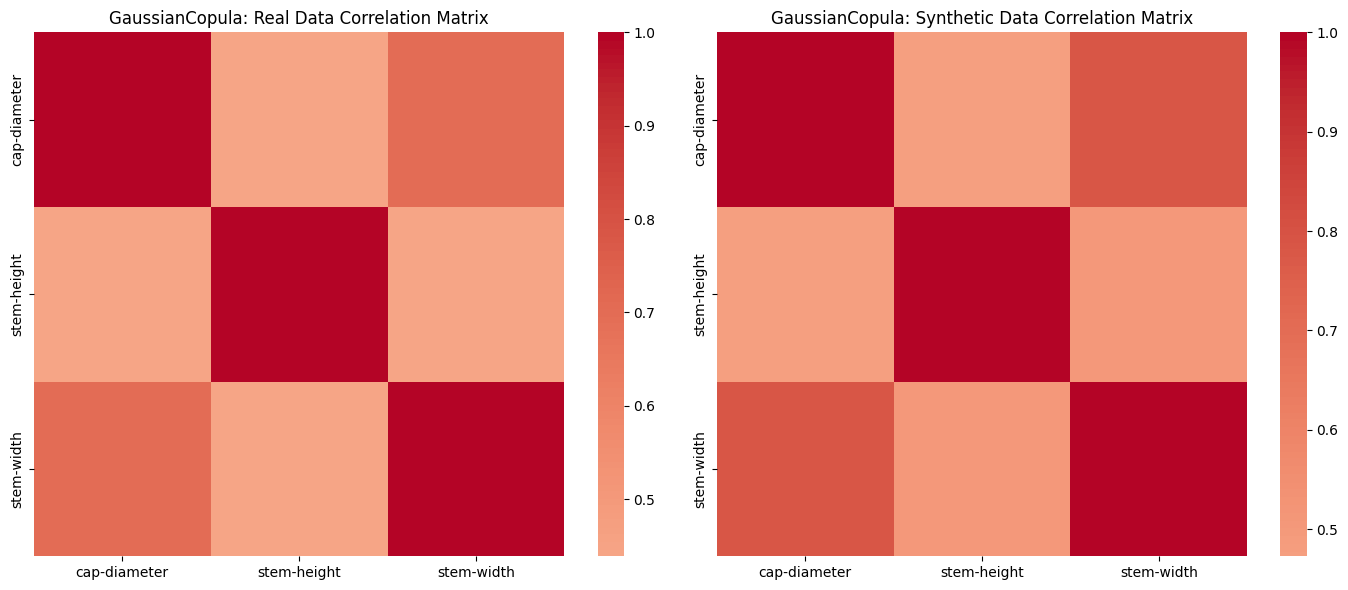

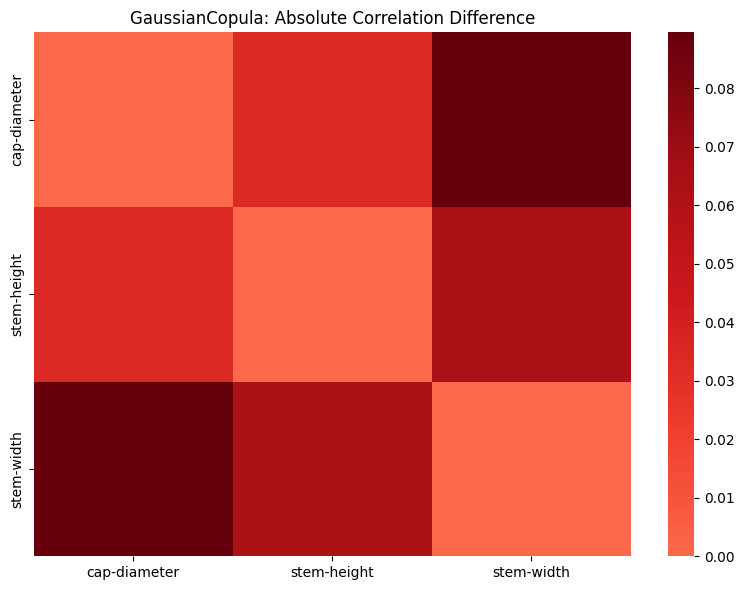

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
target_col = "class"

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.reindex(columns=real_df.columns)
    synth_corr = synth_df[num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference")
    plt.tight_layout()
    plt.show()


CTGAN - Global MMD (RBF): 0.004699


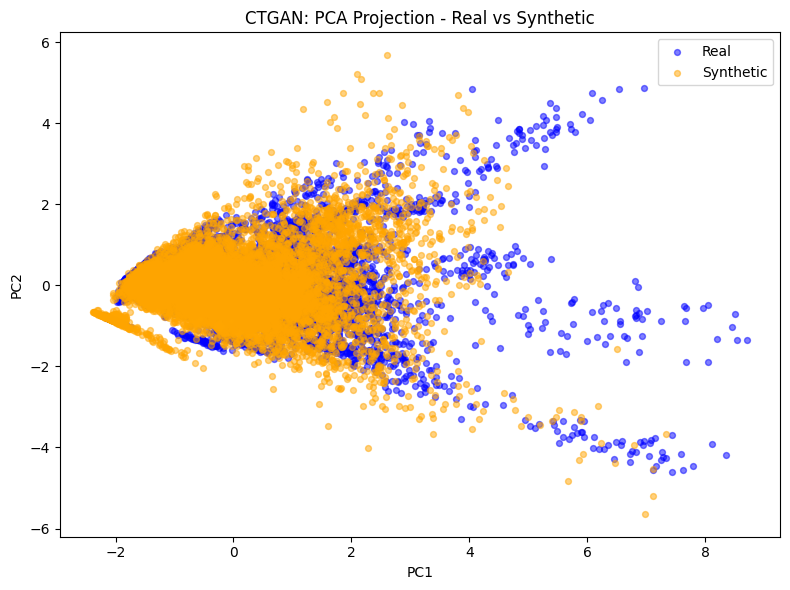

CTGAN - Two-Sample Classifier Accuracy: 0.7387

CopulaGAN - Global MMD (RBF): 0.006553


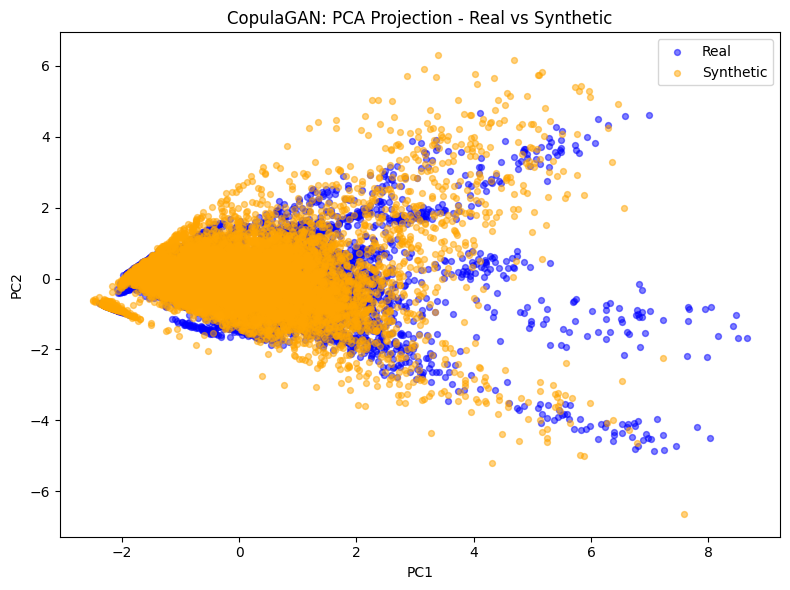

CopulaGAN - Two-Sample Classifier Accuracy: 0.7312

TVAE - Global MMD (RBF): 0.024753


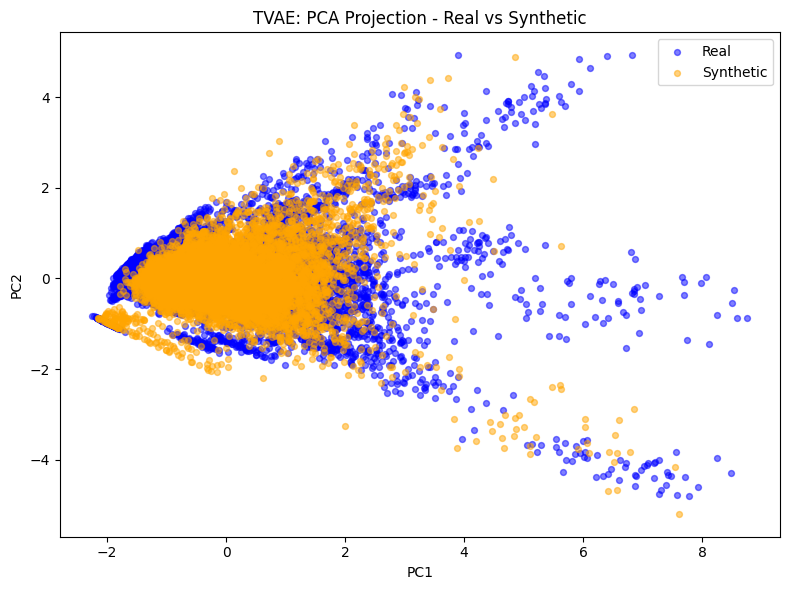

TVAE - Two-Sample Classifier Accuracy: 0.6847

GaussianCopula - Global MMD (RBF): 0.002145


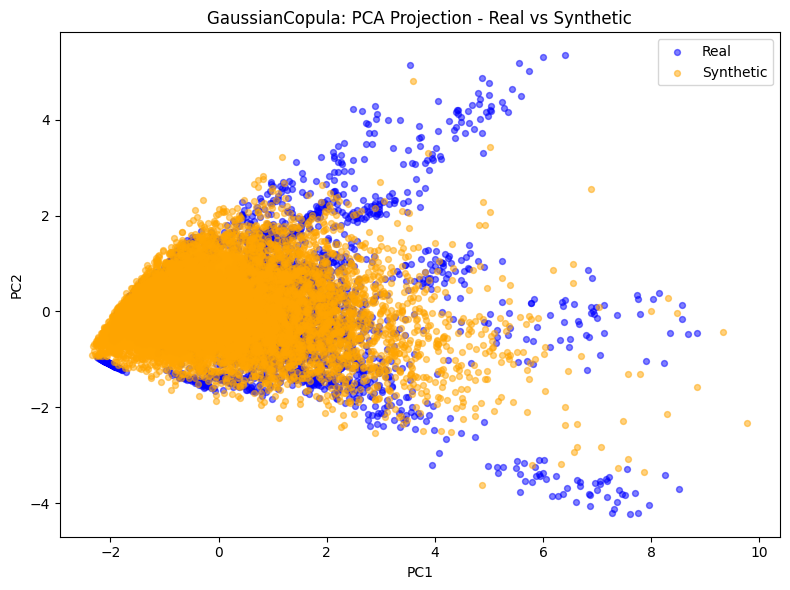

GaussianCopula - Two-Sample Classifier Accuracy: 0.7047

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,GaussianCopula,0.002145,0.704667
1,CTGAN,0.004699,0.738667
2,CopulaGAN,0.006553,0.731167
3,TVAE,0.024753,0.684667


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def mmd_rbf(X, Y, gamma=None, gamma_sample_size=1500):
    if gamma is None:
        Z = np.vstack([X, Y])
        n = len(Z)
        k = min(gamma_sample_size, n)
        idx = np.random.default_rng(42).choice(n, size=k, replace=False)
        Zs = Z[idx]
        d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
        vals = d2[np.triu_indices_from(d2, k=1)]
        med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
        gamma = 1.0 / (2.0 * med)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)

    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "class"

drop_cols = [target_col]

X_real_df = data.drop(columns=drop_cols, errors="ignore").copy()
X_real_df = X_real_df.select_dtypes(include=[np.number]).copy()

results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()
    X_synth_df = X_synth_df.select_dtypes(include=[np.number]).copy()

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].to_numpy(dtype=np.float64)
    X_synth = X_synth_df[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_pca[labels == "Real", 0],
        X_pca[labels == "Real", 1],
        color="blue",
        alpha=0.5,
        label="Real",
        s=18
    )
    plt.scatter(
        X_pca[labels == "Synthetic", 0],
        X_pca[labels == "Synthetic", 1],
        color="orange",
        alpha=0.5,
        label="Synthetic",
        s=18
    )
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": float(mmd_value),
        "C2ST_Accuracy": float(acc)
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)

# 4 Utility with 10 classifiers 

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


models = { 

    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

def evaluate_models_classification(train_df, test_df, label_col, models, test_size=0.2, seed=42):
    X_train = train_df.drop(columns=[label_col]).copy()
    y_train = train_df[label_col].copy()

    X_test = test_df.drop(columns=[label_col]).copy()
    y_test = test_df[label_col].copy()

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )
    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    X_train_num = X_train[num_cols].astype(np.float64)
    X_test_num = X_test[num_cols].astype(np.float64)

    scaler = StandardScaler().fit(X_train_num)
    X_train_s = scaler.transform(X_train_num)
    X_test_s = scaler.transform(X_test_num)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

        rows.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

    return pd.DataFrame(rows).sort_values(by="F1", ascending=False).reset_index(drop=True)



CTGAN - TSTR


,Model,Accuracy,Precision,Recall,F1
0,AdaBoost,0.6330,0.631472,0.6330,0.631957
1,GradientBoost,0.5950,0.589408,0.5950,0.587197
2,ExtraTrees,0.5810,0.575454,0.5810,0.575026
3,MLP,0.5845,0.577704,0.5845,0.574346
4,RandomForest,0.5770,0.570943,0.5770,0.570254
5,KNN,0.5700,0.564816,0.5700,0.565216
6,SVM-RBF,0.5800,0.571828,0.5800,0.563993
7,DecisionTree,0.5515,0.549961,0.5515,0.550599
8,NaiveBayes,0.5685,0.557370,0.5685,0.541881
9,LogReg,0.5665,0.554277,0.5665,0.530470


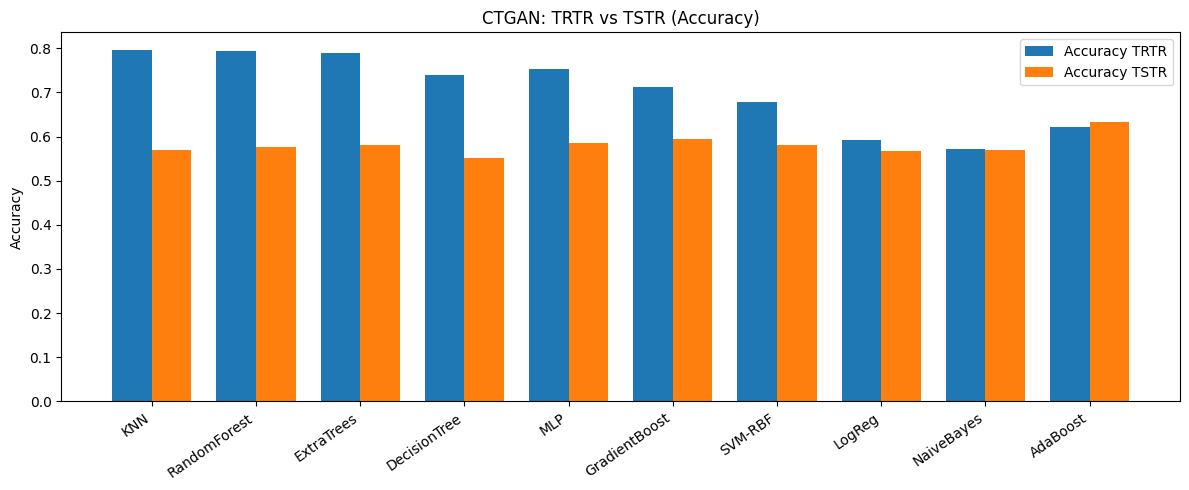

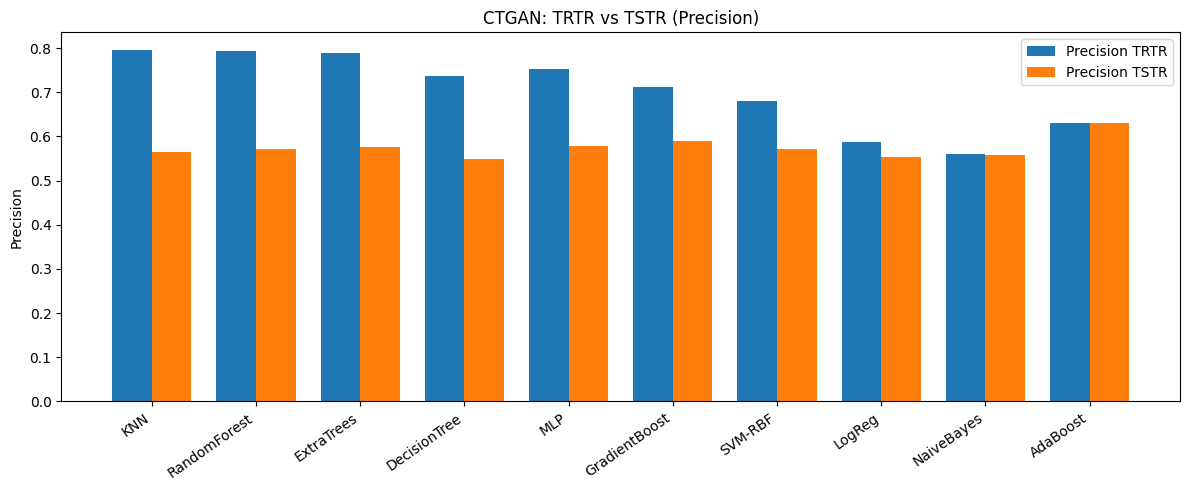

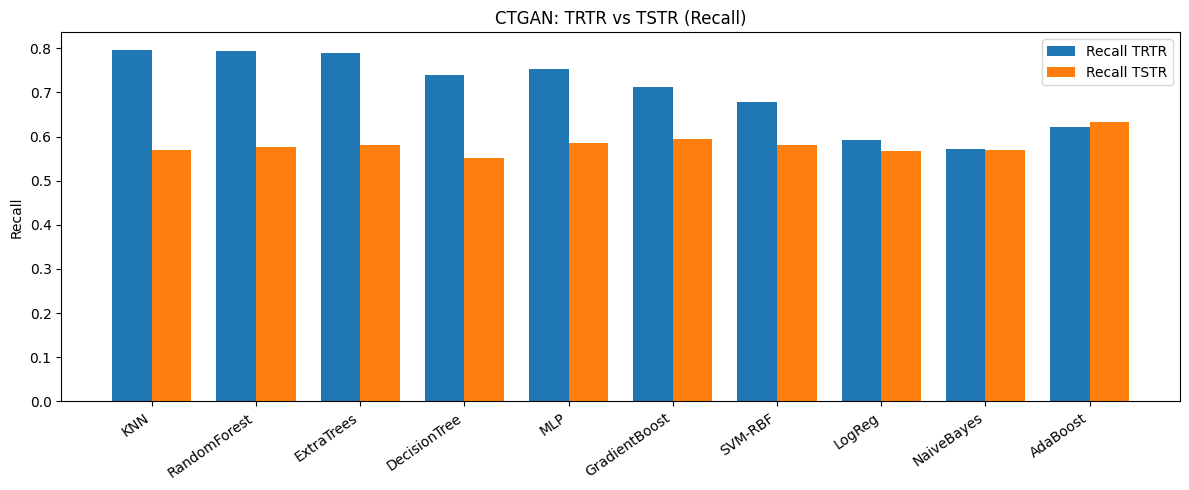

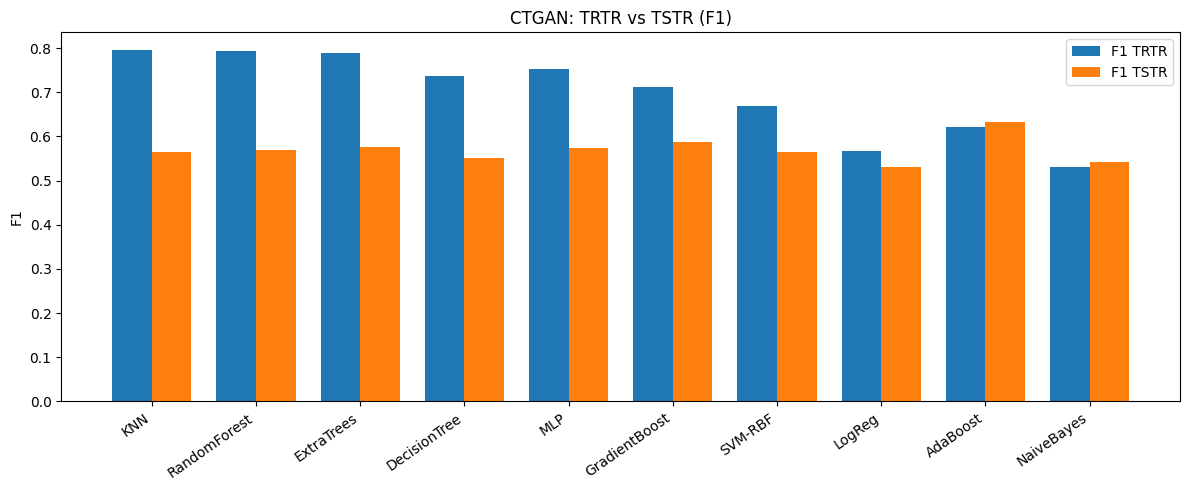

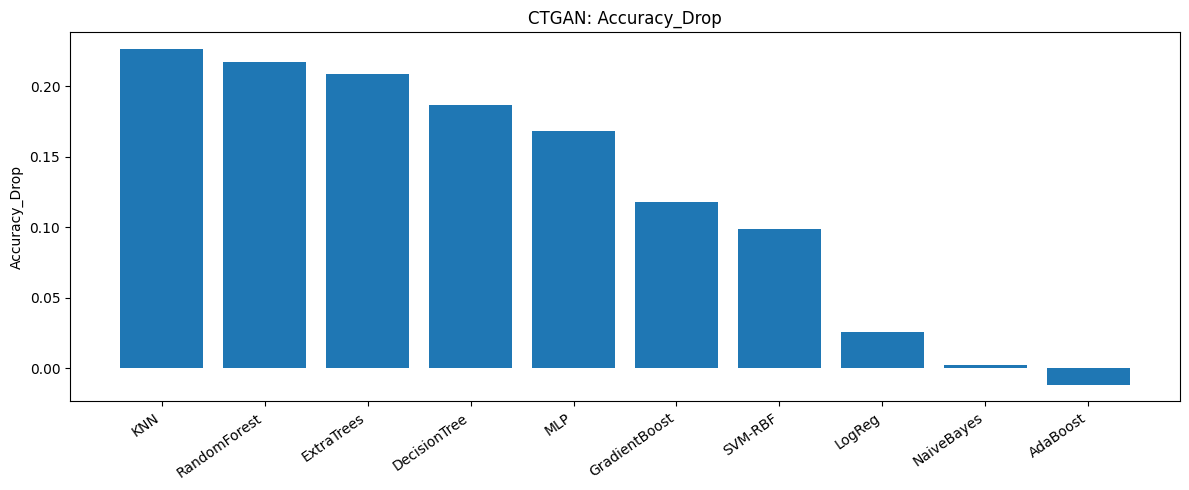

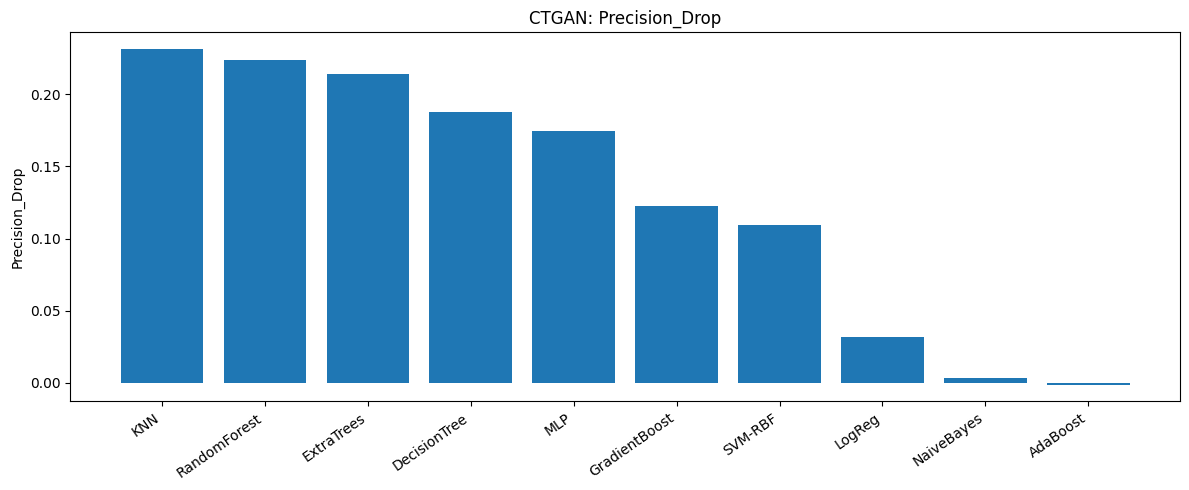

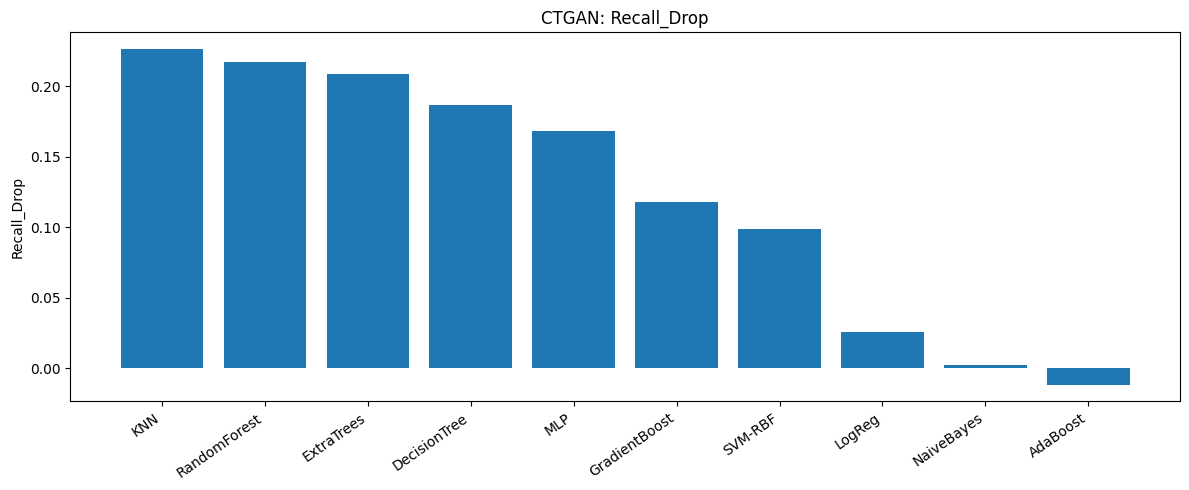

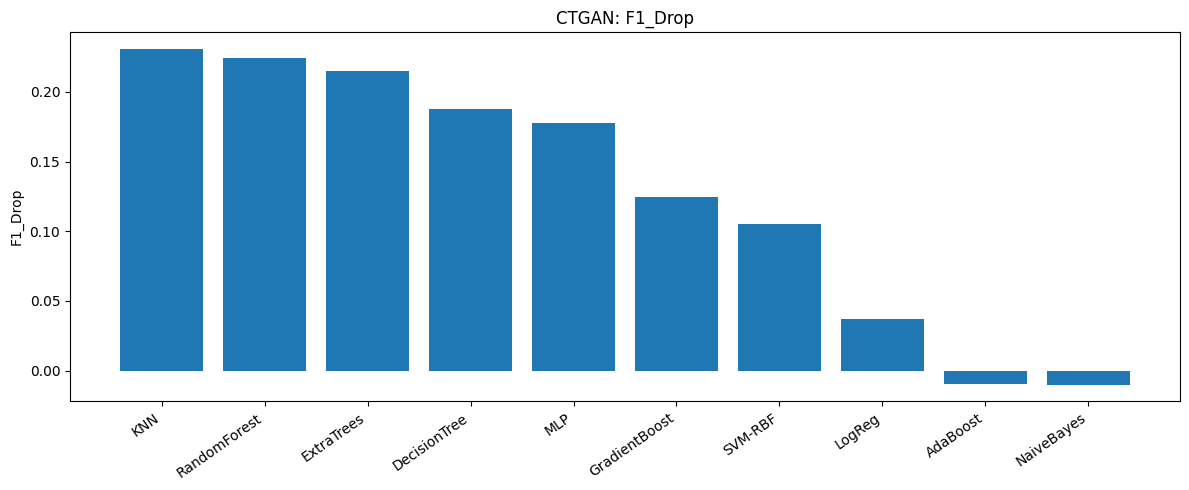


CopulaGAN - TSTR


,Model,Accuracy,Precision,Recall,F1
0,AdaBoost,0.6185,0.625121,0.6185,0.619697
1,SVM-RBF,0.6130,0.608462,0.6130,0.605544
2,MLP,0.6060,0.602755,0.6060,0.603146
3,GradientBoost,0.6045,0.599563,0.6045,0.597431
4,RandomForest,0.5975,0.591781,0.5975,0.588224
5,KNN,0.5840,0.577986,0.5840,0.576627
6,ExtraTrees,0.5805,0.573636,0.5805,0.571117
7,LogReg,0.5880,0.582559,0.5880,0.557184
8,NaiveBayes,0.5845,0.578005,0.5845,0.553288
9,DecisionTree,0.5400,0.534548,0.5400,0.535654


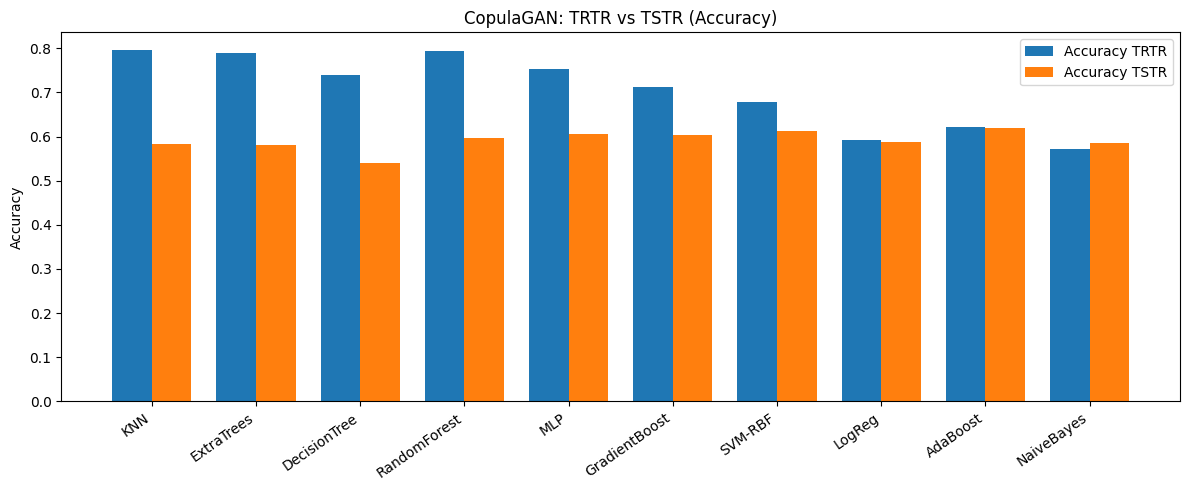

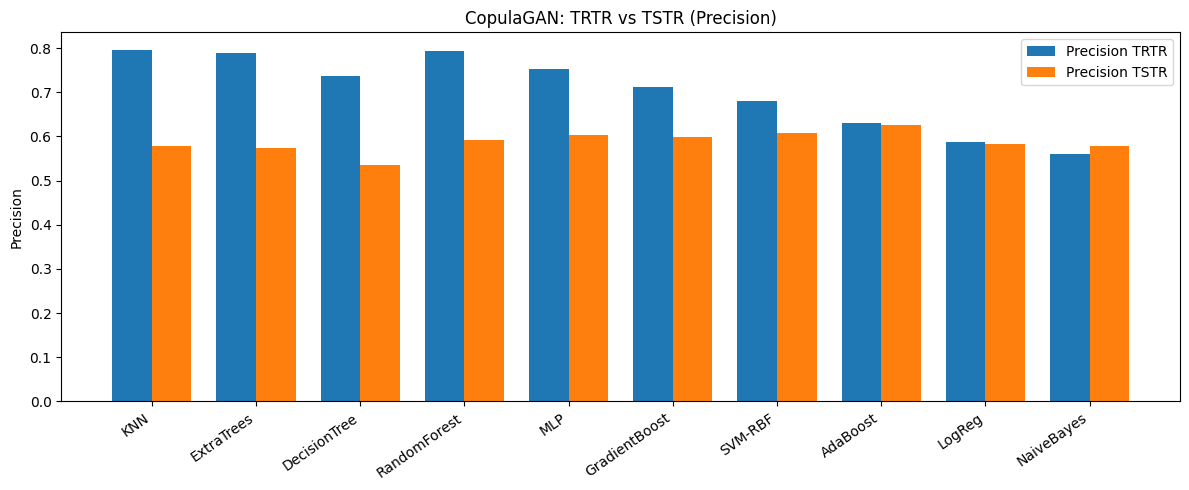

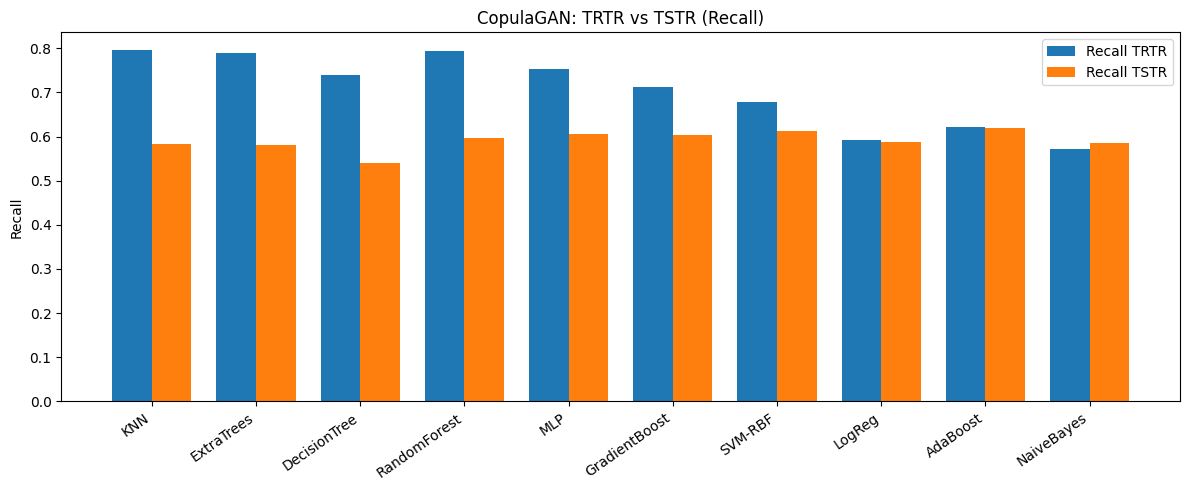

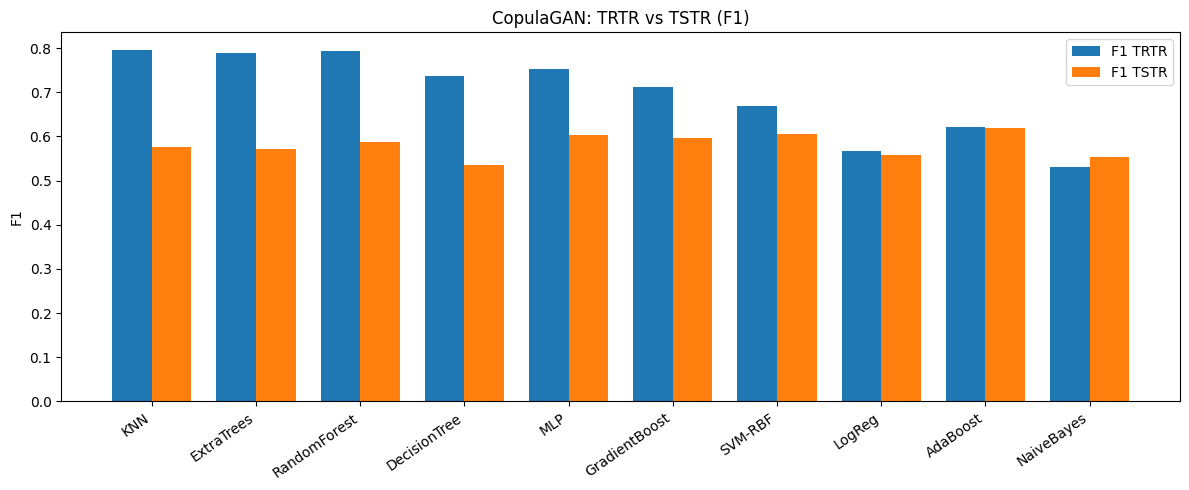

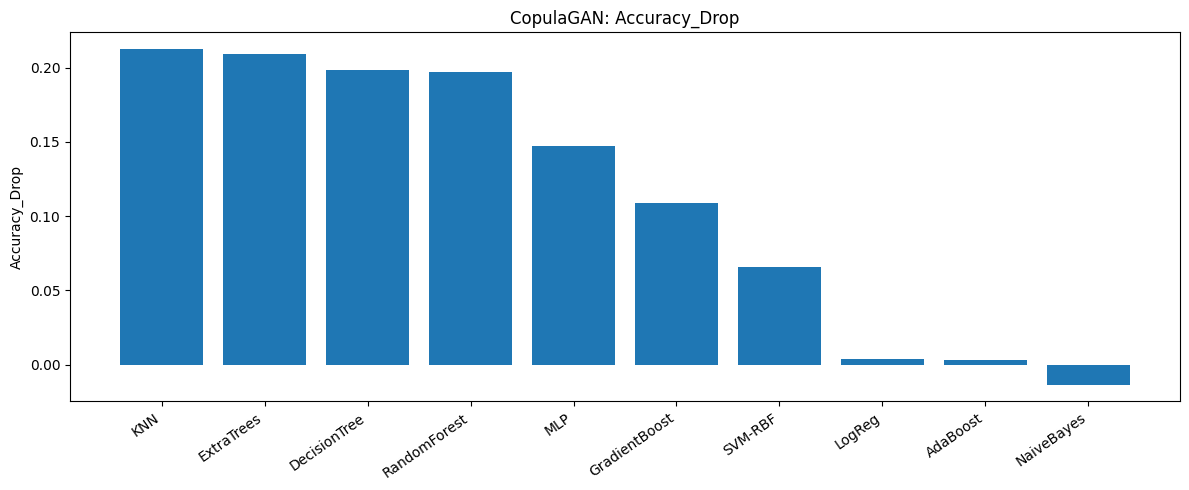

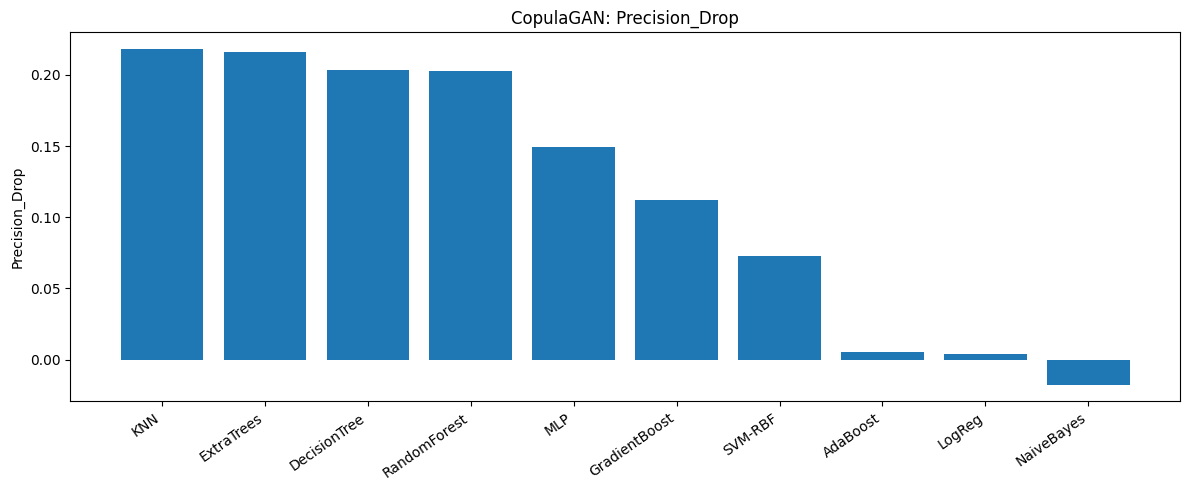

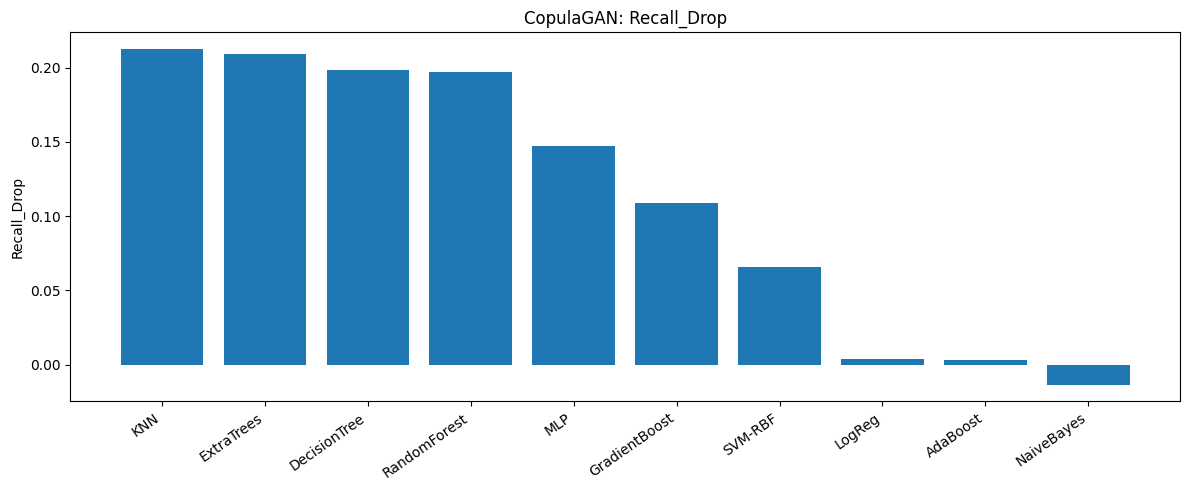

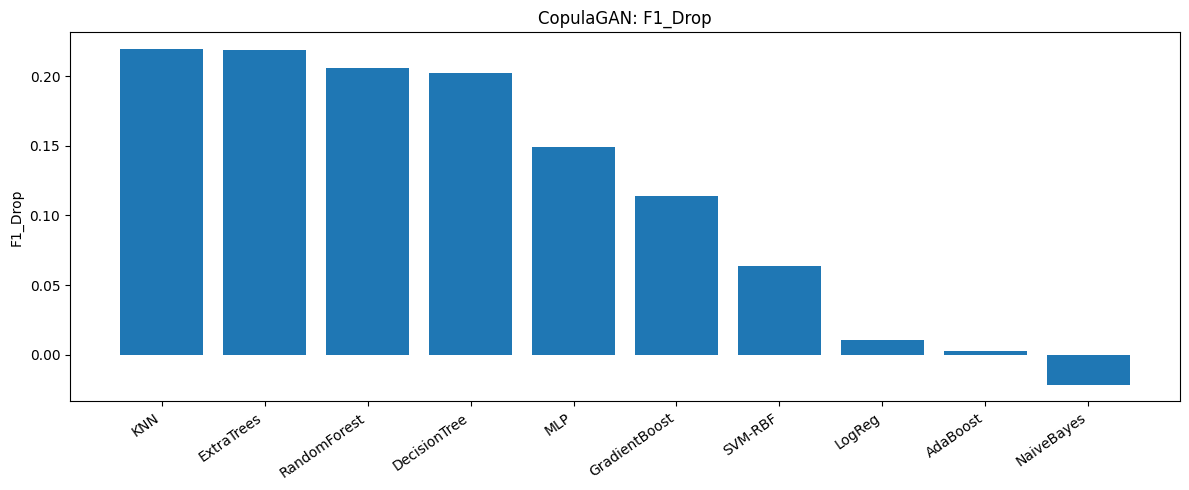


TVAE - TSTR


,Model,Accuracy,Precision,Recall,F1
0,ExtraTrees,0.6540,0.651706,0.6540,0.647868
1,RandomForest,0.6520,0.650100,0.6520,0.644275
2,MLP,0.6510,0.649549,0.6510,0.642036
3,GradientBoost,0.6560,0.658716,0.6560,0.641803
4,SVM-RBF,0.6490,0.654017,0.6490,0.630535
5,KNN,0.6355,0.632378,0.6355,0.627833
6,DecisionTree,0.6155,0.611814,0.6155,0.611458
7,AdaBoost,0.5995,0.594418,0.5995,0.592821
8,LogReg,0.6065,0.602264,0.6065,0.589247
9,NaiveBayes,0.5980,0.593133,0.5980,0.576427


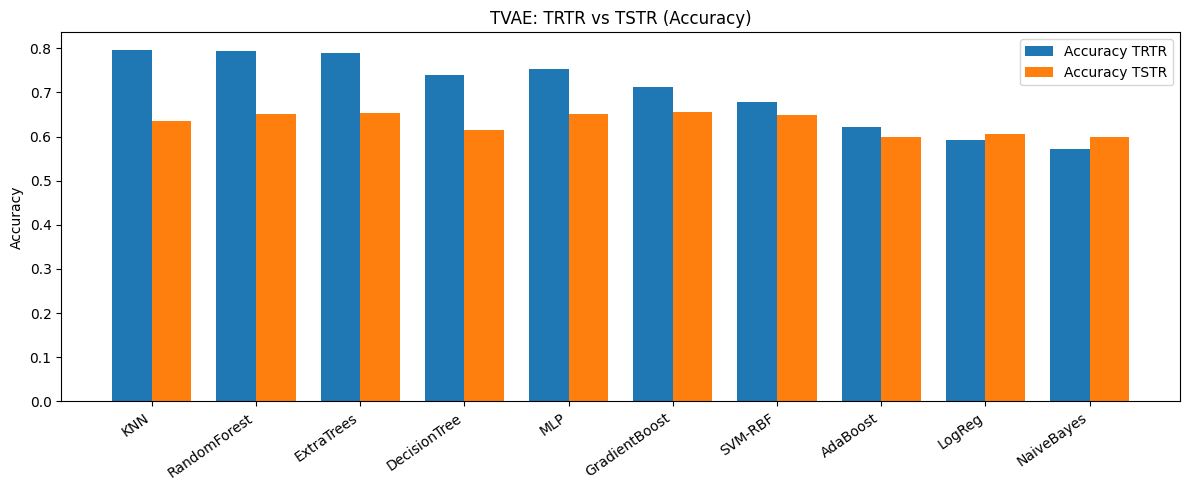

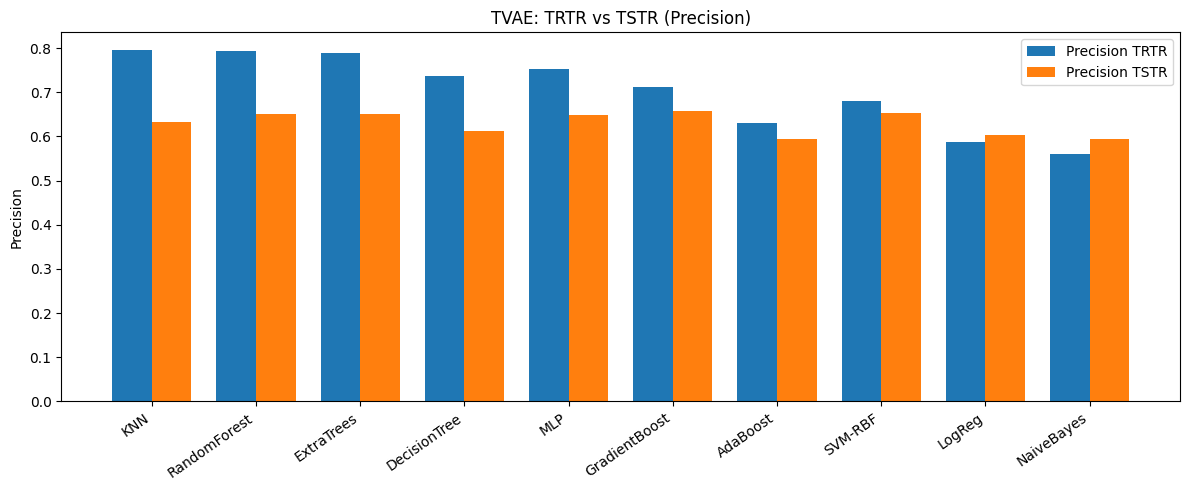

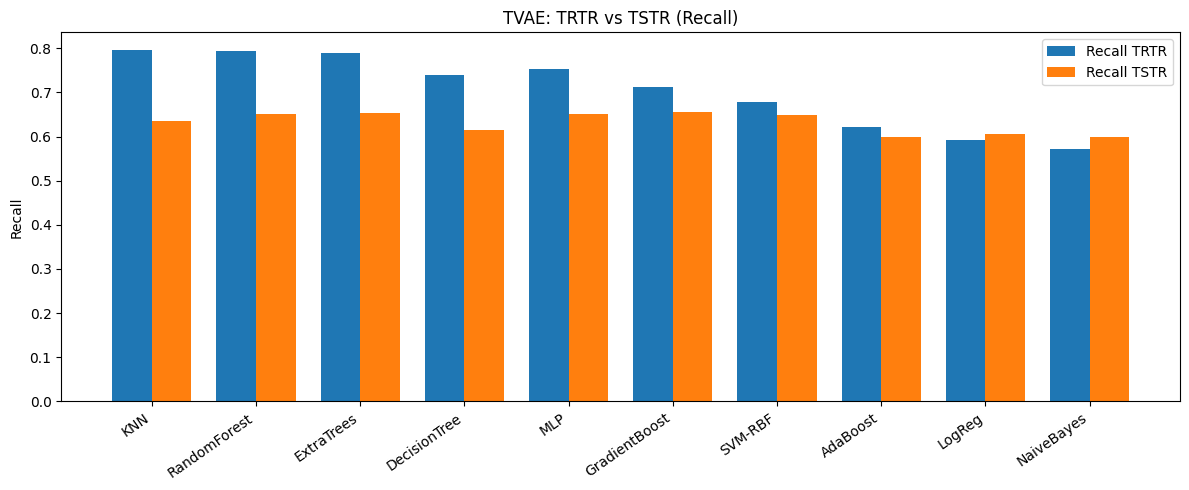

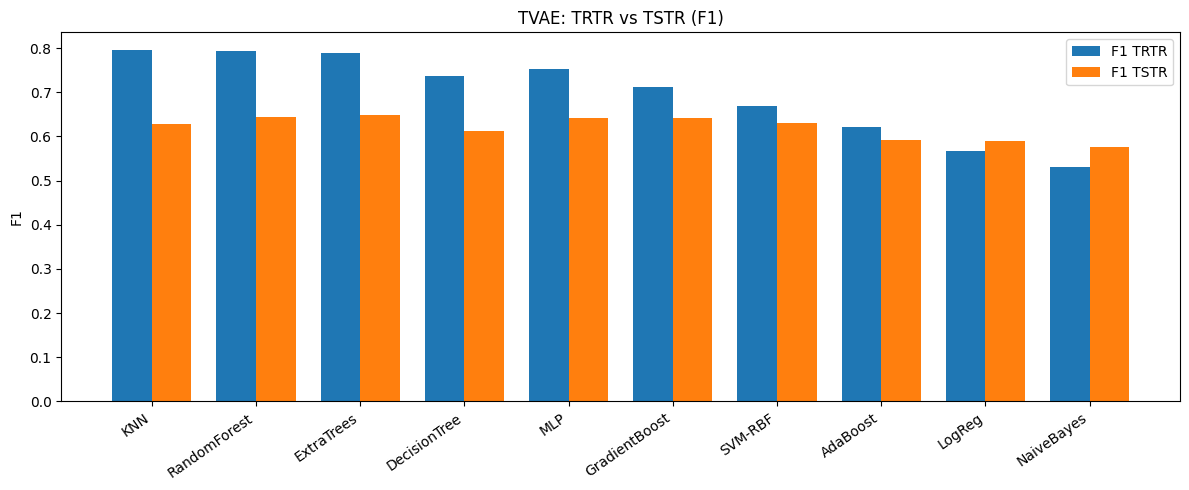

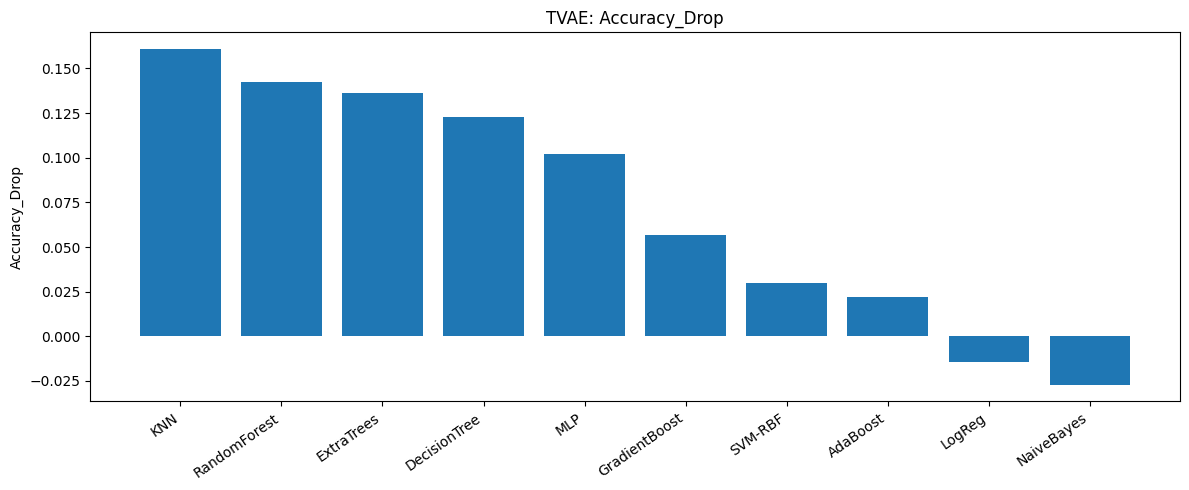

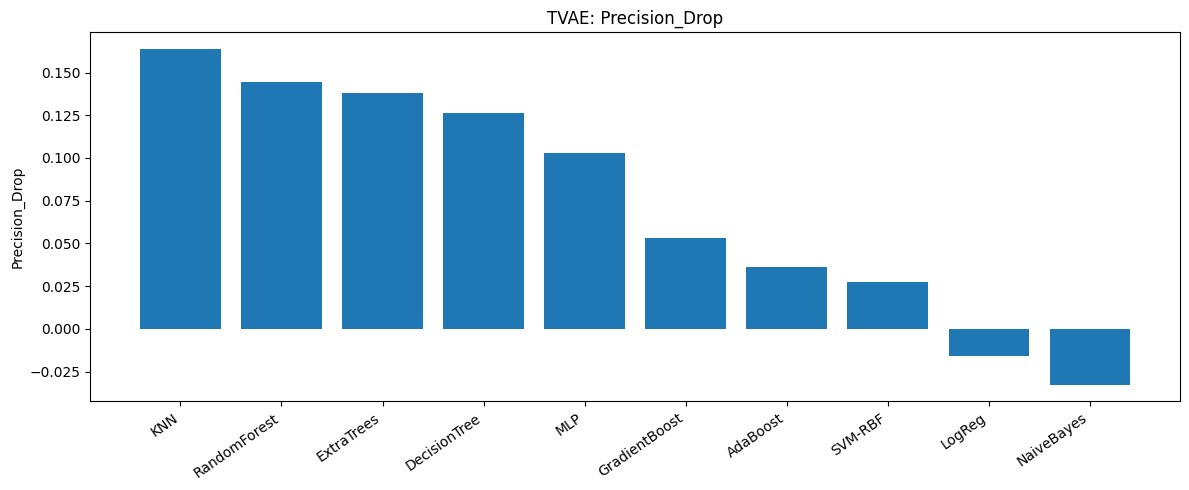

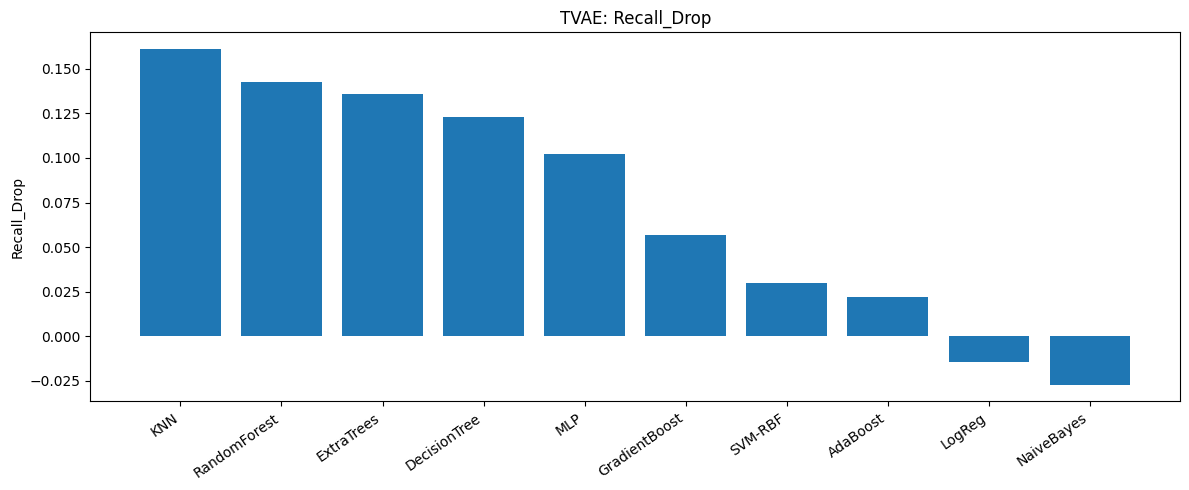

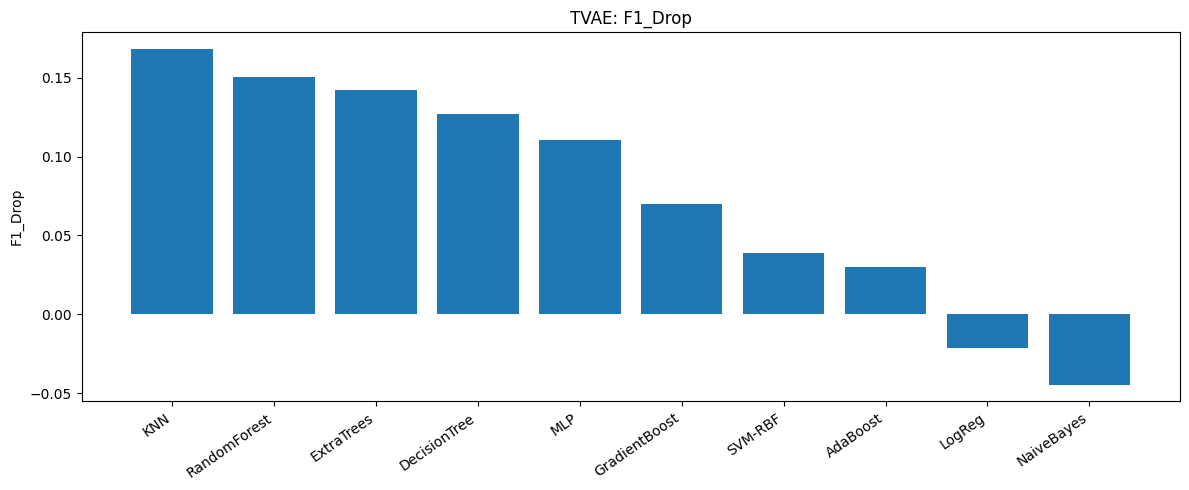


GaussianCopula - TSTR


,Model,Accuracy,Precision,Recall,F1
0,AdaBoost,0.6005,0.595667,0.6005,0.594527
1,MLP,0.5965,0.590884,0.5965,0.577437
2,ExtraTrees,0.5680,0.560179,0.5680,0.558118
3,KNN,0.5605,0.555139,0.5605,0.555773
4,RandomForest,0.5580,0.550678,0.5580,0.550300
5,SVM-RBF,0.5840,0.580022,0.5840,0.541655
6,GradientBoost,0.5740,0.564356,0.5740,0.539895
7,NaiveBayes,0.5735,0.563695,0.5735,0.539212
8,LogReg,0.5695,0.558957,0.5695,0.522063
9,DecisionTree,0.5050,0.503421,0.5050,0.504113


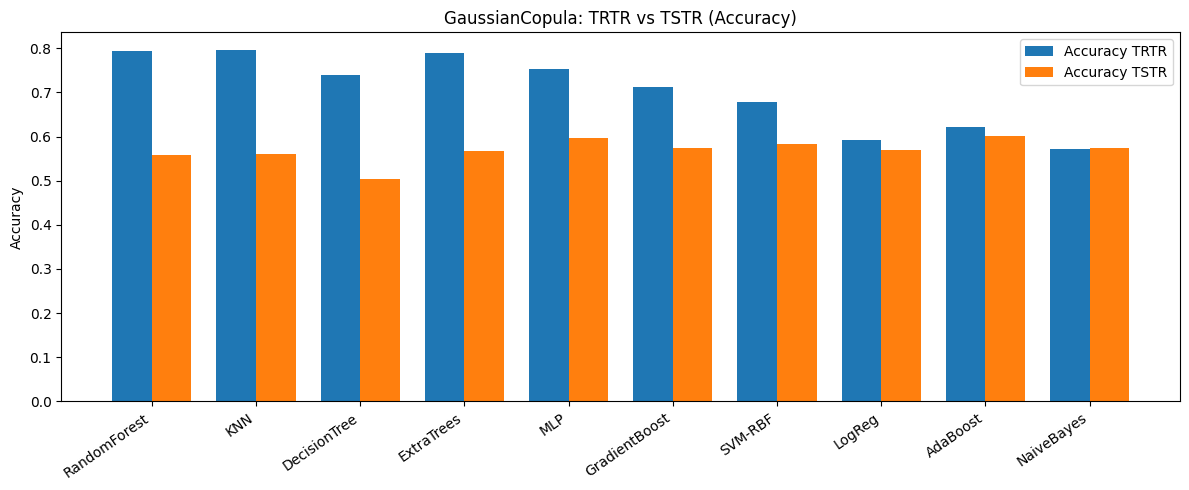

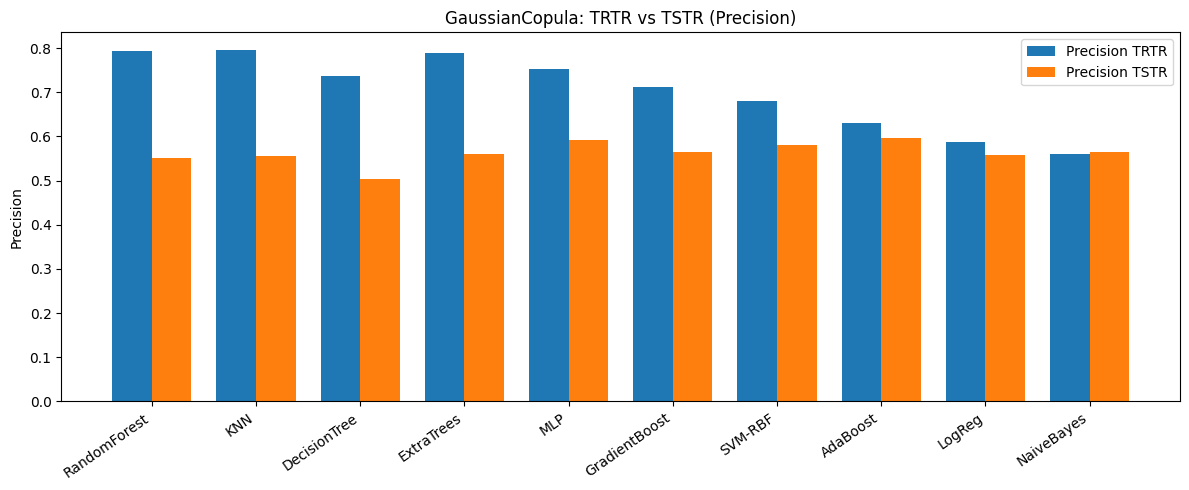

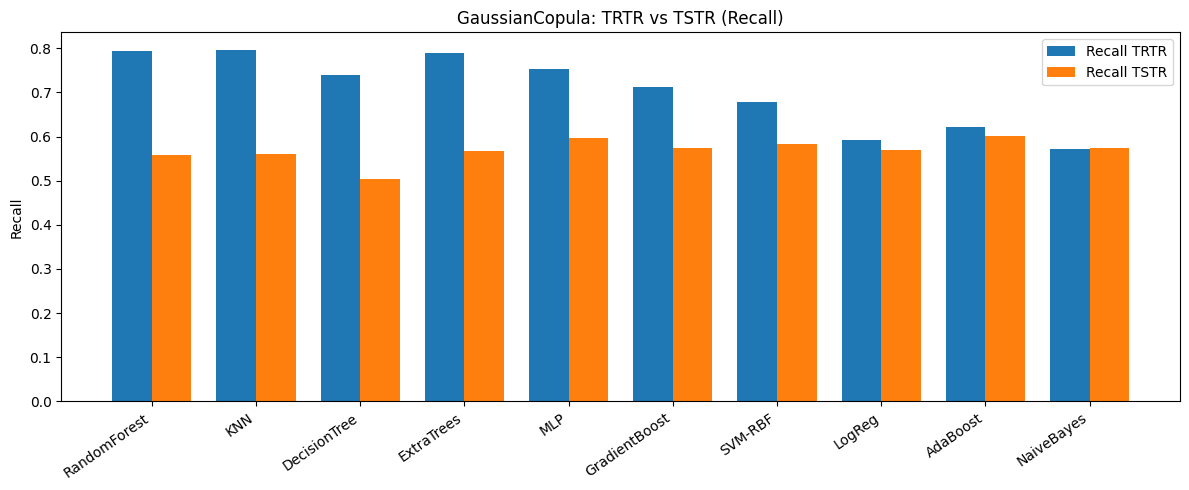

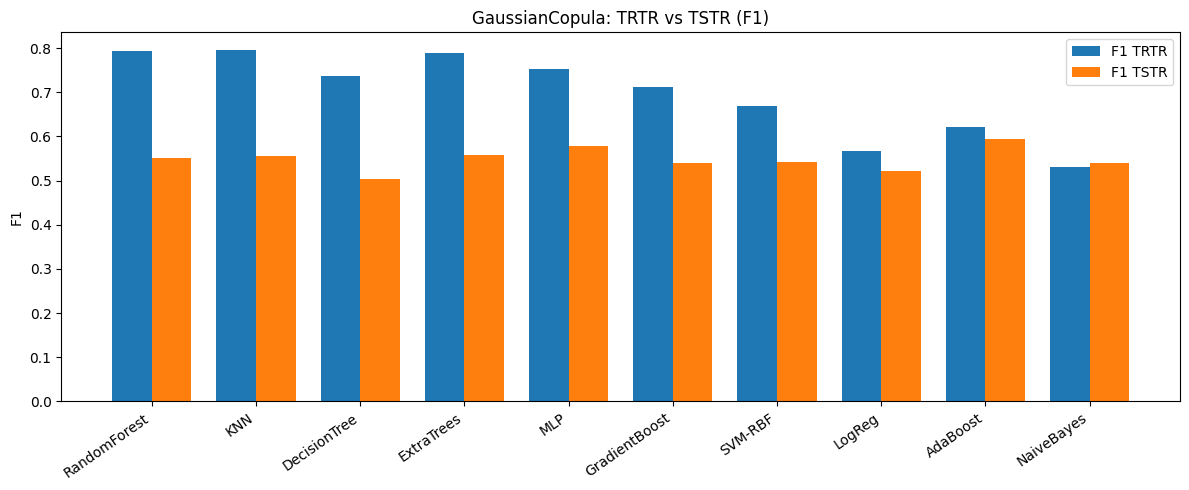

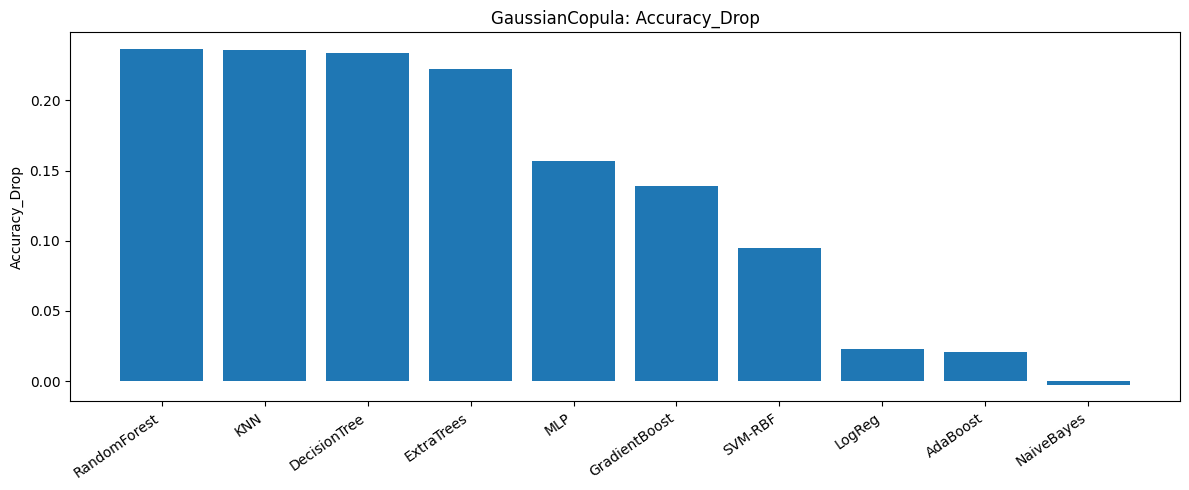

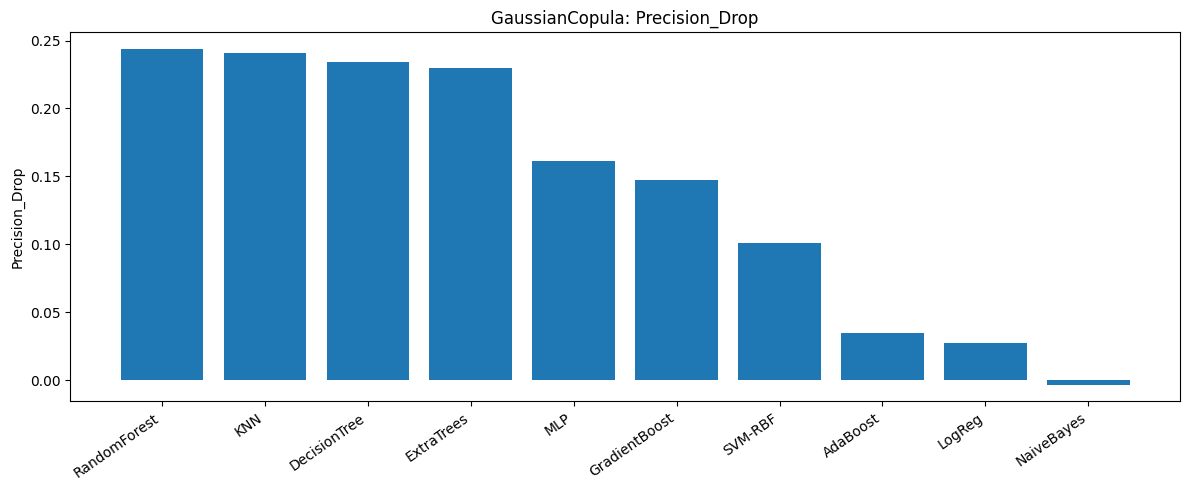

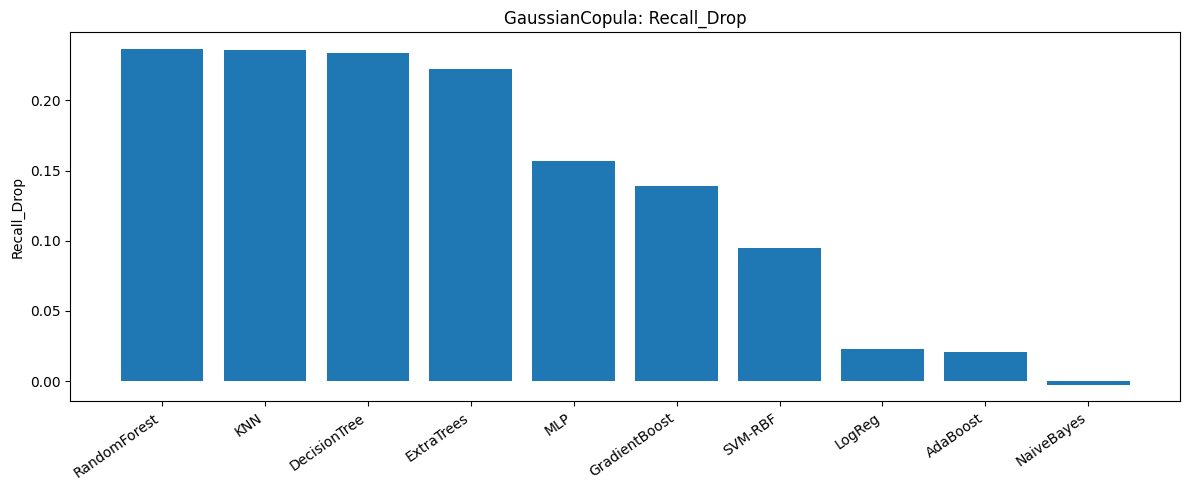

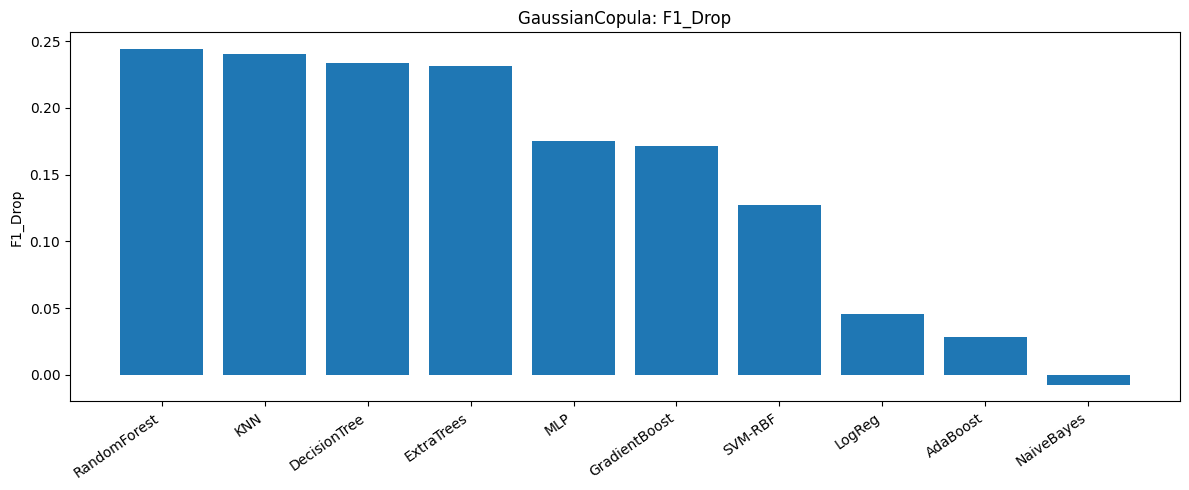


Average metric gap by synthetic generator:


,Synthetic_Model,Accuracy_Drop,Precision_Drop,Recall_Drop,F1_Drop
3,TVAE,0.07320,0.074256,0.07320,0.076926
1,CopulaGAN,0.11325,0.116624,0.11325,0.116565
0,CTGAN,0.12420,0.129742,0.12420,0.128262
2,GaussianCopula,0.13595,0.141766,0.13595,0.149047


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="F1"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    # Higher is better for classification metrics, so drop from TRTR to TSTR is worse
    df["Diff"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Diff", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w / 2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_diff(comparison_df, synth_name, metric="F1_Drop"):
    if metric not in comparison_df.columns:
        return

    df = comparison_df.sort_values(metric, ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df[metric])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: {metric}")
    plt.tight_layout()
    plt.show()

label_col = "class"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# uses evaluate_models_classification(...)
trtr_results = evaluate_models_classification(
    train_df=data,
    test_df=data,
    label="class",
    models=models
)

all_comp = []

for synth_name in model_order:
    synth_train = synthetic_datasets[synth_name].reindex(columns=data.columns).copy()

    tstr_results = evaluate_models_classification(
        train_df=synth_train,
        test_df=data,
        label="class",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]
    comparison["Precision_Drop"] = comparison["Precision_TRTR"] - comparison["Precision_TSTR"]
    comparison["Recall_Drop"] = comparison["Recall_TRTR"] - comparison["Recall_TSTR"]
    comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["Accuracy", "Precision", "Recall", "F1"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    for diff_metric in ["Accuracy_Drop", "Precision_Drop", "Recall_Drop", "F1_Drop"]:
        plot_metric_diff(comparison, synth_name, metric=diff_metric)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_gap = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)[["Accuracy_Drop", "Precision_Drop", "Recall_Drop", "F1_Drop"]]
    .mean()
    .sort_values("F1_Drop")
)

print("\nAverage metric gap by synthetic generator:")
display(summary_gap)


In [32]:
import time
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

label_col = "class"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# ---------- SPEED KNOBS ----------
MAX_ROWS_REAL = 1200
MAX_ROWS_SYNTH = 1200
TEST_SIZE = 0.2
SEED = 47
# --------------------------------

def speed_tune_estimator(est):
    e = clone(est)
    params = e.get_params()

    updates = {}
    if "n_jobs" in params:
        updates["n_jobs"] = -1
    if "n_estimators" in params:
        updates["n_estimators"] = min(params.get("n_estimators", 200), 120)
    if "max_iter" in params:
        updates["max_iter"] = min(params.get("max_iter", 1000), 400)
    if "random_state" in params and params["random_state"] is None:
        updates["random_state"] = SEED

    if updates:
        e.set_params(**updates)
    return e

def pick_10_models(models_dict):
    keys = list(models_dict.keys())
    if len(keys) < 10:
        raise ValueError(f"`models` has only {len(keys)} models; need at least 10.")
    chosen = keys[:10]
    return {k: speed_tune_estimator(models_dict[k]) for k in chosen}

def run_clf_models(X_train, y_train, X_test, y_test, models_dict):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, clf in models_dict.items():
        t0 = time.time()
        m = clone(clf)
        m.fit(X_train_s, y_train)
        y_pred = m.predict(X_test_s)

        rows.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "F1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
            "FitSec": round(time.time() - t0, 3),
        })
    return pd.DataFrame(rows)

# numeric-only features
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c != label_col]

# sample real once
real_eval = data.sample(n=min(MAX_ROWS_REAL, len(data)), random_state=SEED).copy()
X_real = real_eval[feature_cols].to_numpy(dtype=np.float32)
y_real = real_eval[label_col].to_numpy()

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real, y_real, test_size=TEST_SIZE, random_state=SEED, stratify=y_real
)

models_used = pick_10_models(models)
print(f"Using {len(models_used)} models: {list(models_used.keys())}")

# TRTR baseline
trtr_results = run_clf_models(X_train_real, y_train_real, X_test_real, y_test_real, models_used)

all_comparisons = []

for synth_name in model_order:
    synth_df = synthetic_datasets[synth_name].reindex(columns=data.columns).copy()
    synth_eval = synth_df.sample(n=min(MAX_ROWS_SYNTH, len(synth_df)), random_state=SEED)

    X_synth = synth_eval[feature_cols].to_numpy(dtype=np.float32)
    y_synth = synth_eval[label_col].to_numpy()

    # train on synthetic, test on same real test split
    tstr_results = run_clf_models(X_synth, y_synth, X_test_real, y_test_real, models_used)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]
    comparison["Precision_Drop"] = comparison["Precision_TRTR"] - comparison["Precision_TSTR"]
    comparison["Recall_Drop"] = comparison["Recall_TRTR"] - comparison["Recall_TSTR"]
    comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    comparison["Synthetic_Model"] = synth_name

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)[["Accuracy_Drop", "Precision_Drop", "Recall_Drop", "F1_Drop"]]
    .mean()
    .sort_values("F1_Drop")
)

print("Average performance gap by synthetic generator (lower is better):")
display(summary)

print("\nPer-model timing (seconds):")
timing_cols = [c for c in combined_comparison.columns if "FitSec" in c]
display(combined_comparison[["Synthetic_Model", "Model"] + timing_cols].sort_values(timing_cols[-1], ascending=False))


Using 10 models: ['LogReg', 'SVM-RBF', 'KNN', 'NaiveBayes', 'DecisionTree', 'RandomForest', 'ExtraTrees', 'GradientBoost', 'AdaBoost', 'MLP']
Average performance gap by synthetic generator (lower is better):


,Synthetic_Model,Accuracy_Drop,Precision_Drop,Recall_Drop,F1_Drop
3,TVAE,0.081667,0.078590,0.081667,0.075955
1,CopulaGAN,0.100000,0.106836,0.100000,0.105122
0,CTGAN,0.129583,0.125835,0.129583,0.124808
2,GaussianCopula,0.142083,0.146007,0.142083,0.144505



Per-model timing (seconds):


,Synthetic_Model,Model,FitSec_TRTR,FitSec_TSTR
29,TVAE,MLP,0.885,0.879
9,CTGAN,MLP,0.885,0.692
19,CopulaGAN,MLP,0.885,0.402
39,GaussianCopula,MLP,0.885,0.386
5,CTGAN,RandomForest,0.196,0.216
15,CopulaGAN,RandomForest,0.196,0.200
35,GaussianCopula,RandomForest,0.196,0.199
25,TVAE,RandomForest,0.196,0.195
37,GaussianCopula,GradientBoost,0.146,0.192
7,CTGAN,GradientBoost,0.146,0.181



CTGAN - TSTR


,Model,Accuracy,Precision,Recall,F1
0,LogReg,0.7090,0.708832,0.7090,0.704764
1,SVM-RBF,0.6988,0.700373,0.6988,0.691924
2,GradientBoost,0.6833,0.683935,0.6833,0.675864
3,ExtraTrees,0.6833,0.684689,0.6833,0.675009
4,NaiveBayes,0.6647,0.683899,0.6647,0.664288
5,RandomForest,0.6715,0.672196,0.6715,0.662513
6,KNN,0.6574,0.655715,0.6574,0.650242
7,MLP,0.6504,0.648233,0.6504,0.643187
8,AdaBoost,0.6479,0.645473,0.6479,0.640986
9,DecisionTree,0.6182,0.615396,0.6182,0.615754


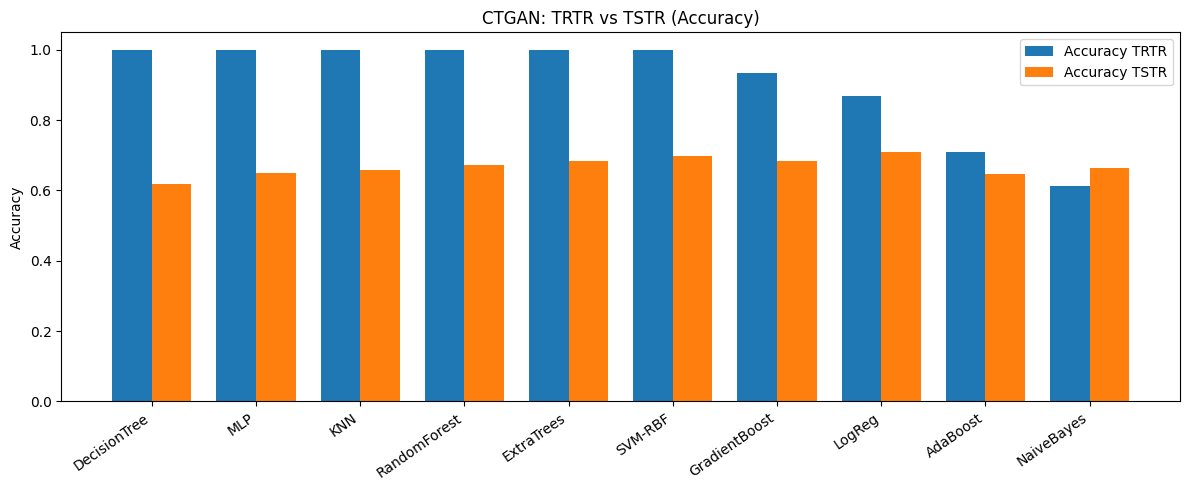

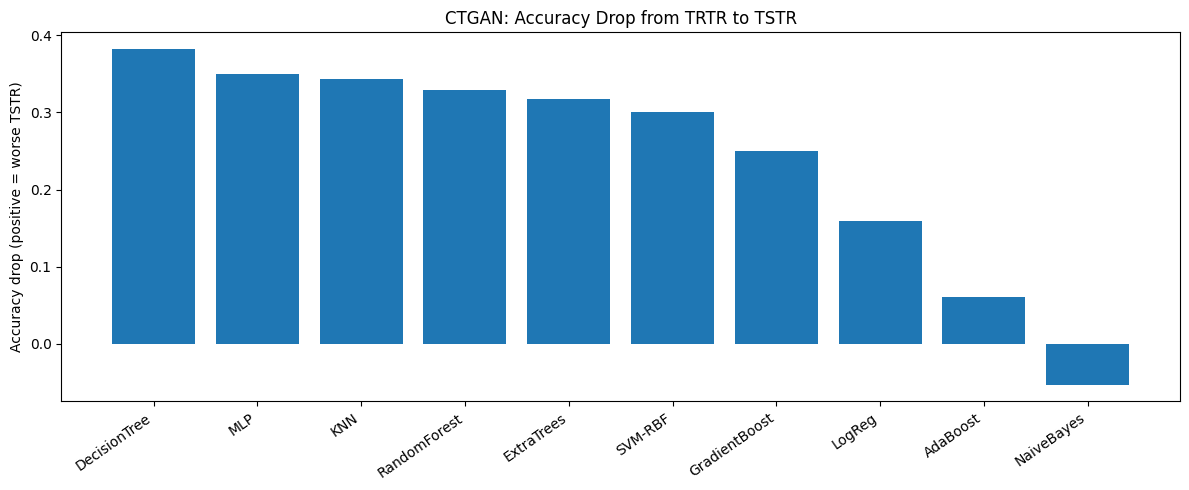

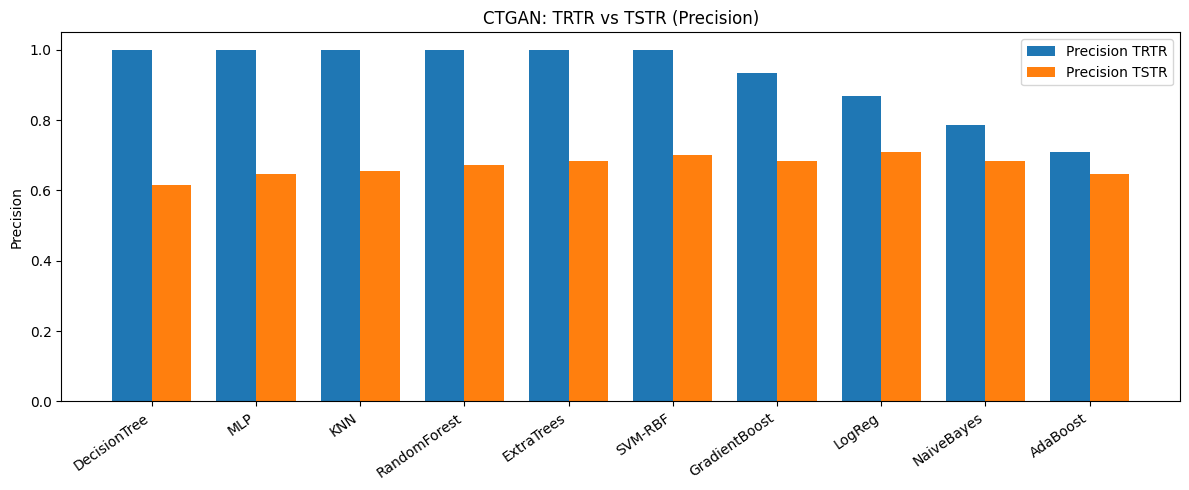

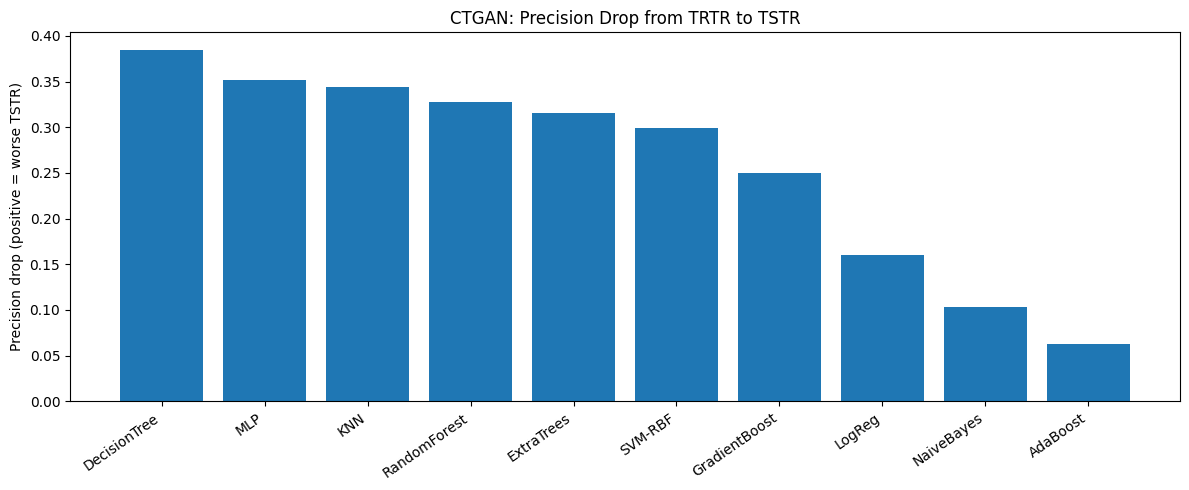

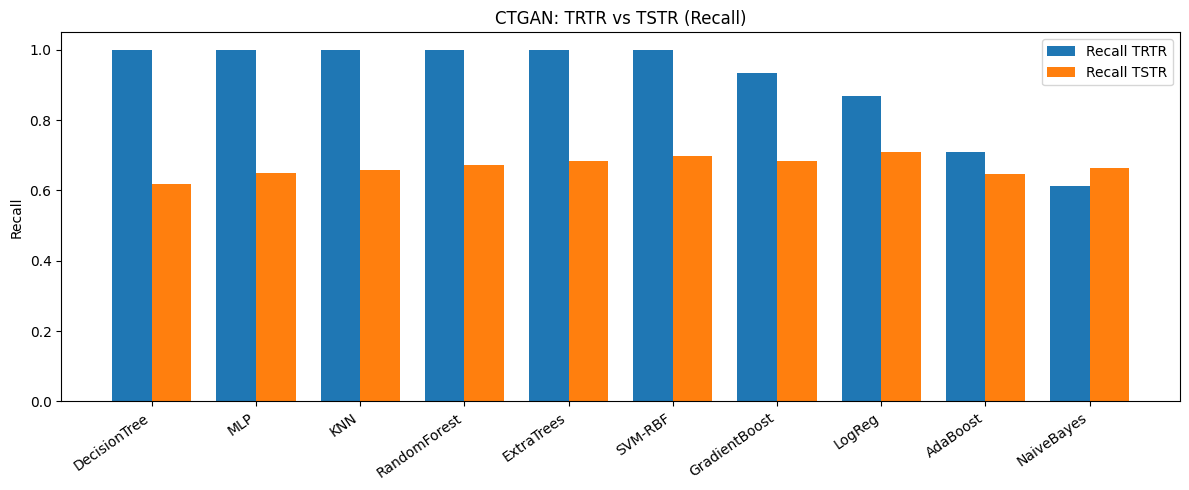

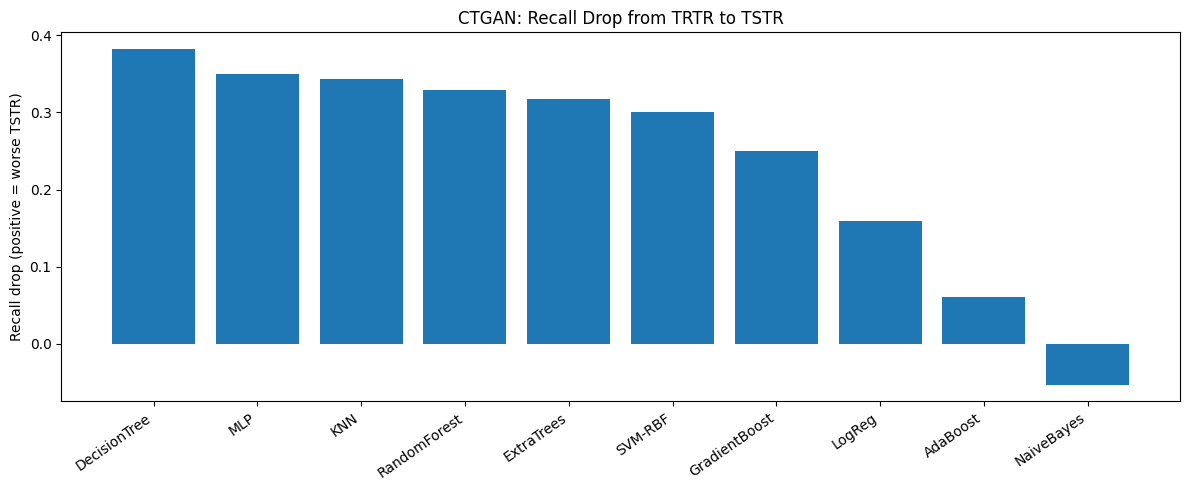

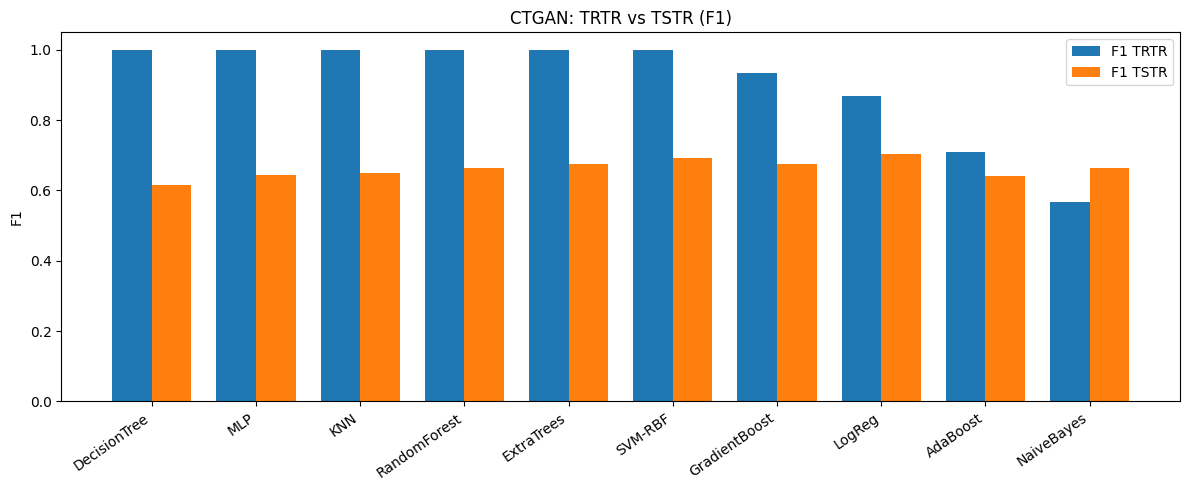

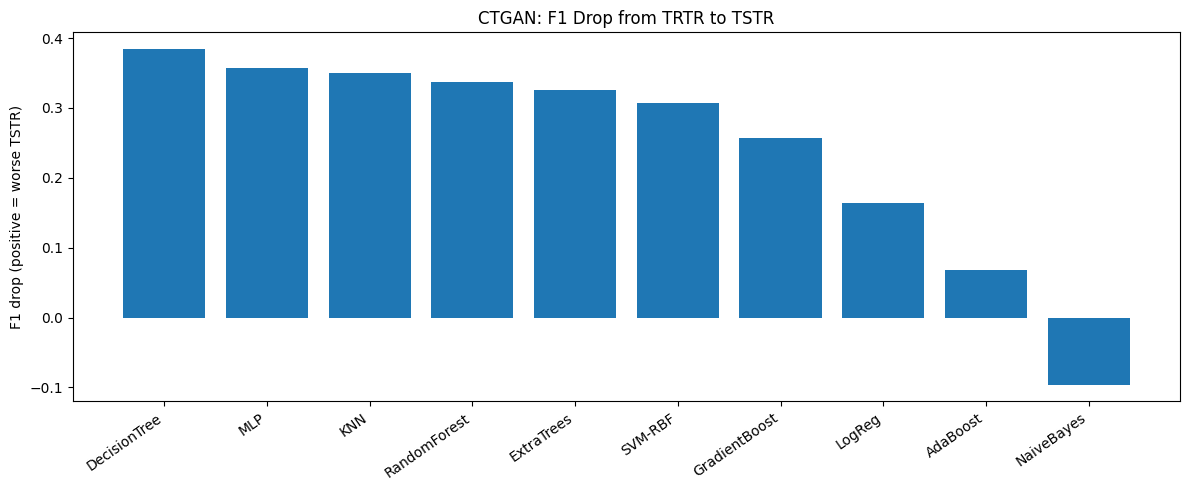


CopulaGAN - TSTR


,Model,Accuracy,Precision,Recall,F1
0,LogReg,0.7130,0.712911,0.7130,0.712954
1,GradientBoost,0.6938,0.692941,0.6938,0.693218
2,AdaBoost,0.6788,0.678351,0.6788,0.678546
3,SVM-RBF,0.6751,0.673973,0.6751,0.674305
4,RandomForest,0.6721,0.671058,0.6721,0.671395
5,NaiveBayes,0.6560,0.691704,0.6560,0.651882
6,ExtraTrees,0.6404,0.640482,0.6404,0.640440
7,MLP,0.6201,0.622715,0.6201,0.620967
8,KNN,0.6091,0.608559,0.6091,0.608806
9,DecisionTree,0.6036,0.604284,0.6036,0.603909


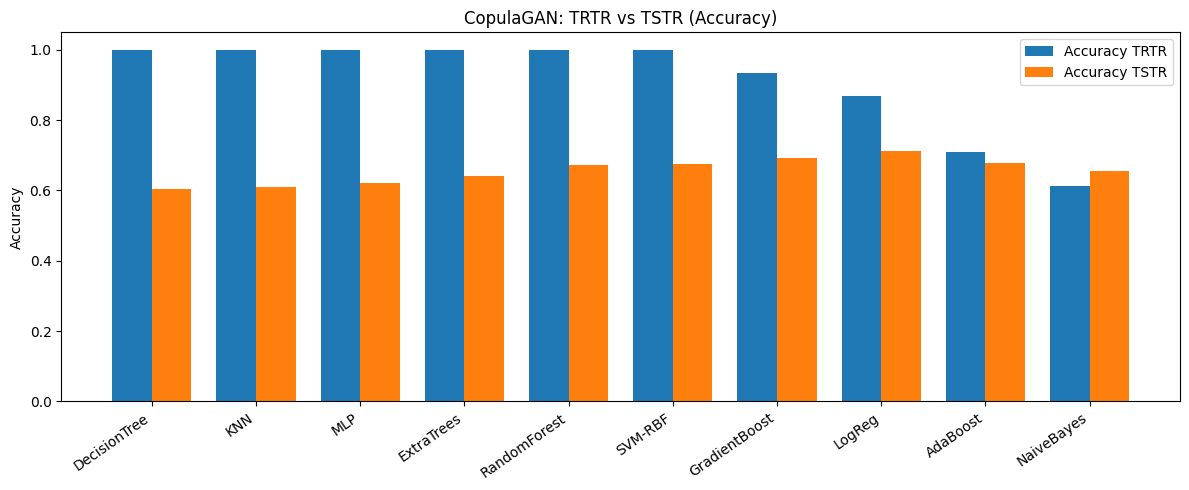

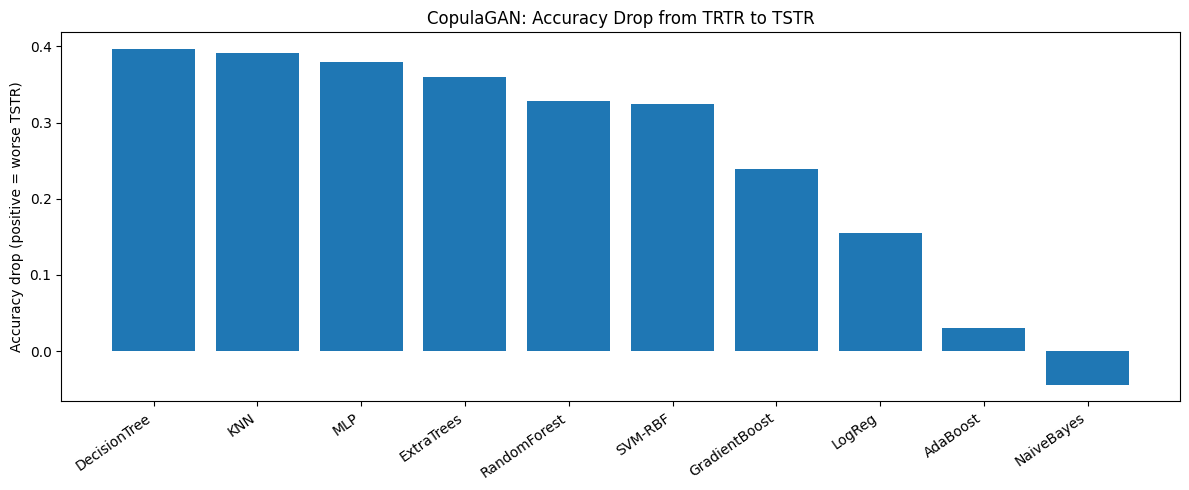

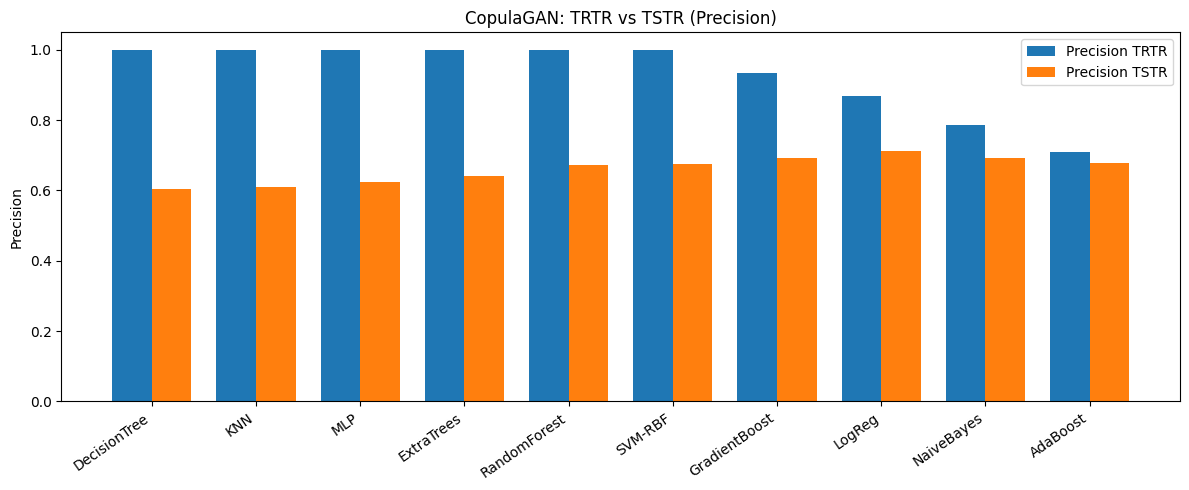

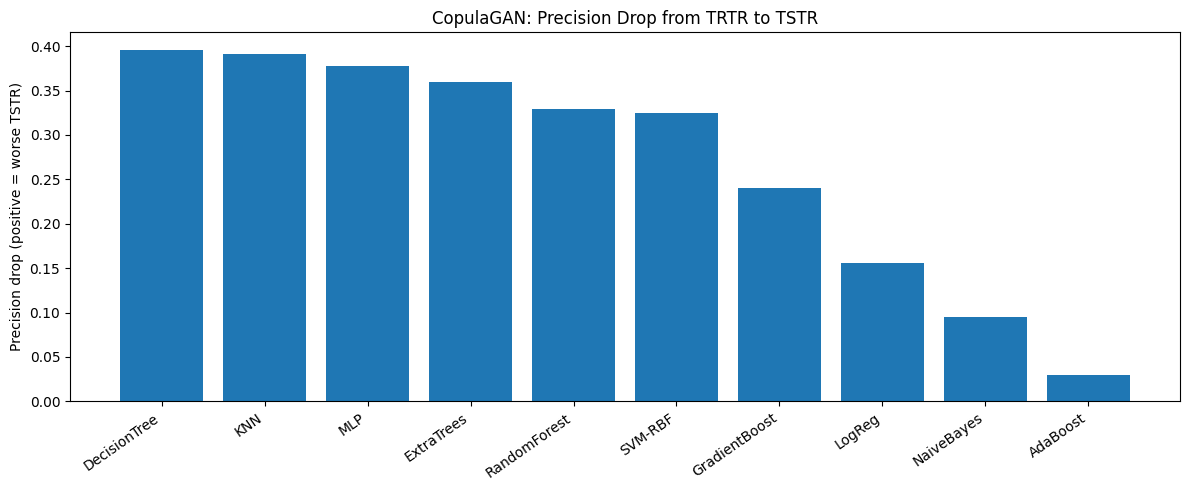

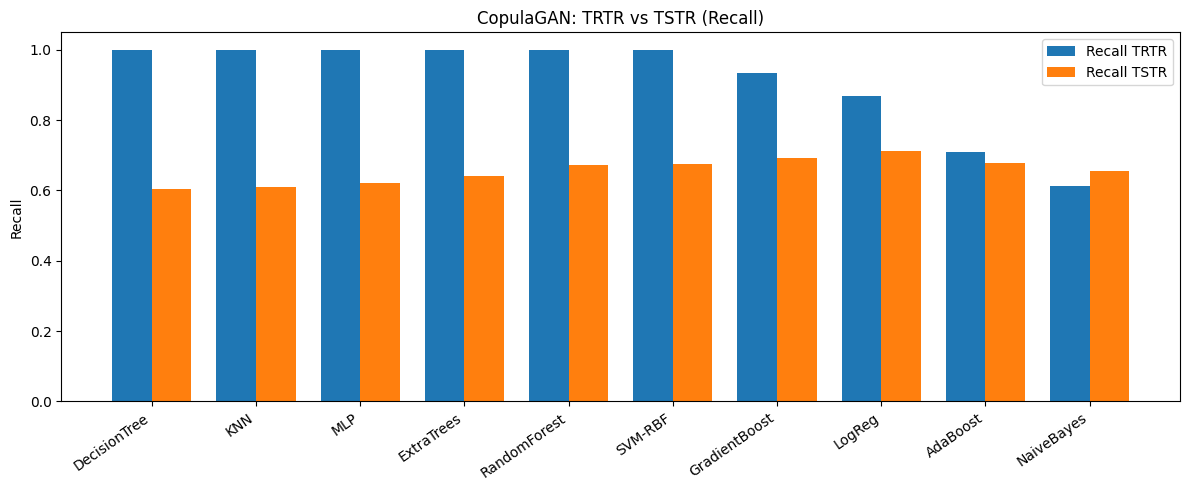

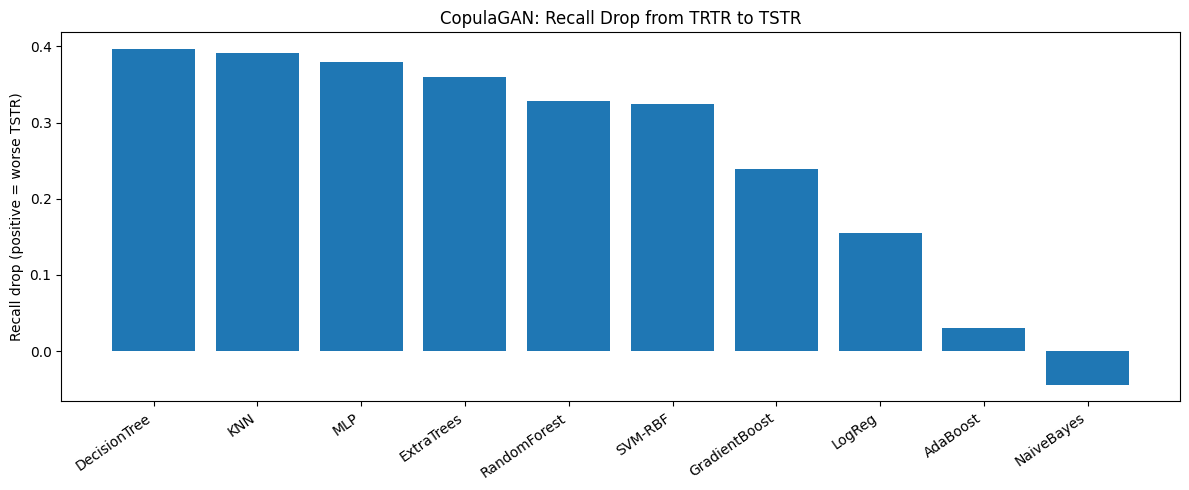

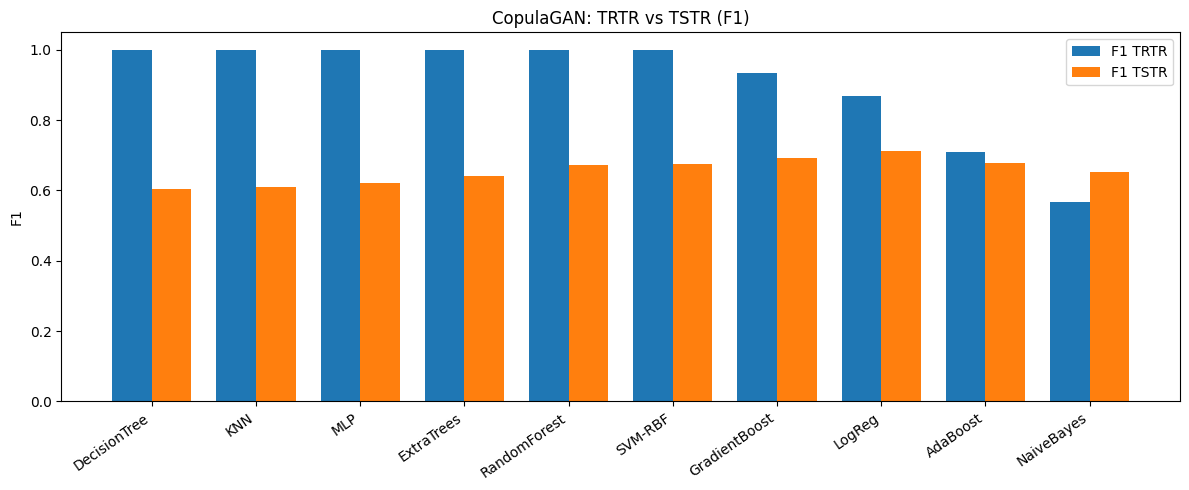

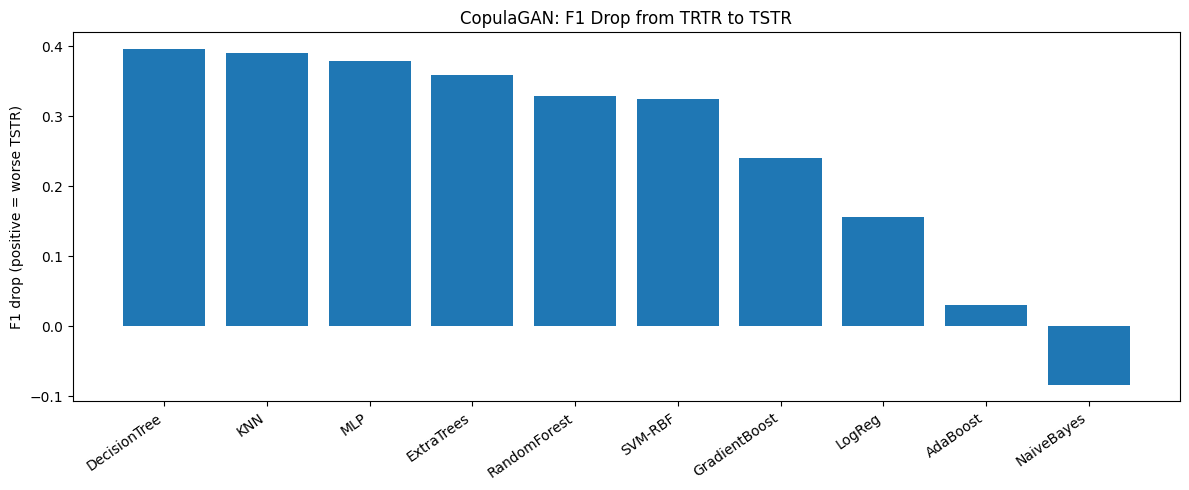


TVAE - TSTR


,Model,Accuracy,Precision,Recall,F1
0,RandomForest,0.9118,0.912908,0.9118,0.911383
1,KNN,0.9077,0.907969,0.9077,0.907446
2,SVM-RBF,0.9072,0.907739,0.9072,0.906871
3,MLP,0.9063,0.906339,0.9063,0.906126
4,ExtraTrees,0.9043,0.904454,0.9043,0.904069
5,GradientBoost,0.8324,0.832631,0.8324,0.831577
6,DecisionTree,0.8150,0.814914,0.8150,0.814178
7,LogReg,0.8059,0.806551,0.8059,0.806122
8,AdaBoost,0.6788,0.677559,0.6788,0.673670
9,NaiveBayes,0.6498,0.764397,0.6498,0.626474


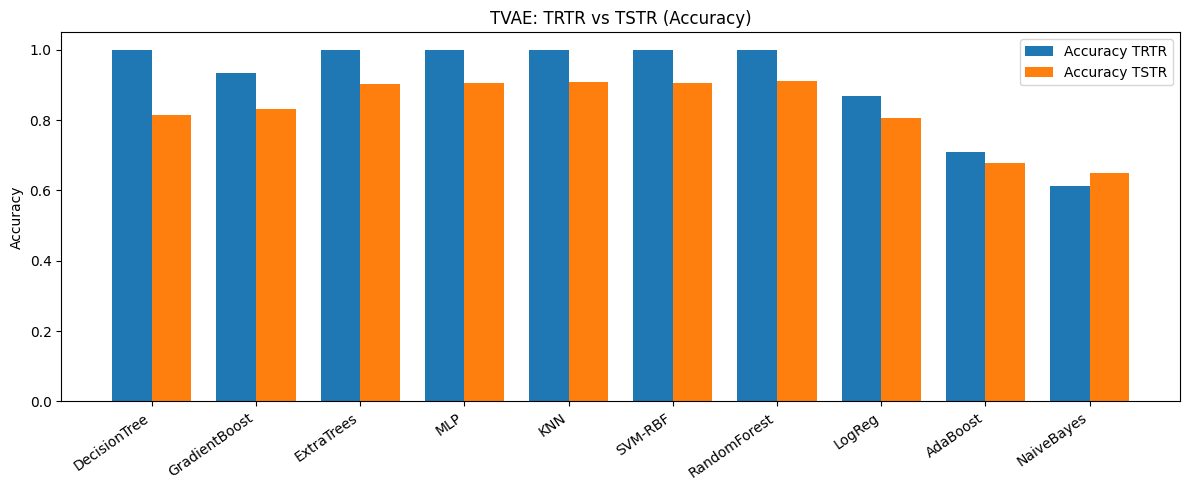

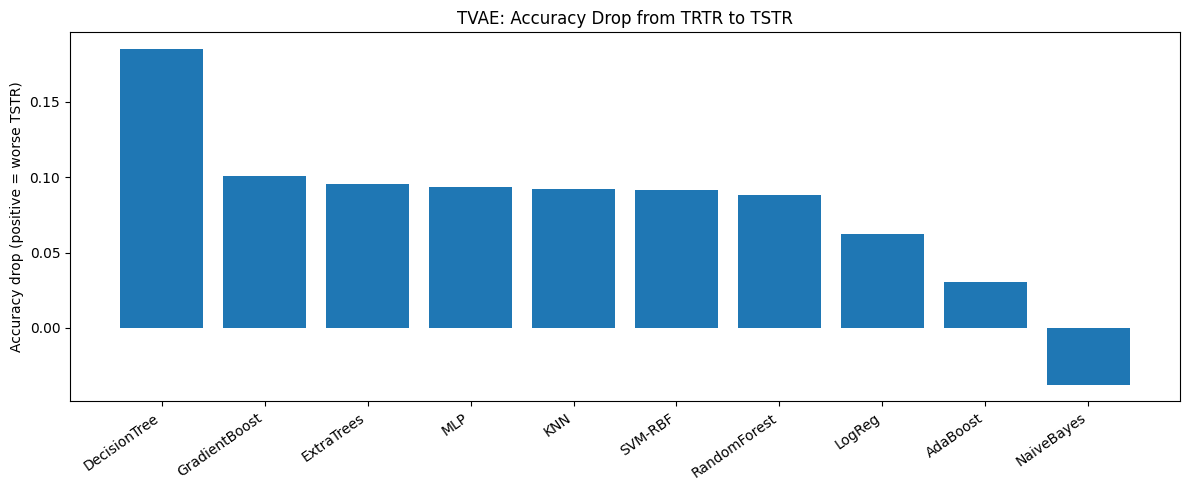

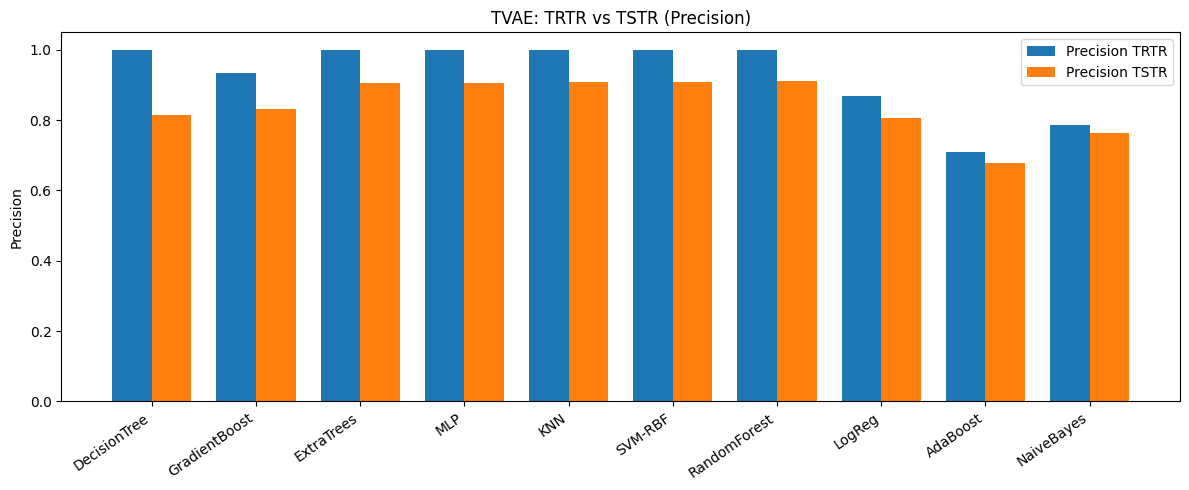

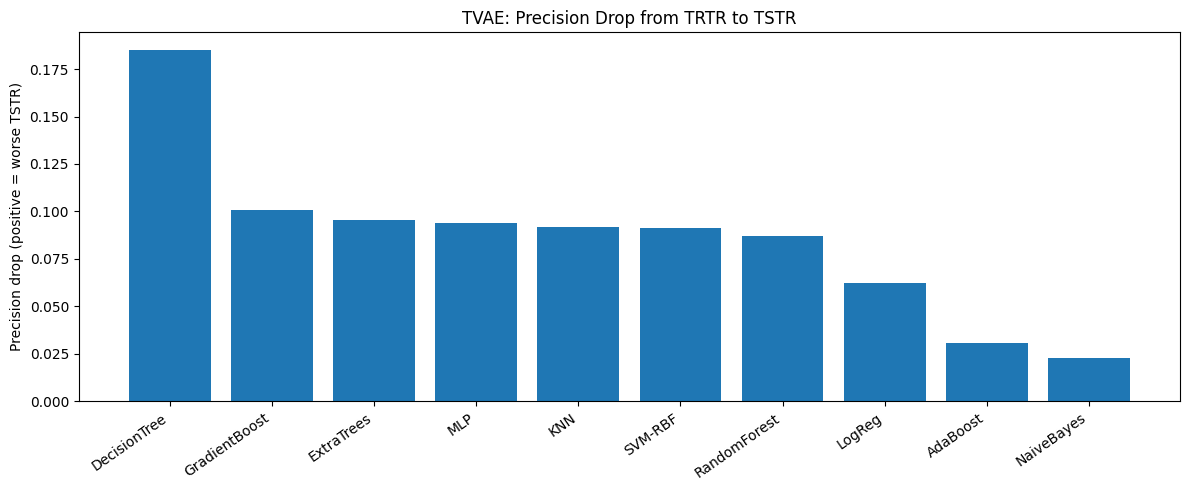

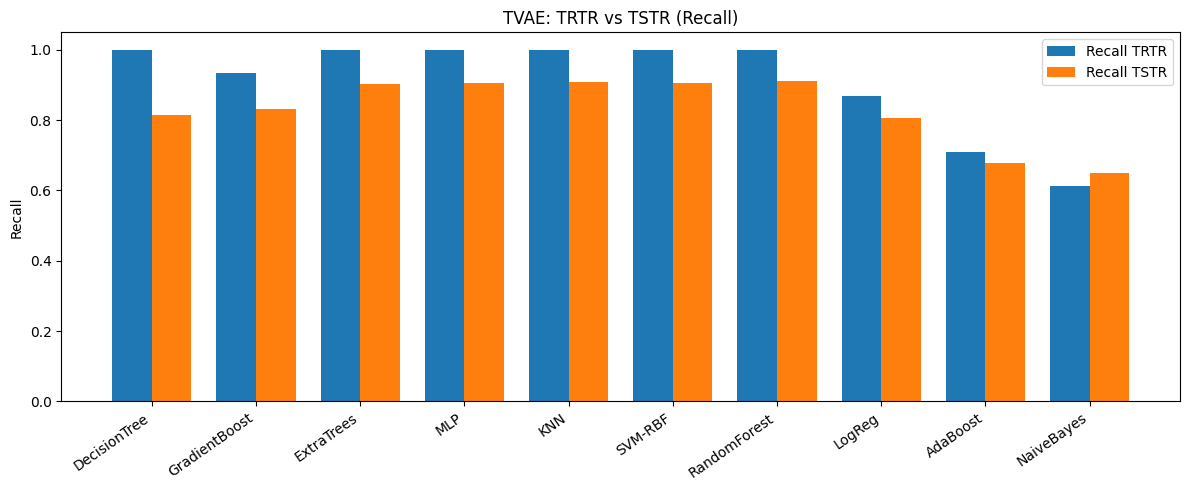

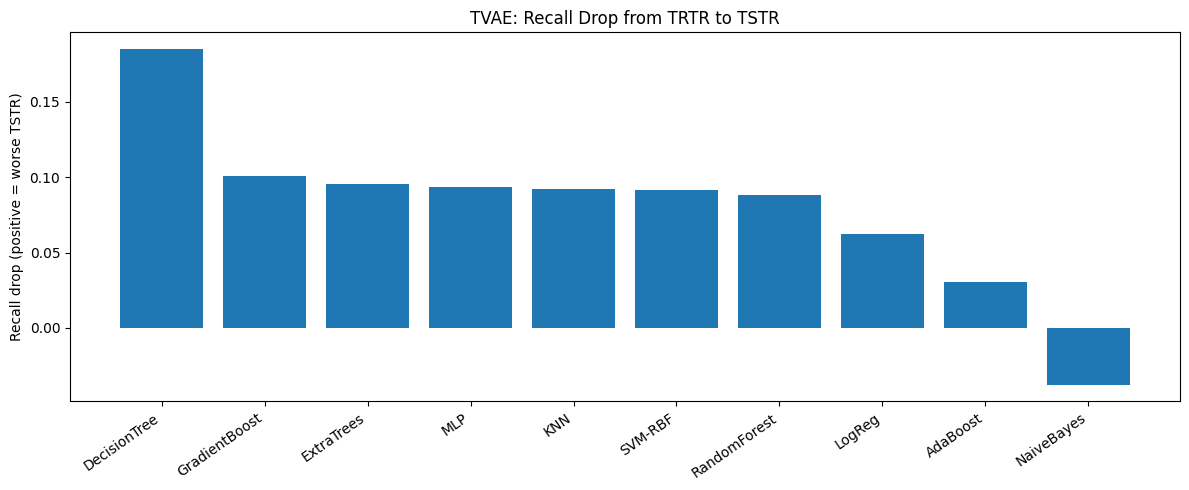

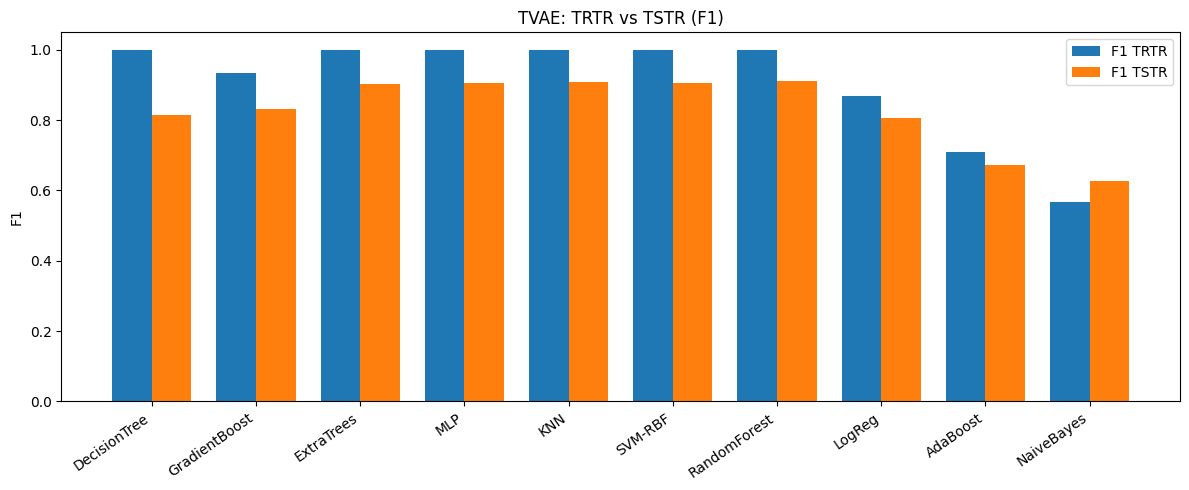

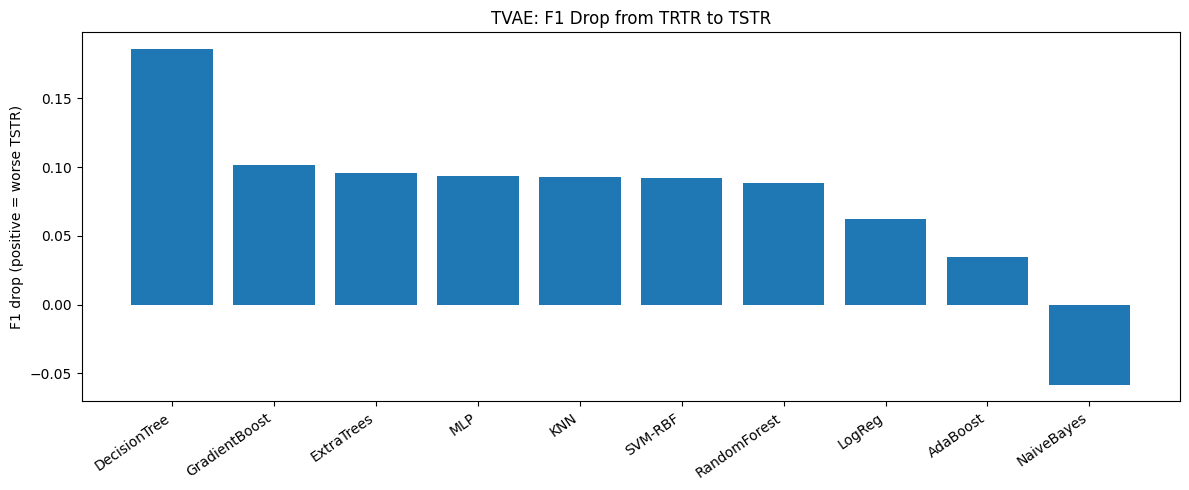


GaussianCopula - TSTR


,Model,Accuracy,Precision,Recall,F1
0,LogReg,0.6585,0.659508,0.6585,0.647011
1,SVM-RBF,0.6552,0.658483,0.6552,0.640256
2,AdaBoost,0.6503,0.651129,0.6503,0.637409
3,GradientBoost,0.6433,0.648118,0.6433,0.623559
4,RandomForest,0.6268,0.623286,0.6268,0.617868
5,ExtraTrees,0.6080,0.603326,0.6080,0.594535
6,NaiveBayes,0.5710,0.621670,0.5710,0.555126
7,KNN,0.5536,0.552336,0.5536,0.552878
8,MLP,0.5531,0.552293,0.5531,0.552660
9,DecisionTree,0.5163,0.515721,0.5163,0.515996


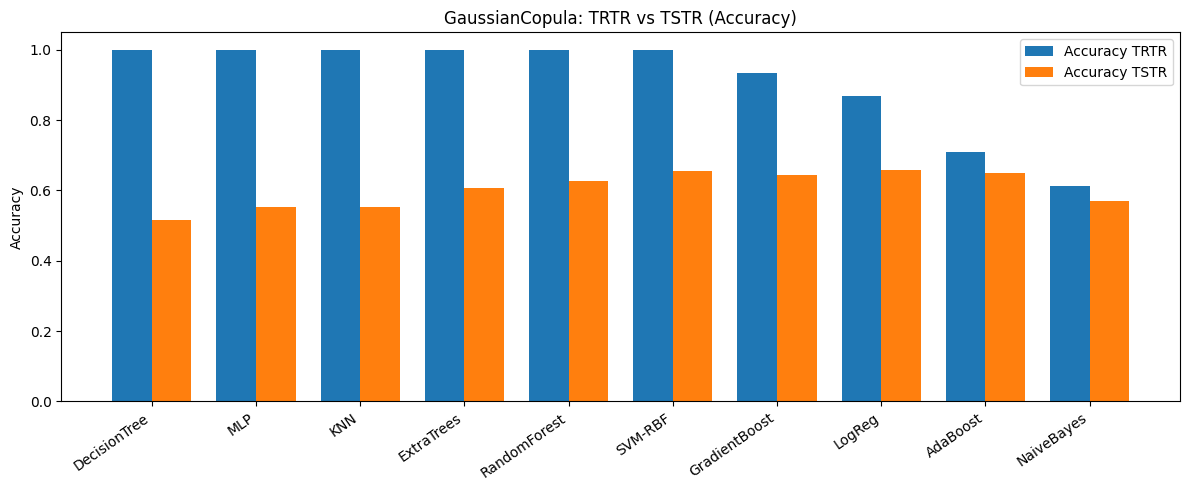

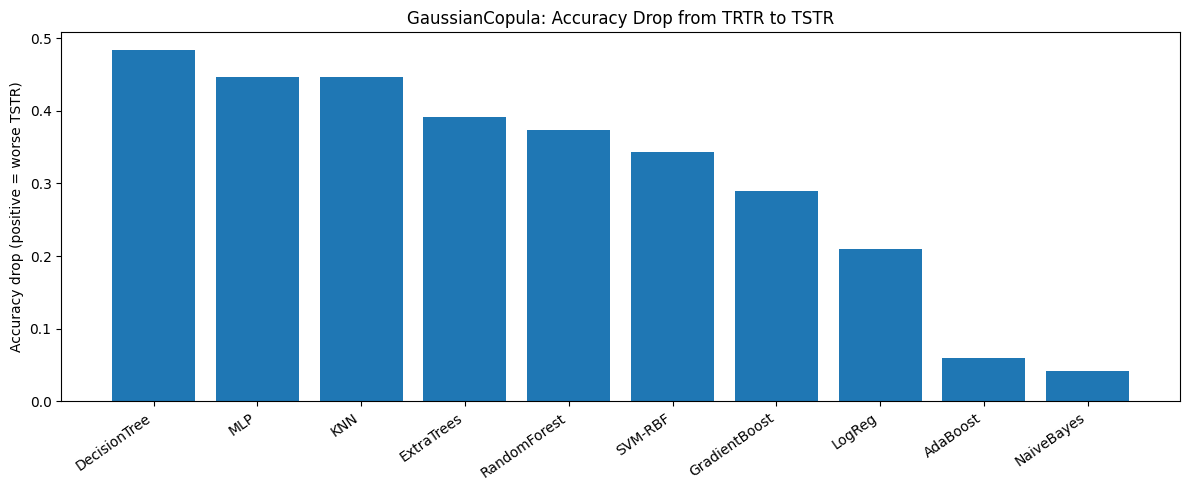

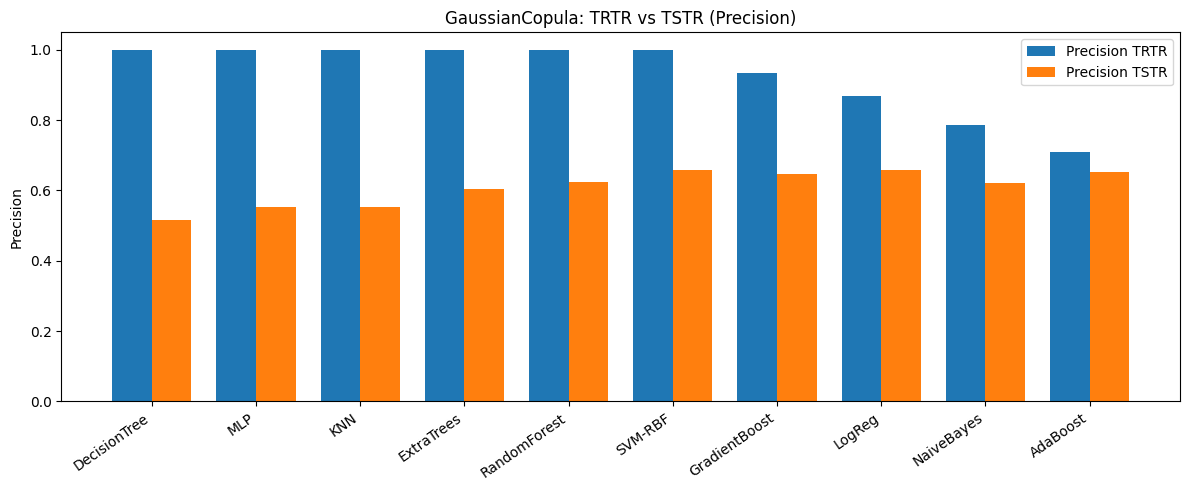

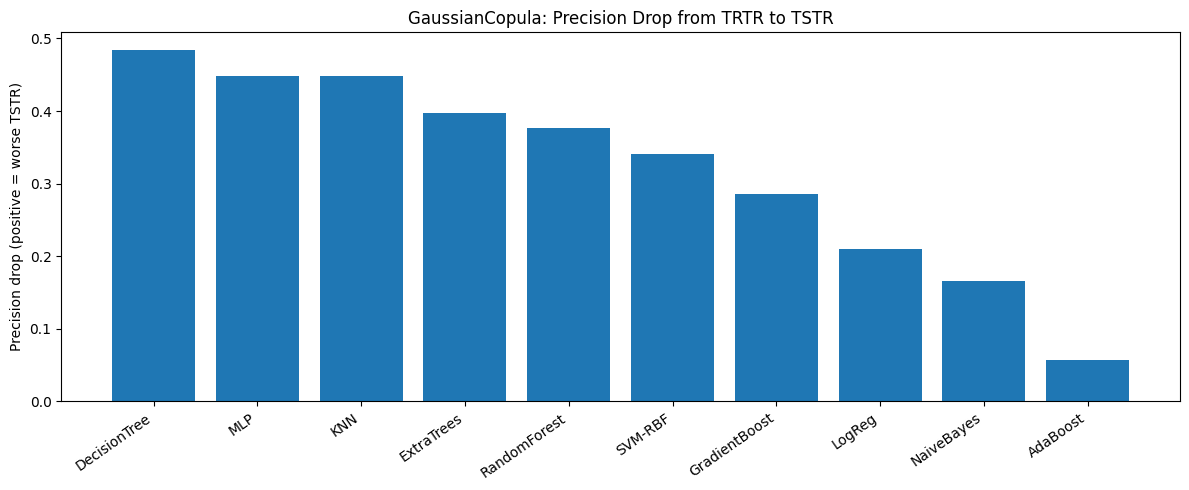

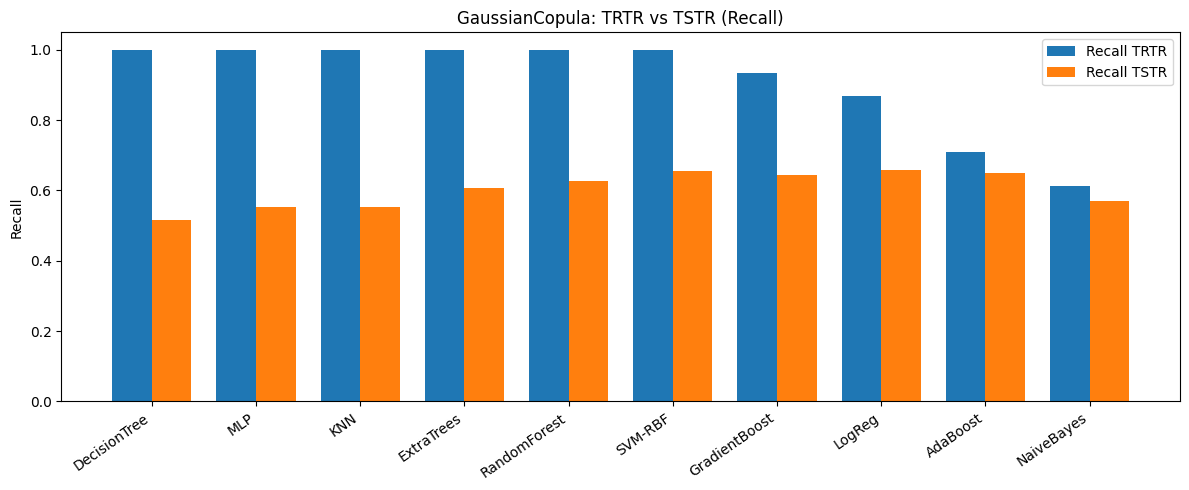

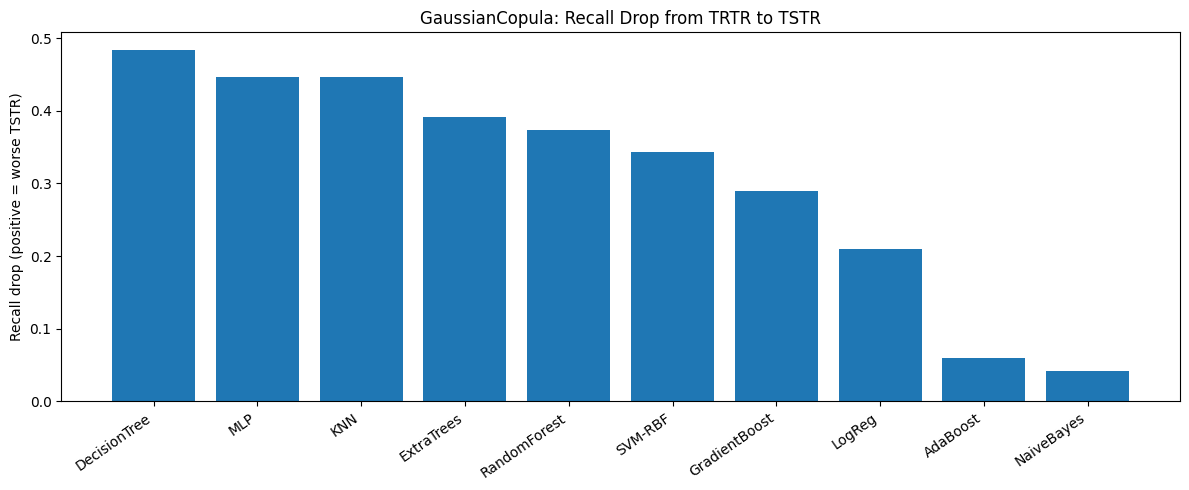

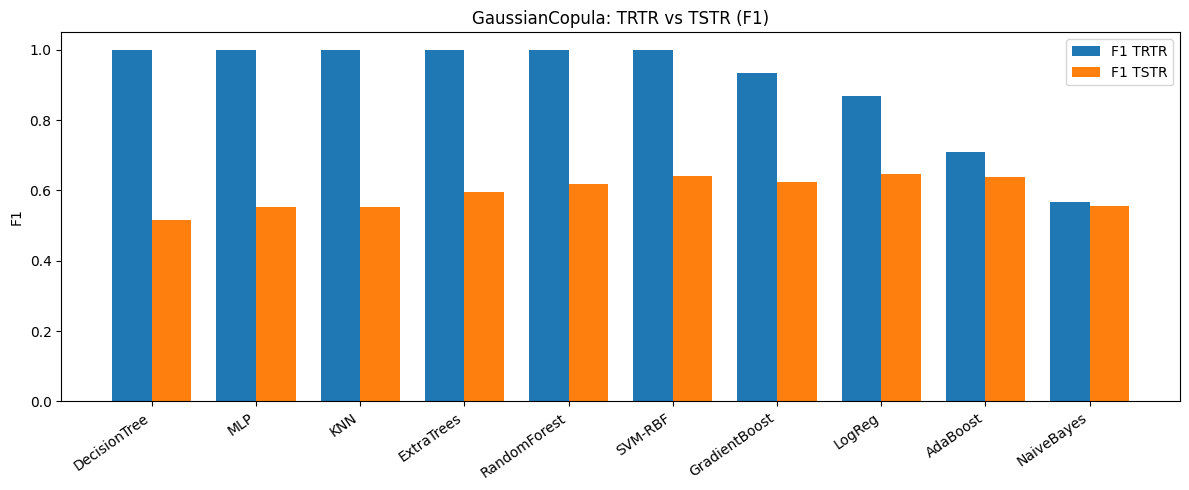

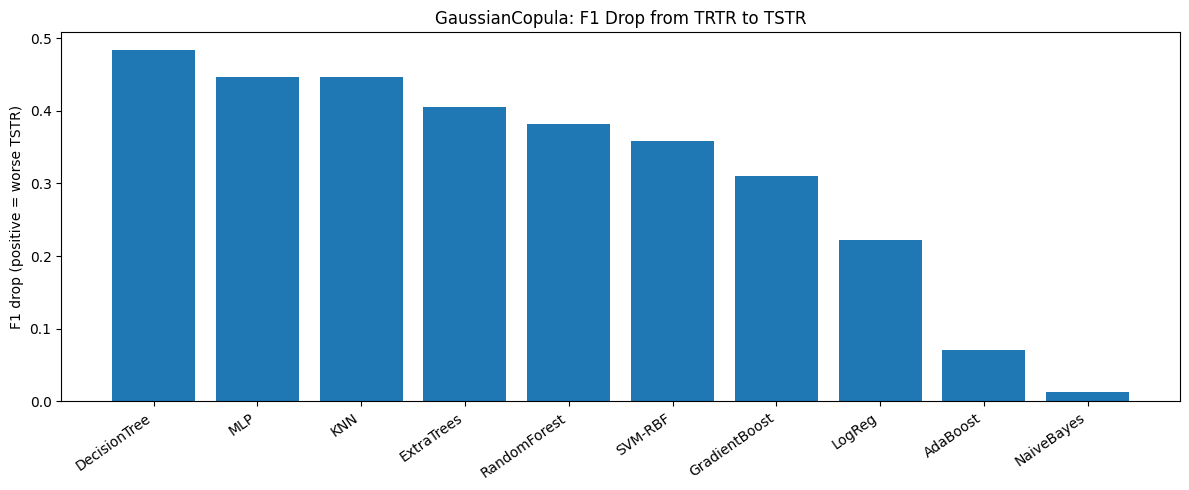


Average Accuracy drop by synthetic generator (positive = worse TSTR):


,Synthetic_Model,Accuracy_Drop
3,TVAE,0.08032
0,CTGAN,0.24379
1,CopulaGAN,0.25604
2,GaussianCopula,0.30863



Average Precision drop by synthetic generator (positive = worse TSTR):


,Synthetic_Model,Precision_Drop
3,TVAE,0.086136
0,CTGAN,0.259808
1,CopulaGAN,0.269985
2,GaussianCopula,0.321096



Average Recall drop by synthetic generator (positive = worse TSTR):


,Synthetic_Model,Recall_Drop
3,TVAE,0.08032
0,CTGAN,0.24379
1,CopulaGAN,0.25604
2,GaussianCopula,0.30863



Average F1 drop by synthetic generator (positive = worse TSTR):


,Synthetic_Model,F1_Drop
3,TVAE,0.078978
0,CTGAN,0.245317
1,CopulaGAN,0.252128
2,GaussianCopula,0.314040


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# Helpers
# -----------------------------
HIGHER_IS_BETTER = {"Accuracy", "Precision", "Recall", "F1"}

def compute_drop(trtr_val, tstr_val, metric):
    """Positive drop => TSTR is worse than TRTR."""
    if metric in HIGHER_IS_BETTER:
        return trtr_val - tstr_val
    return tstr_val - trtr_val

def make_ohe_dense():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def evaluate_models(train_df, test_df, label_col, models):
    """
    Classification evaluator for mixed-type tables.
    Handles:
    - numeric + categorical features
    - missing values
    - unknown categories in synthetic data
    """
    train_df = train_df.copy()
    test_df = test_df.copy()

    if label_col not in train_df.columns or label_col not in test_df.columns:
        raise ValueError(f"label_col='{label_col}' must exist in both train_df and test_df")

    X_train = train_df.drop(columns=[label_col]).copy()
    y_train = train_df[label_col].astype(str)

    X_test = test_df.drop(columns=[label_col]).copy()
    y_test = test_df[label_col].astype(str)

    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_train.columns if c not in num_cols]

    for c in cat_cols:
        X_train[c] = X_train[c].astype(str)
        X_test[c] = X_test[c].astype(str)

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_cols,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", make_ohe_dense()),
                    ]
                ),
                cat_cols,
            ),
        ],
        remainder="drop",
    )

    rows = []
    for model_name, estimator in models.items():
        pipe = Pipeline(
            steps=[
                ("prep", preprocessor),
                ("model", clone(estimator)),
            ]
        )
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        rows.append(
            {
                "Model": model_name,
                "Accuracy": float(accuracy_score(y_test, y_pred)),
                "Precision": float(precision_score(y_test, y_pred, average="weighted", zero_division=0)),
                "Recall": float(recall_score(y_test, y_pred, average="weighted", zero_division=0)),
                "F1": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
            }
        )

    return pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="F1"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )

    df["Drop"] = df.apply(
        lambda r: compute_drop(r[f"{metric}_TRTR"], r[f"{metric}_TSTR"], metric),
        axis=1
    ).astype(float)

    df = df.sort_values("Drop", ascending=False)
    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w / 2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_drop(comparison_df, synth_name, metric):
    drop_col = f"{metric}_Drop"
    if drop_col not in comparison_df.columns:
        return

    df = comparison_df.sort_values(drop_col, ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df[drop_col])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(f"{metric} drop (positive = worse TSTR)")
    plt.title(f"{synth_name}: {metric} Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

# -----------------------------
# Main
# -----------------------------
label_col = "class"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label="class",
    models=models
)

metrics_to_use = ["Accuracy", "Precision", "Recall", "F1"]

all_comp = []

for synth_name in model_order:
    synth_train = synthetic_datasets[synth_name].reindex(columns=data.columns).copy()

    tstr_results = evaluate_models(
        train_df=synth_train,
        test_df=data,
        label="class",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results,
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    comparison["Synthetic_Model"] = synth_name

    for metric in metrics_to_use:
        comparison[f"{metric}_Drop"] = comparison.apply(
            lambda r: compute_drop(r[f"{metric}_TRTR"], r[f"{metric}_TSTR"], metric),
            axis=1
        )

    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in metrics_to_use:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)
        plot_metric_drop(comparison, synth_name, metric)

combined_comparison = pd.concat(all_comp, ignore_index=True)

for metric in metrics_to_use:
    summary = (
        combined_comparison
        .groupby("Synthetic_Model", as_index=False)[f"{metric}_Drop"]
        .mean()
        .sort_values(f"{metric}_Drop")
    )
    print(f"\nAverage {metric} drop by synthetic generator (positive = worse TSTR):")
    display(summary)


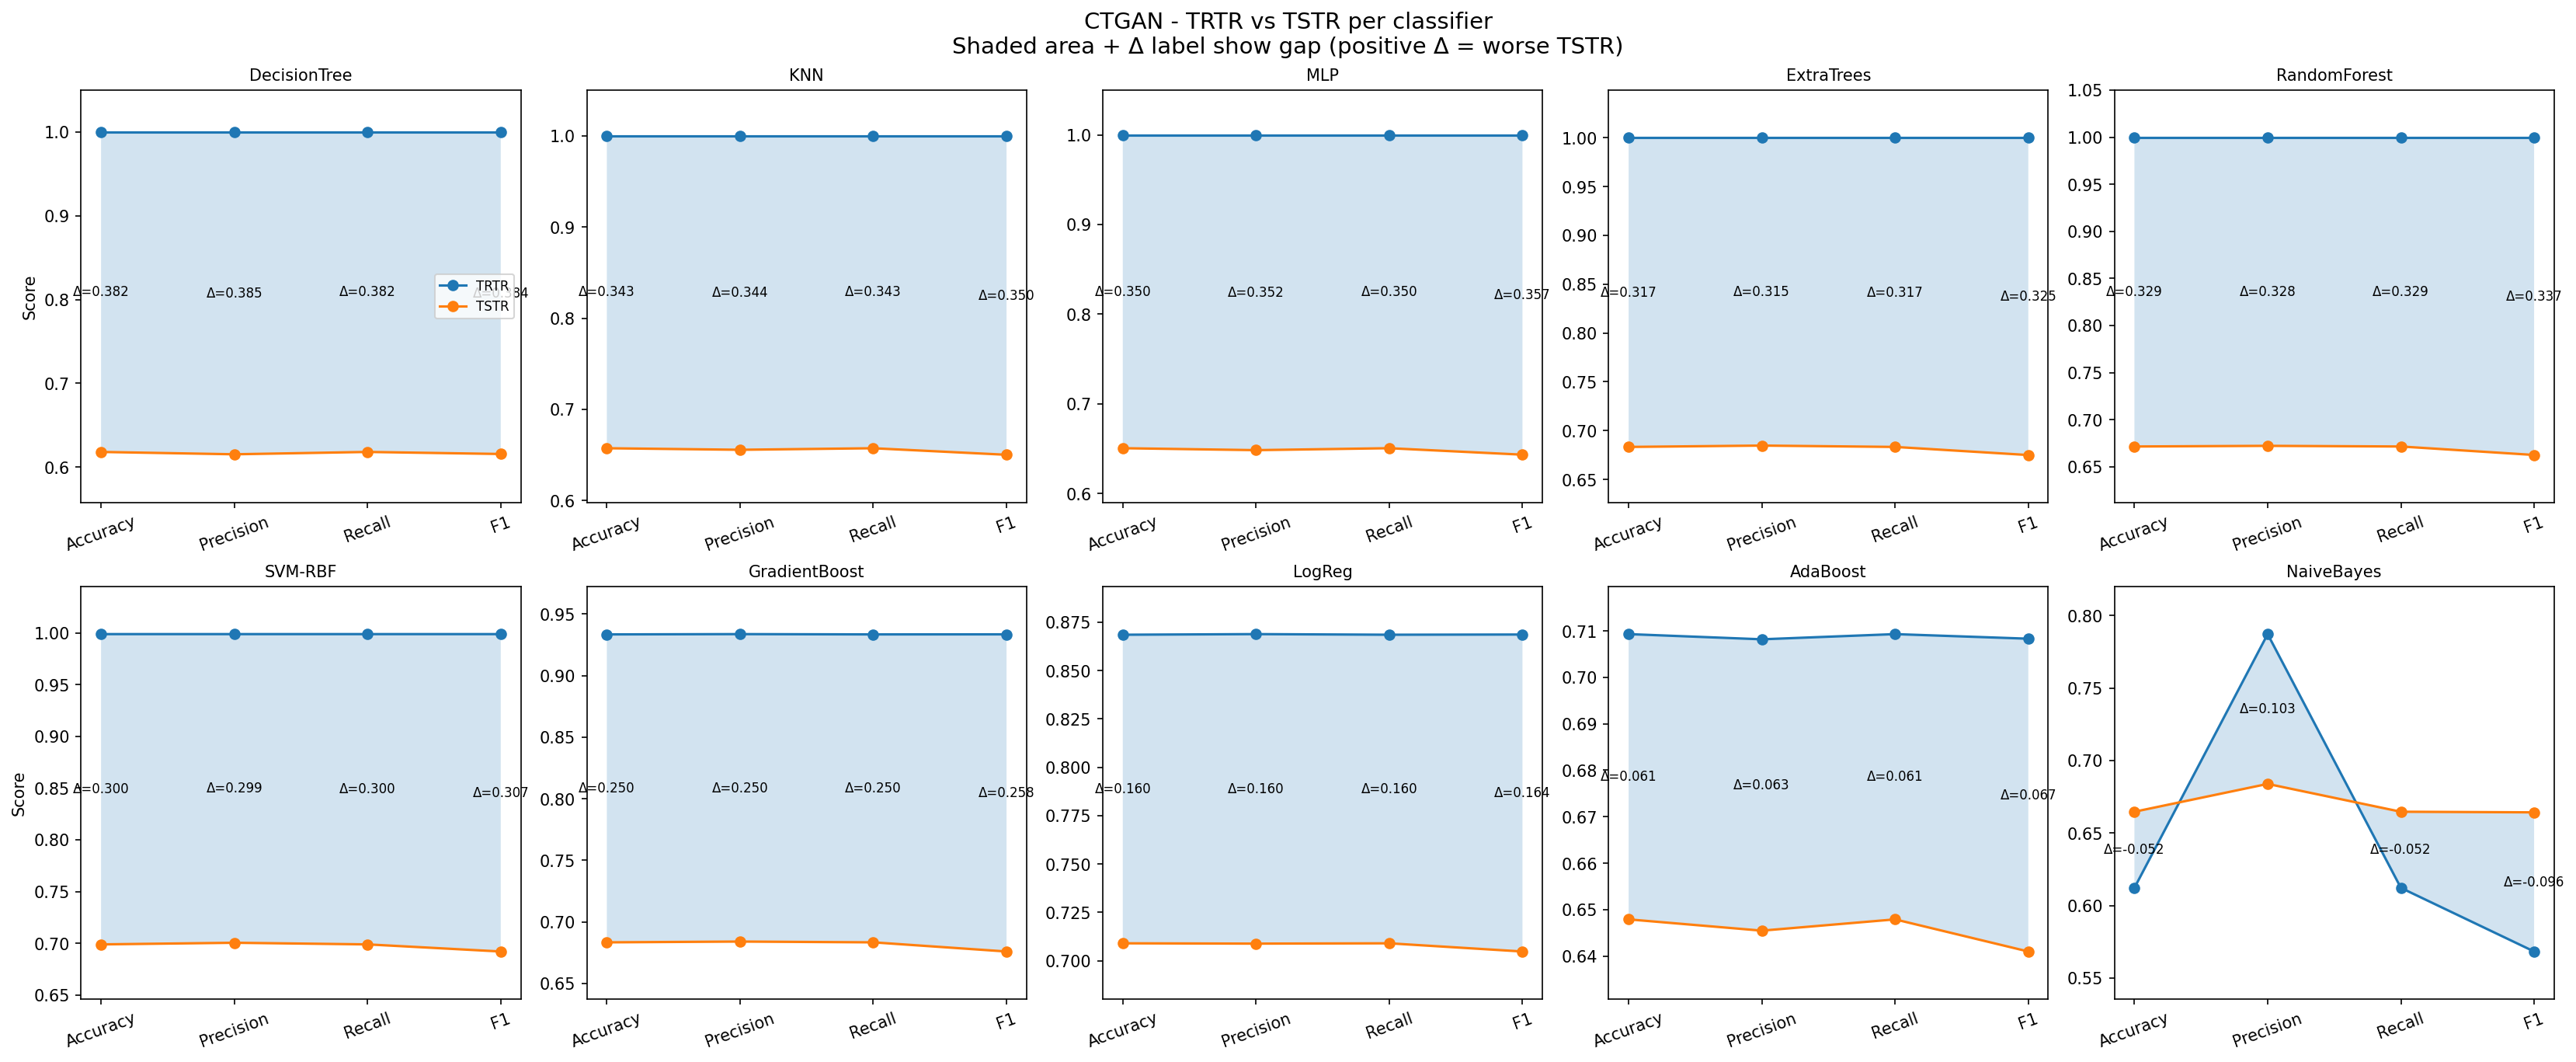

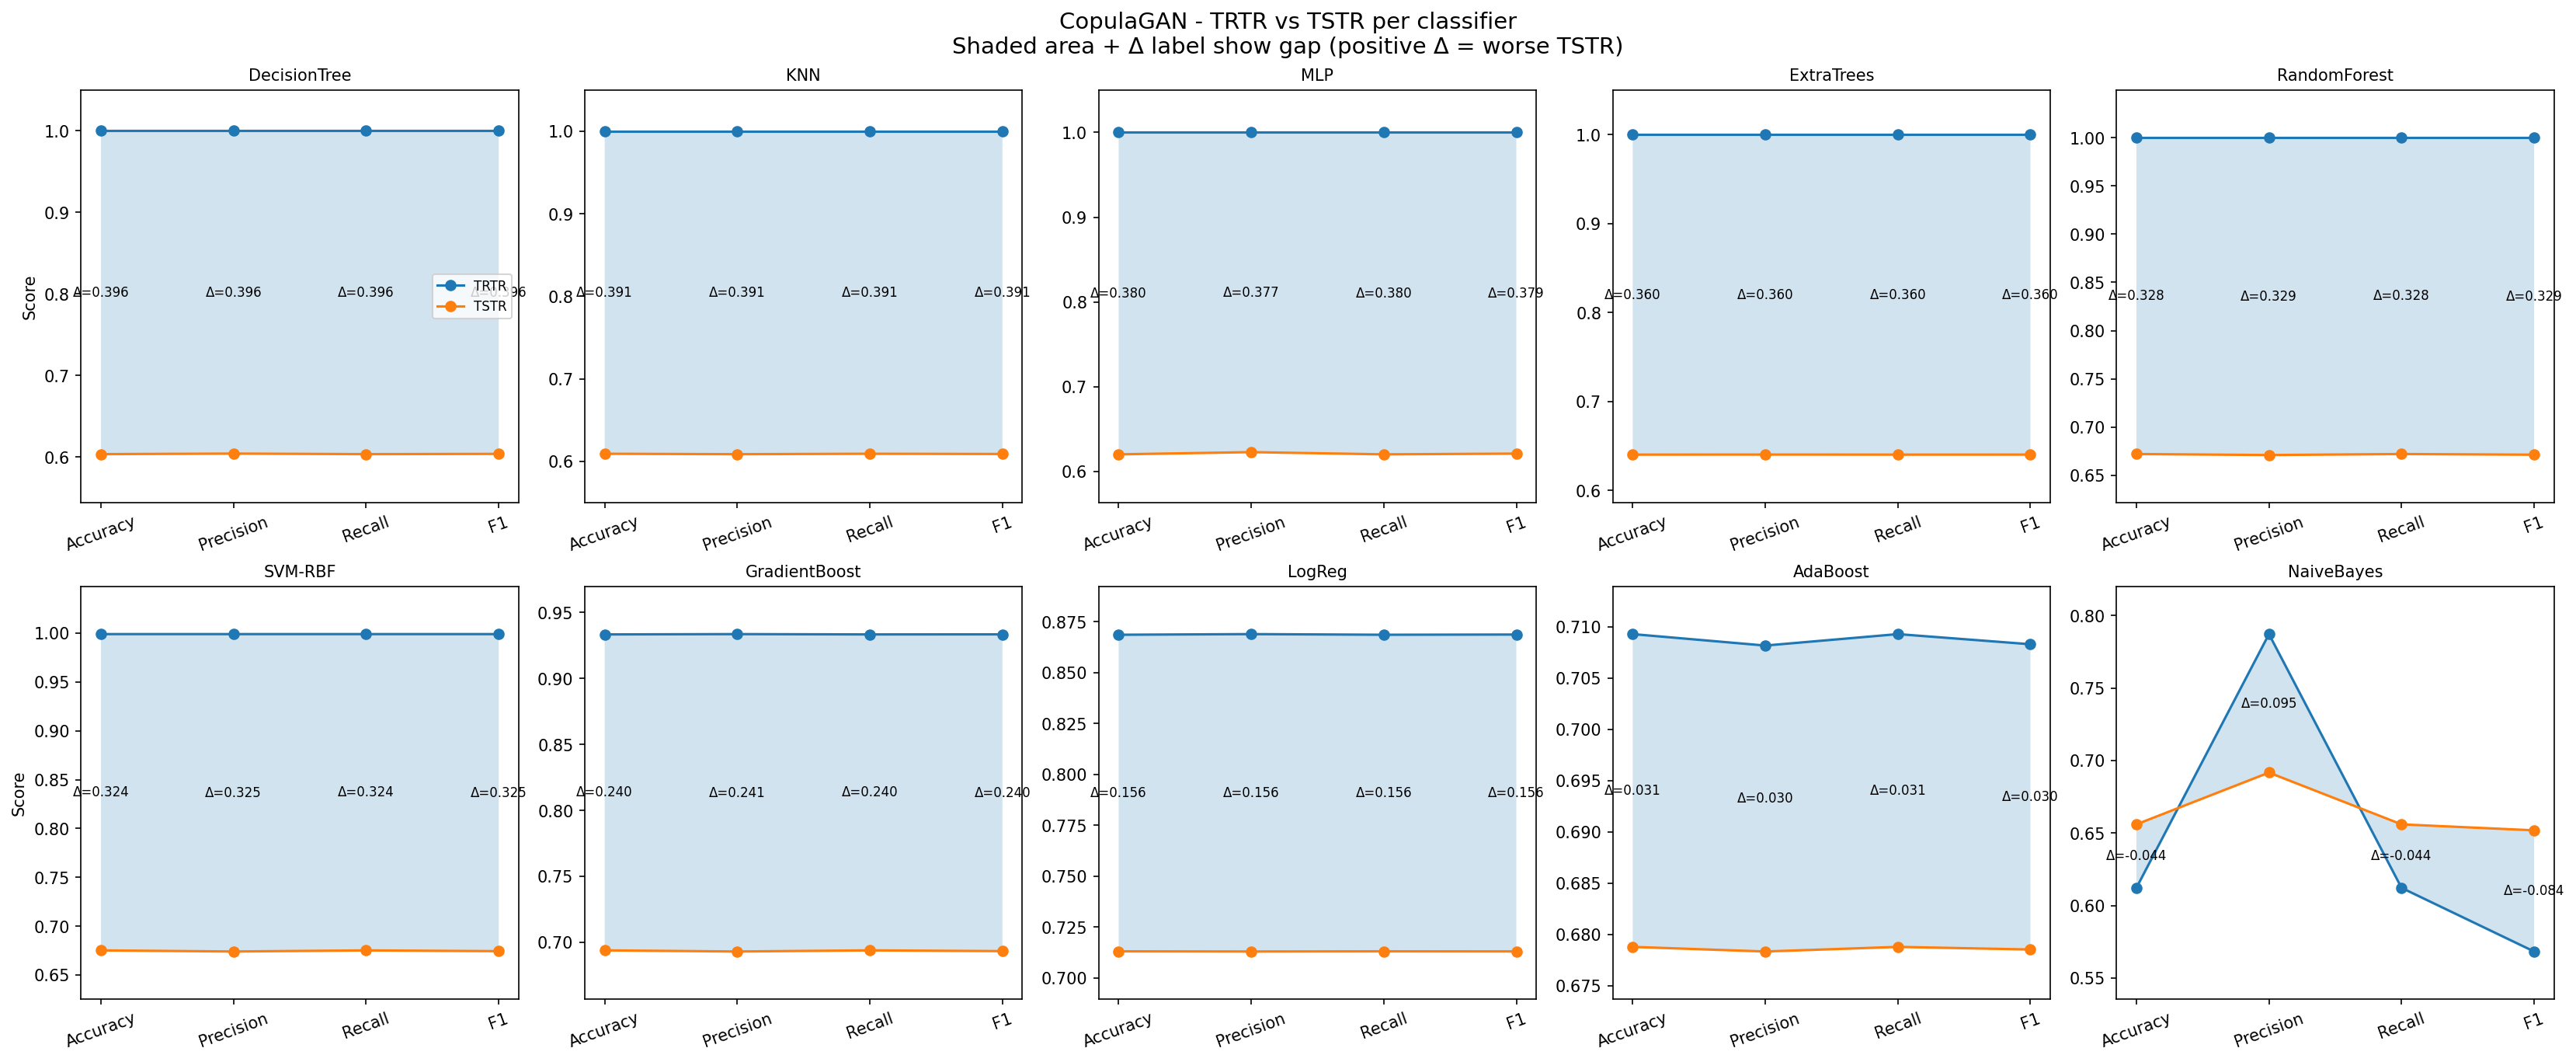

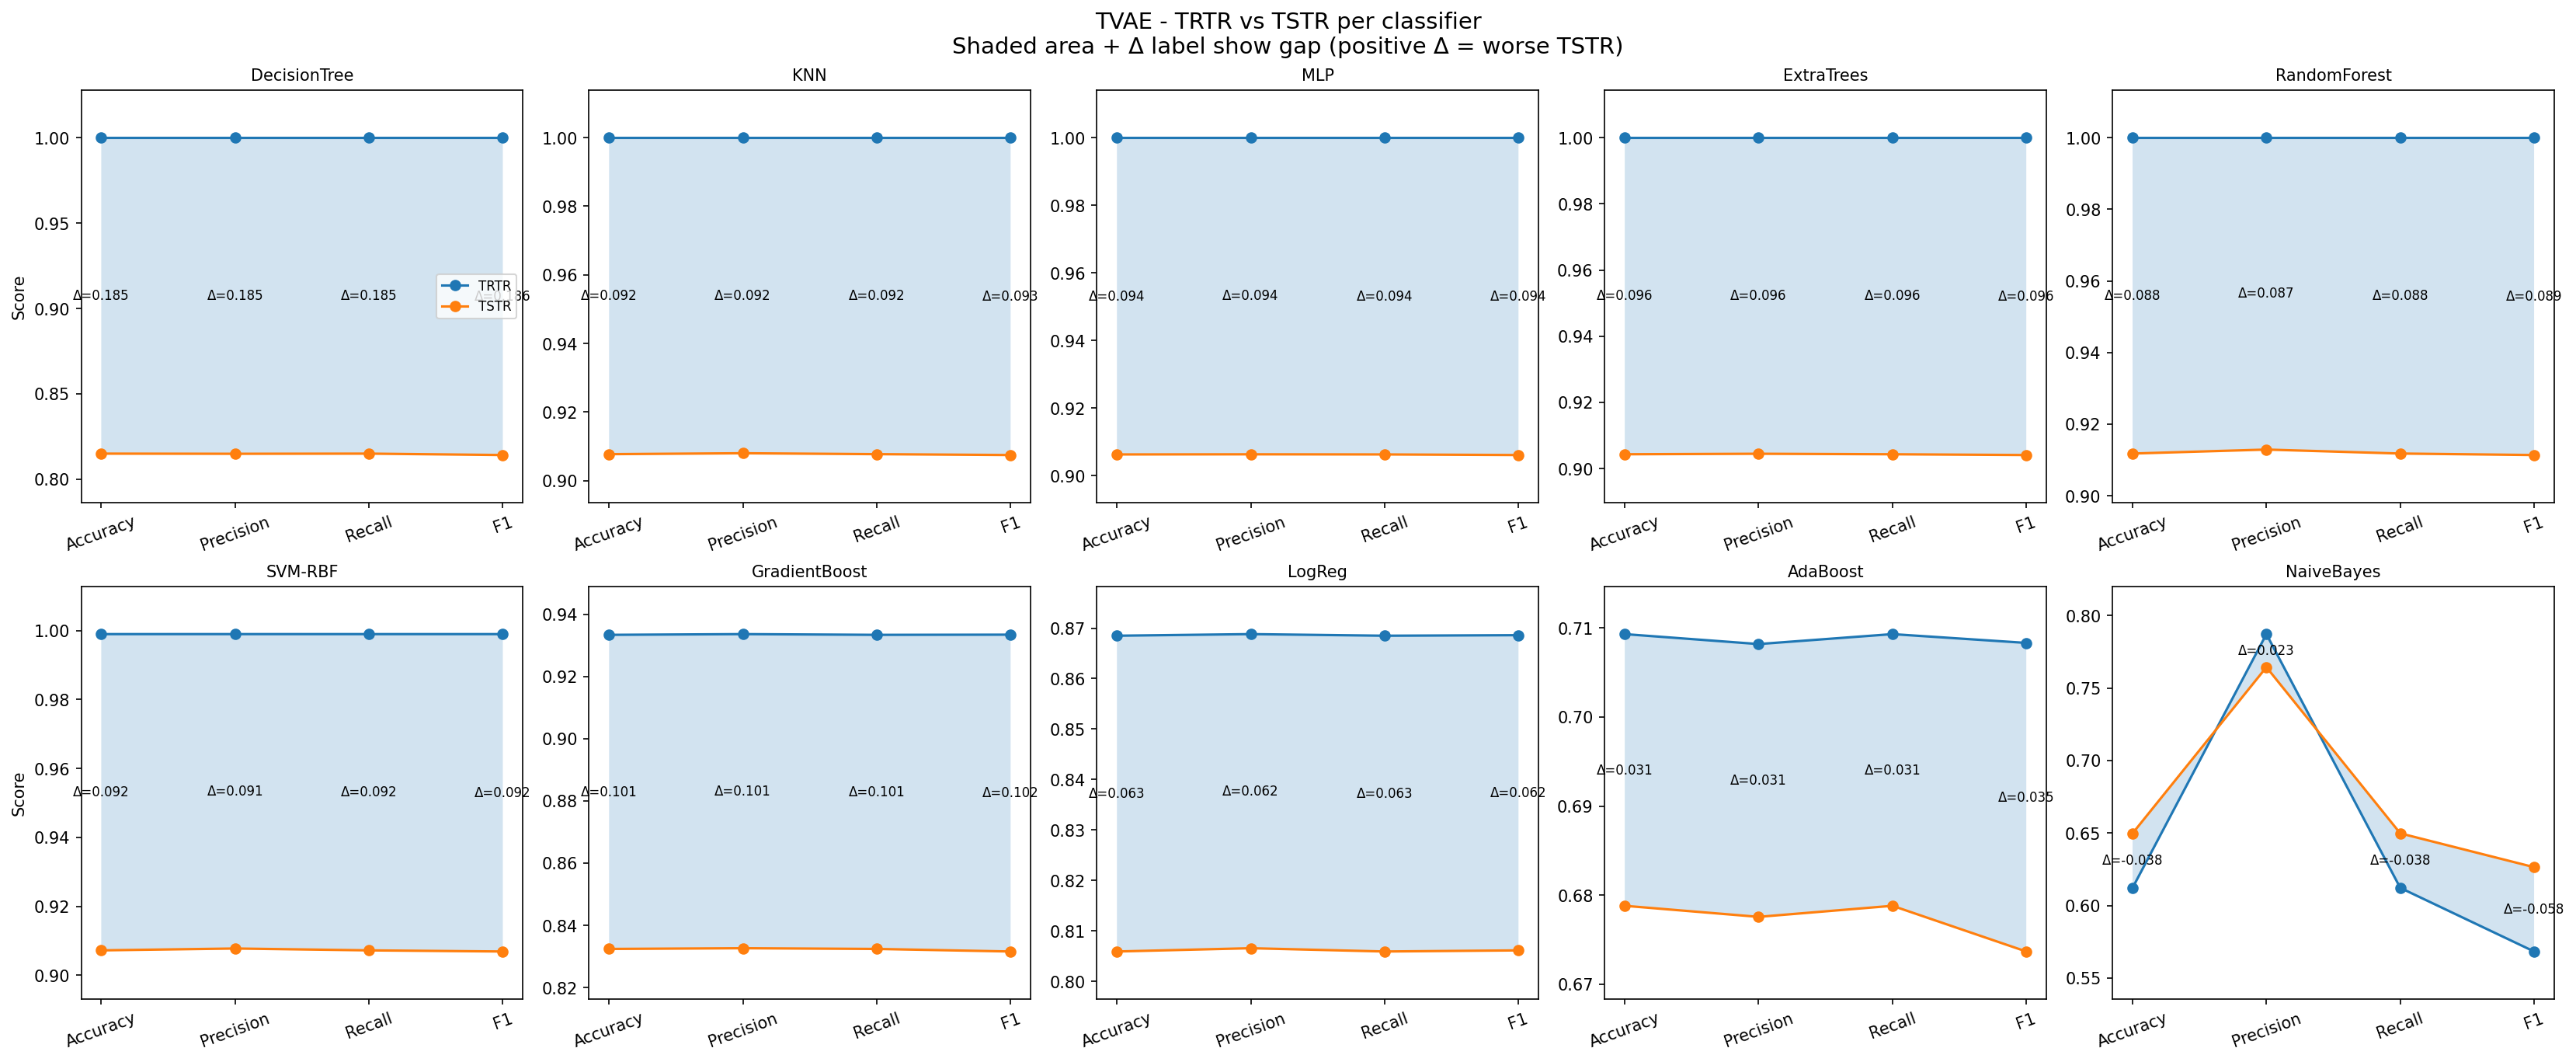

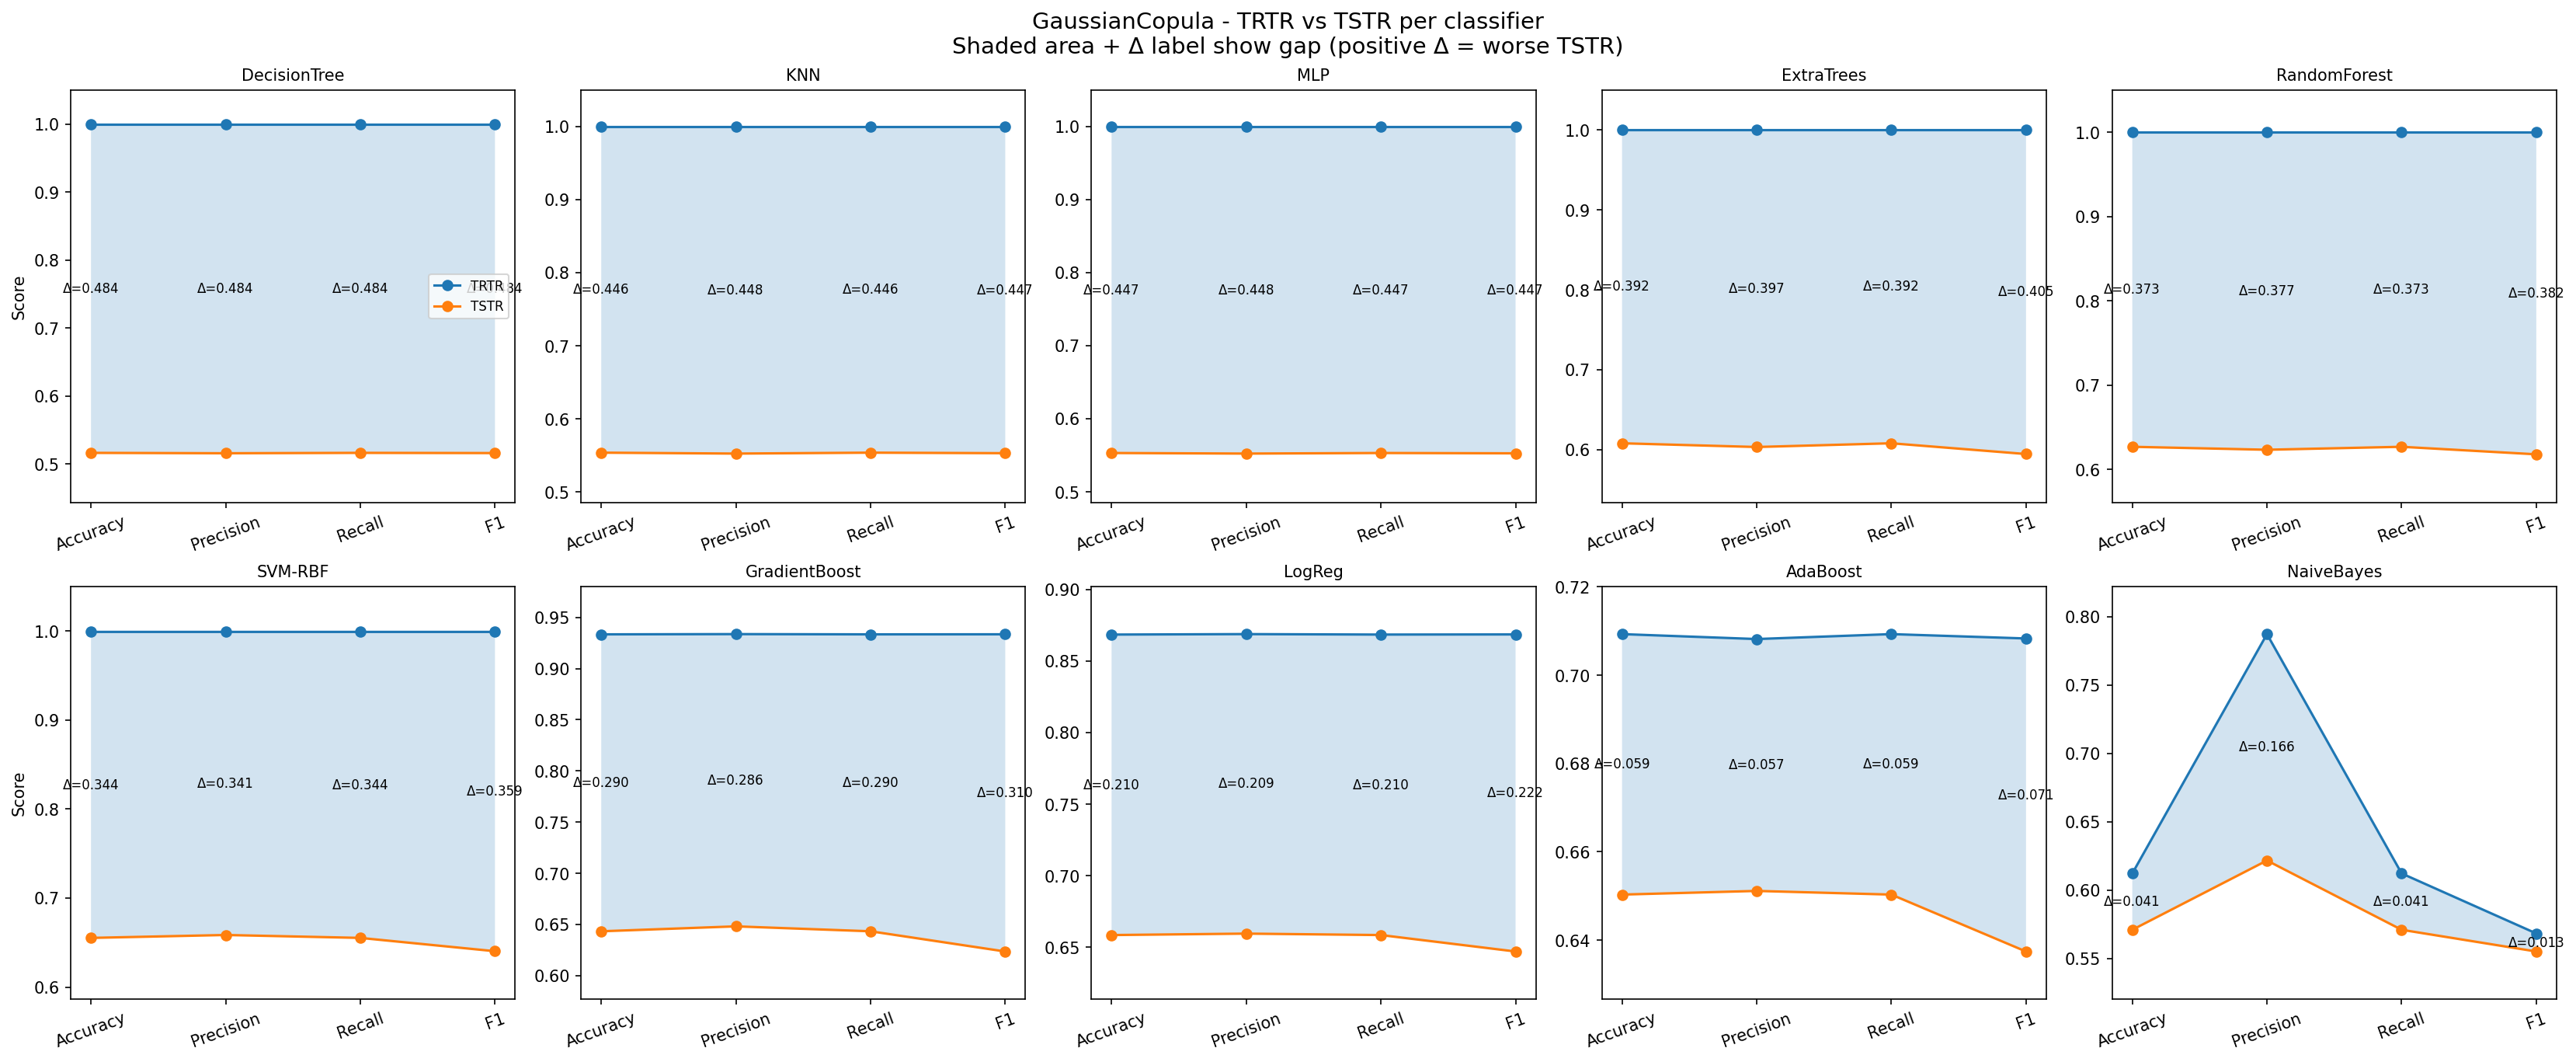

In [34]:
import numpy as np
import matplotlib.pyplot as plt

HIGHER_IS_BETTER = {"Accuracy", "Precision", "Recall", "F1"}

def compute_drop(trtr_value, tstr_value, metric):
    """
    Positive drop means TSTR is worse than TRTR.
    For classification metrics, higher is better:
    drop = TRTR - TSTR
    """
    if metric in HIGHER_IS_BETTER:
        return trtr_value - tstr_value
    return tstr_value - trtr_value

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    preferred_metrics = ["Accuracy", "Precision", "Recall", "F1"]
    metrics = [m for m in preferred_metrics if m in trtr_results.columns and m in tstr_results.columns]

    if not metrics:
        print(f"No common classification metrics found for {generator_name}.")
        return

    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, model_name in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[model_name].values.astype(float)
        b = tstr.loc[model_name].values.astype(float)
        d = np.array([compute_drop(ai, bi, metric) for ai, bi, metric in zip(a, b, metrics)])

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        for xi, ai, bi, di in zip(x, a, b, d):
            ax.text(xi, (ai + bi) / 2, f"Δ={di:.3f}", ha="center", va="center", fontsize=8)

        ax.set_title(model_name, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics, rotation=20)

        y_min = min(np.nanmin(a), np.nanmin(b))
        y_max = max(np.nanmax(a), np.nanmax(b))
        if np.isfinite(y_min) and np.isfinite(y_max):
            pad = (y_max - y_min) * 0.15 if y_max > y_min else 0.05
            ax.set_ylim(max(0, y_min - pad), min(1.05, y_max + pad))

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="best")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier\n"
        f"Shaded area + Δ label show gap (positive Δ = worse TSTR)",
        fontsize=14
    )
    plt.show()

label_col = "class"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label="class",
    models=models
)

for gen in generators:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen].reindex(columns=data.columns),
        test_df=data,
        label="class",
        models=models
    )
    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 5 Statistical similarity tests 

Average feature-distribution error by model (Secondary Mushroom Dataset)


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,3.741476,3.537238,5.865425
1,CopulaGAN,5.295110,5.162361,6.301205
2,TVAE,3.943863,3.699088,29.795889
3,GaussianCopula,1.336700,1.856007,5.820726


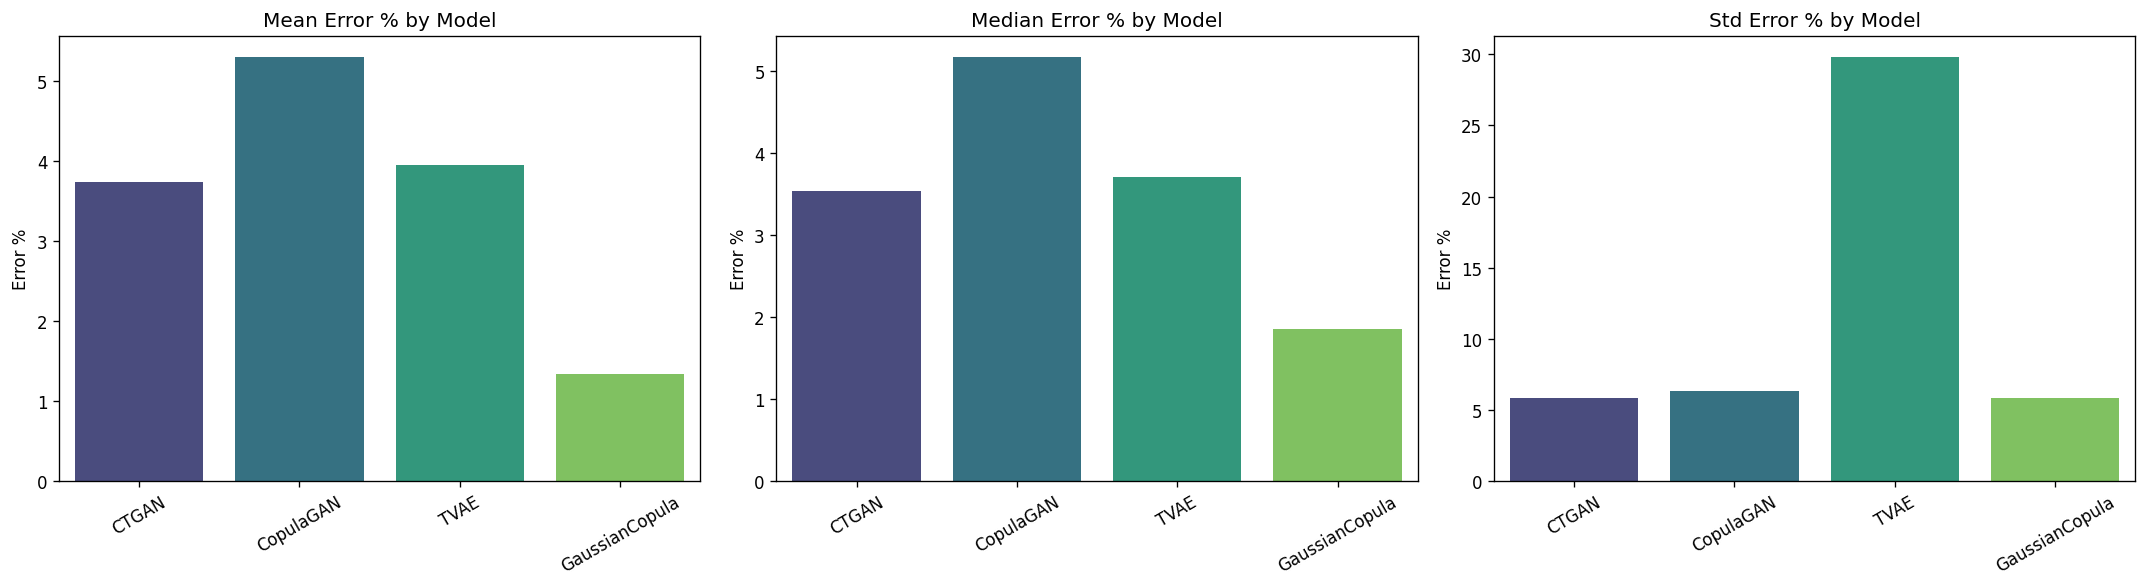

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "class"

real_df = data.copy()

# Numeric feature columns only
exclude_cols = {target_col}
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_cols]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_df = synth_df.reindex(columns=real_df.columns)

    real_num = real_df[num_cols].astype(np.float64)
    synth_num = synth_df[num_cols].astype(np.float64)

    real_means = real_num.mean()
    synth_means = synth_num.mean()

    real_stds = real_num.std(ddof=1)
    synth_stds = synth_num.std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average feature-distribution error by model (Secondary Mushroom Dataset)")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


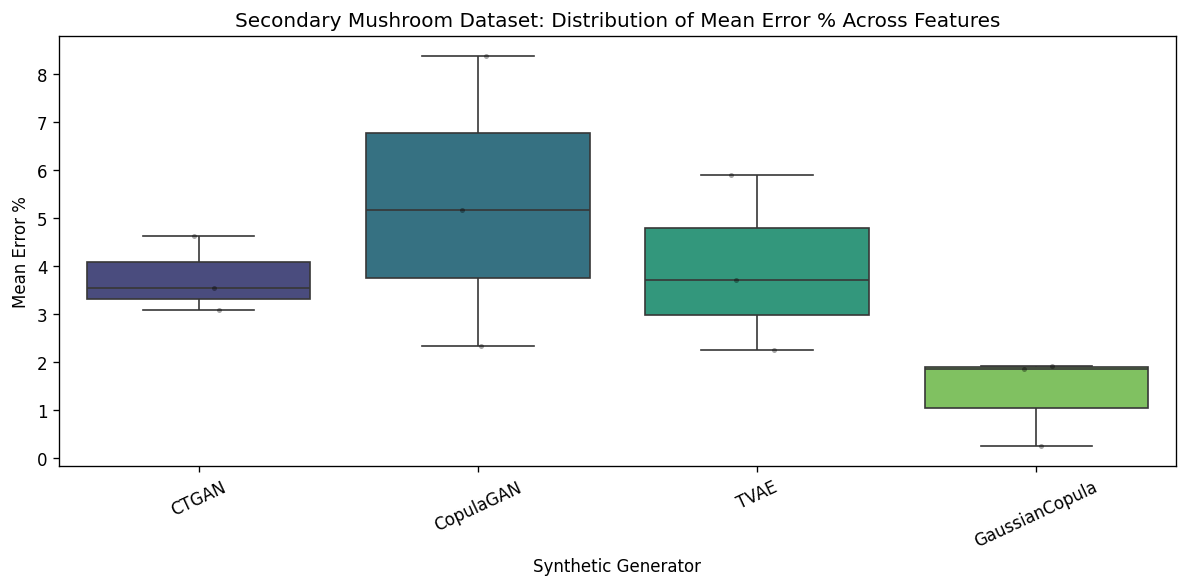

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in model_order
        if m in feature_error_by_model
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", order=model_order, palette="viridis")
sns.stripplot(
    data=dist_df,
    x="Model",
    y="Mean_Error_%",
    order=model_order,
    color="black",
    alpha=0.35,
    size=3
)

plt.title("Secondary Mushroom Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Synthetic Generator")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


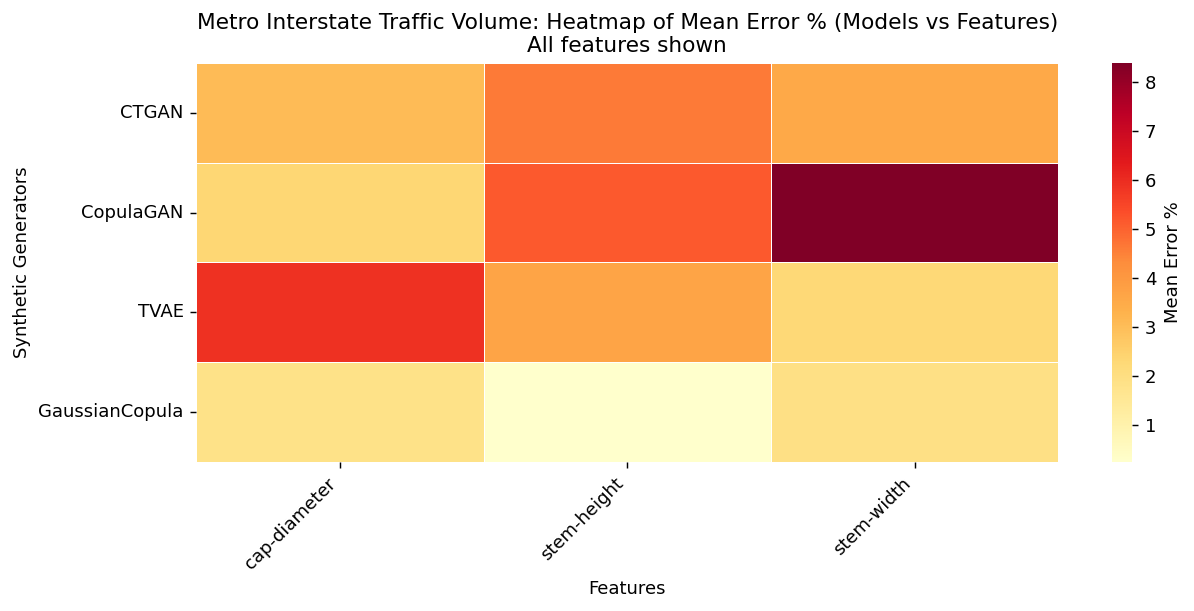

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
    if m in feature_error_by_model
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = (
        heatmap_df.mean(axis=0, skipna=True)
        .sort_values(ascending=False)
        .head(max_features)
        .index
    )
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Metro Interstate Traffic Volume: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Synthetic Generators")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

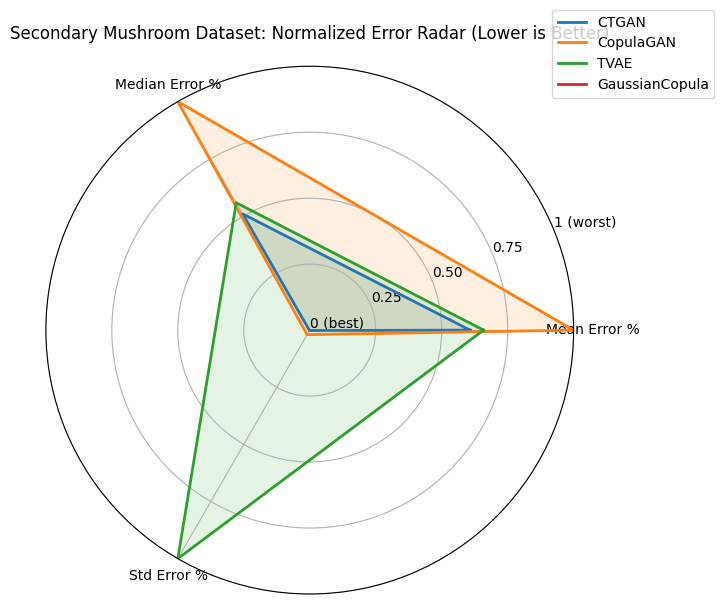

,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,0.607510,0.508485,0.001864
1,CopulaGAN,1.000000,1.000000,0.020041
2,TVAE,0.658639,0.557436,1.000000
3,GaussianCopula,0.000000,0.000000,0.000000


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

radar_df = summary_df[["Model"] + metrics].copy()
radar_df = radar_df.set_index("Model").reindex(model_order).dropna(how="all").reset_index()

norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Secondary Mushroom Dataset: Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))

plt.tight_layout()
plt.show()

display(norm_df)


Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,CTGAN,105.666667,120.0,149.0
1,CopulaGAN,125.000000,73.0,263.0
2,TVAE,114.333333,104.0,221.0
3,GaussianCopula,222.333333,42.0,595.0


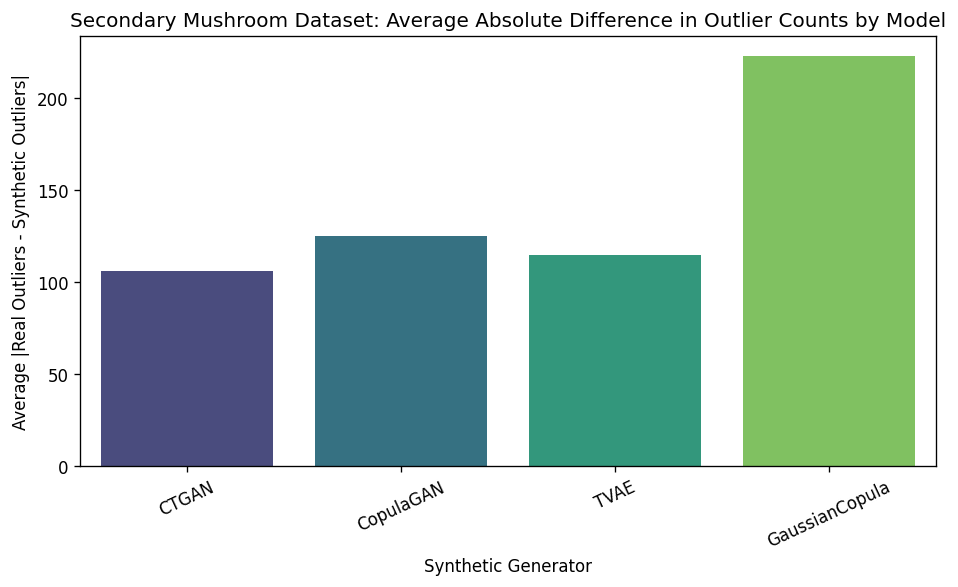

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "class"

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model].reindex(columns=real_df.columns).copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].mean()),
        "Median_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].median()),
        "Max_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].max())
    })

outlier_summary_df = (
    pd.DataFrame(rows)
    .set_index("Model")
    .reindex(model_order)
    .reset_index()
)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(
    data=outlier_summary_df,
    x="Model",
    y="Avg_Abs_Diff_Outlier_Count",
    order=model_order,
    palette="viridis"
)
plt.title("Secondary Mushroom Dataset: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Synthetic Generator")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 6. Cosine Similarity with Hungraian Mapping

In [40]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

target_col = "class"

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = len(data)
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows).reindex(columns=data.columns)

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real_matrix = normalize_rows(data[num_cols].to_numpy(dtype=np.float64))

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy(dtype=np.float64))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)

Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.843398  0.829697  0.850564  0.986714  0.926492  0.951370  0.955853   
R2   0.990451  0.921816  0.442578  0.725162  0.548514  0.615597  0.951761   
R3   0.711344  0.731712  0.941586  0.992113  0.985155  0.996187  0.864157   
R4   0.695690  0.736228  0.962307  0.979487  0.982354  0.998576  0.840993   
R5   0.646832  0.663703  0.946838  0.986908  0.996752  0.995567  0.823921   
R6   0.798445  0.848807  0.927382  0.957724  0.929492  0.970324  0.890099   
R7   0.996149  0.941378  0.497408  0.757201  0.590486  0.659001  0.963874   
R8   0.857278  0.870408  0.871779  0.972114  0.915086  0.952915  0.947166   
R9   0.565418  0.621874  0.985980  0.949098  0.990701  0.992109  0.741796   
R10  0.768827  0.757959  0.887549  0.999327  0.964835  0.975441  0.914840   

           S8        S9       S10  
R1   0.983253  0.984899  0.967462  
R2   0.795683  0.729776  0.654

,avg_cosine,max_cosine
CTGAN,0.867038,1.0
CopulaGAN,0.866490,1.0
TVAE,0.907055,1.0
GaussianCopula,0.885589,1.0


In [41]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

target_col = "class"

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c != target_col]

    R = real_data[num_cols].to_numpy(dtype=np.float64)
    S = synthetic_data[num_cols].to_numpy(dtype=np.float64)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df.reindex(columns=data.columns).copy()
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")



CTGAN - Top 10 Real -> Synthetic Matchings
01. R1721 -> S7059   cosine similarity = 1.0000
02. R4961 -> S7059   cosine similarity = 1.0000
03. R181 -> S7059   cosine similarity = 1.0000
04. R4371 -> S7059   cosine similarity = 1.0000
05. R4418 -> S7059   cosine similarity = 1.0000
06. R4202 -> S7059   cosine similarity = 1.0000
07. R9232 -> S7059   cosine similarity = 1.0000
08. R6654 -> S7059   cosine similarity = 1.0000
09. R3485 -> S7059   cosine similarity = 1.0000
10. R3667 -> S7059   cosine similarity = 1.0000

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R1721 -> S1424   cosine similarity = 1.0000
02. R4961 -> S1424   cosine similarity = 1.0000
03. R181 -> S1424   cosine similarity = 1.0000
04. R4371 -> S1424   cosine similarity = 1.0000
05. R4418 -> S1424   cosine similarity = 1.0000
06. R4202 -> S1424   cosine similarity = 1.0000
07. R9232 -> S1424   cosine similarity = 1.0000
08. R6654 -> S1424   cosine similarity = 1.0000
09. R3485 -> S1424   cosine similarity = 1.000

In [43]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

target_col = "class"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

def normalize_rows(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != target_col]

    R = real_df[num_cols].to_numpy(dtype=np.float64)
    S = synth_df[num_cols].to_numpy(dtype=np.float64)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

real_df = data.copy()
results = {}

for name in model_order:
    synth_df = synth_source[name].reindex(columns=real_df.columns).copy()

    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features excluding {target_col})")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")



CTGAN: Hungarian matching (cosine, numeric features excluding class)
Average cosine similarity (Hungarian match): 0.9888

R181 <-> S5831   cosine similarity = 1.0000
R49 <-> S1397   cosine similarity = 1.0000
R5642 <-> S8207   cosine similarity = 1.0000
R614 <-> S6946   cosine similarity = 1.0000
R1721 <-> S4748   cosine similarity = 1.0000
R1026 <-> S6586   cosine similarity = 1.0000
R264 <-> S6268   cosine similarity = 1.0000
R5333 <-> S9342   cosine similarity = 1.0000
R8645 <-> S9127   cosine similarity = 1.0000
R459 <-> S6614   cosine similarity = 1.0000

CopulaGAN: Hungarian matching (cosine, numeric features excluding class)
Average cosine similarity (Hungarian match): 0.9899

R49 <-> S1000   cosine similarity = 1.0000
R181 <-> S3084   cosine similarity = 1.0000
R614 <-> S3694   cosine similarity = 1.0000
R6271 <-> S9381   cosine similarity = 1.0000
R6654 <-> S9987   cosine similarity = 1.0000
R1721 <-> S1756   cosine similarity = 1.0000
R459 <-> S6614   cosine similarity = 1.0

In [44]:
import pandas as pd
import numpy as np

target_col = "class"

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Matchings_All_Models_Secondary_Mushroom.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results or model_name not in synth_source:
            continue

        model_res = results[model_name]

        if "row_ind" in model_res and "col_ind" in model_res:
            row_ind = np.asarray(model_res["row_ind"])
            col_ind = np.asarray(model_res["col_ind"])

            if "similarities" in model_res:
                score_key = "cosine_similarity"
                scores = np.asarray(model_res["similarities"])
            elif "distances" in model_res:
                score_key = "mahalanobis_distance"
                scores = np.asarray(model_res["distances"])
            else:
                raise KeyError(
                    f"No score array found for model {model_name}. "
                    "Expected 'similarities' or 'distances'."
                )

        elif "best_indices" in model_res and "best_sims" in model_res:
            row_ind = np.arange(len(model_res["best_indices"]))
            col_ind = np.asarray(model_res["best_indices"])
            score_key = "cosine_similarity"
            scores = np.asarray(model_res["best_sims"])
        else:
            raise KeyError(
                f"Unsupported results format for model {model_name}. "
                "Expected Hungarian keys or best-match keys."
            )

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            score_key: scores
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name].reindex(columns=real_df.columns).copy()
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        side_by_side.to_excel(writer, sheet_name=model_name[:31], index=False)
        combined_rows.append(side_by_side)

        summary_row = {
            "Model": model_name,
            "Num_Matches": len(scores),
            f"Avg_{score_key}": float(np.mean(scores)),
            f"Median_{score_key}": float(np.median(scores)),
            f"Min_{score_key}": float(np.min(scores)),
            f"Max_{score_key}": float(np.max(scores)),
        }
        summary_rows.append(summary_row)

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        sort_col = [c for c in summary_df.columns if c.startswith("Avg_")][0]
        ascending = False if "cosine" in sort_col else True
        summary_df = summary_df.sort_values(sort_col, ascending=ascending)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)

Saved: Matchings_All_Models_Secondary_Mushroom.xlsx


,Model,Num_Matches,Avg_cosine_similarity,Median_cosine_similarity,Min_cosine_similarity,Max_cosine_similarity
3,GaussianCopula,10000,0.994428,0.999056,0.743481,1.0
1,CopulaGAN,10000,0.989882,0.996548,0.708271,1.0
0,CTGAN,10000,0.988783,0.996751,0.787008,1.0
2,TVAE,10000,0.983587,0.995253,0.677054,1.0


# 7. Mahalanobis distance with Hungrain Mapping  

In [45]:
import numpy as np
from numpy.linalg import inv, LinAlgError

target_col = "class"

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

data_numeric = data[num_cols].dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=np.float64)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real mushroom feature data.")
print(f"Used features (excluding target): {len(num_cols)}")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real mushroom feature data.
Used features (excluding target): 3
Mean shape: (3,), Inv_cov shape: (3, 3)


In [46]:
import pandas as pd
import numpy as np

mahalanobis_results = {}
target_col = "class"

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synth_source[name].reindex(columns=data.columns).copy()
    synth_numeric = synth_df[num_cols].to_numpy(dtype=np.float64)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real mushroom distribution (lower is better):")
display(summary)

Mahalanobis distance to real mushroom distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
TVAE,1.000366,0.815732,0.874231,0.016341,13.438043
GaussianCopula,1.352271,1.181297,0.772350,0.042121,8.175018
CTGAN,1.480560,1.146545,1.154974,0.062055,14.410082
CopulaGAN,1.600030,1.187785,1.417158,0.084978,14.767655


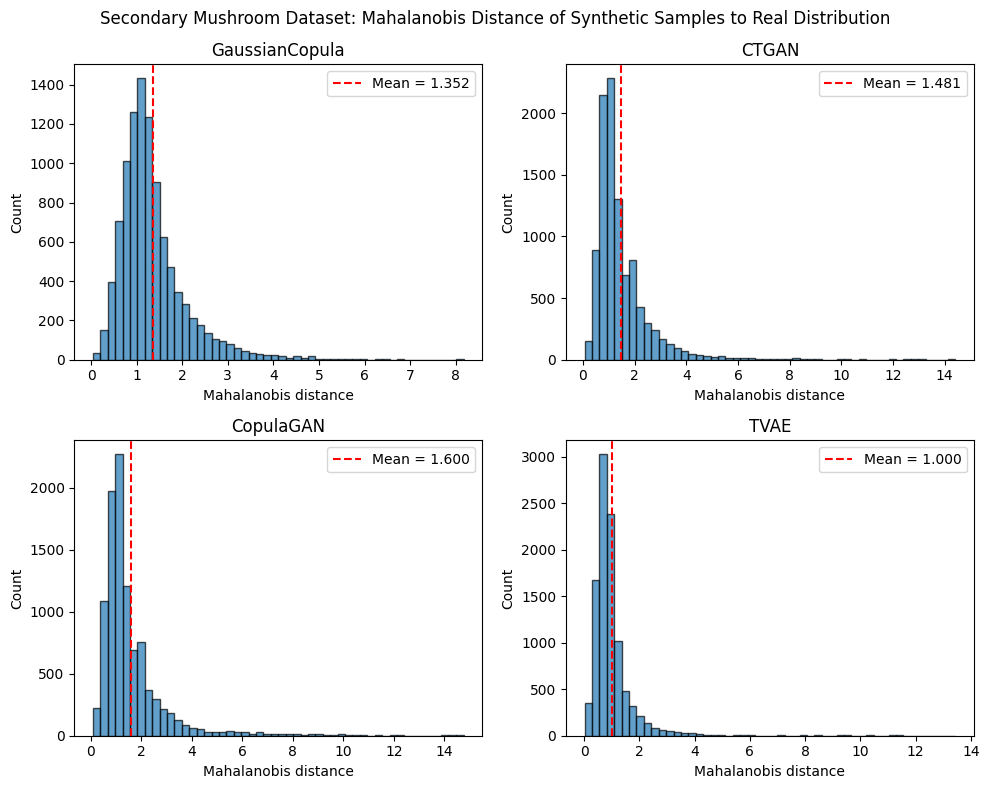

In [47]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Secondary Mushroom Dataset: Mahalanobis Distance of Synthetic Samples to Real Distribution",
    fontsize=12
)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_mushroom_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [48]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

target_col = "class"

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

real_matrix = data[num_cols].to_numpy(dtype=np.float64)
n_samples = len(real_matrix)

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synth_source[name].reindex(columns=data.columns)[num_cols].to_numpy(dtype=np.float64)
    assert synth_numeric.shape[0] == n_samples, (
        f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"
    )

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Secondary Mushroom Dataset - Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)

Secondary Mushroom Dataset - Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
GaussianCopula,0.394057,0.225473,0.665611,8.674031
TVAE,0.433018,0.239130,0.581950,7.677494
CTGAN,0.486169,0.267244,0.643229,7.073249
CopulaGAN,0.539467,0.287424,0.710618,7.220497


In [49]:
import numpy as np
import pandas as pd

target_col = "class"

def greedy_one_to_one_matching_fast(D):
    n_rows, n_cols = D.shape
    n_match = min(n_rows, n_cols)

    used_rows = np.zeros(n_rows, dtype=bool)
    used_cols = np.zeros(n_cols, dtype=bool)

    flat_order = np.argsort(D, axis=None)
    pairs = []

    for idx in flat_order:
        i = idx // n_cols
        j = idx % n_cols
        if not used_rows[i] and not used_cols[j]:
            used_rows[i] = True
            used_cols[j] = True
            pairs.append((i, j, float(D[i, j])))
            if len(pairs) == n_match:
                break

    distances = np.array([p[2] for p in pairs], dtype=np.float64)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

X_real_full = data[num_cols].to_numpy(dtype=np.float64)

MAX_ROWS = 2000
rng = np.random.default_rng(42)

if len(X_real_full) > MAX_ROWS:
    real_idx = rng.choice(len(X_real_full), size=MAX_ROWS, replace=False)
else:
    real_idx = np.arange(len(X_real_full))

X_real = X_real_full[real_idx]

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    X_synth_full = synth_source[name].reindex(columns=data.columns)[num_cols].to_numpy(dtype=np.float64)

    if len(X_synth_full) > MAX_ROWS:
        synth_idx = rng.choice(len(X_synth_full), size=MAX_ROWS, replace=False)
    else:
        synth_idx = np.arange(len(X_synth_full))

    X_synth = X_synth_full[synth_idx]

    D = pairwise_mahalanobis(X_real, X_synth, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    total_g, mean_g, _ = greedy_one_to_one_matching_fast(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Rows_Used_For_Greedy": int(min(len(X_real), len(X_synth))),
        "Greedy total (sampled)": total_g,
        "Hungarian total (full)": h_total,
        "Greedy mean (sampled)": mean_g,
        "Hungarian mean (full)": h_mean,
        "Total diff": total_g - h_total,
        "Mean diff": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Secondary Mushroom Dataset - Greedy one-to-one matching (fast sampled version):")
display(greedy_summary)

print("\nComparison table:")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)

Secondary Mushroom Dataset - Greedy one-to-one matching (fast sampled version):


,total_distance,mean_distance
Model,,
GaussianCopula,1076.896073,0.538448
CTGAN,1231.793748,0.615897
CopulaGAN,1396.528004,0.698264
TVAE,1088.089868,0.544045



Comparison table:


,Rows_Used_For_Greedy,Greedy total (sampled),Hungarian total (full),Greedy mean (sampled),Hungarian mean (full),Total diff,Mean diff
Model,,,,,,,
GaussianCopula,2000,1076.896073,3940.570978,0.538448,0.394057,-2863.674905,0.144391
CTGAN,2000,1231.793748,4861.690905,0.615897,0.486169,-3629.897157,0.129728
CopulaGAN,2000,1396.528004,5394.674015,0.698264,0.539467,-3998.146011,0.158797
TVAE,2000,1088.089868,4330.184728,0.544045,0.433018,-3242.094860,0.111026


In [50]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "class"

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synth_source[name].reindex(columns=real_df.columns).copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 3
GaussianCopula: avg matched Mahalanobis distance = 0.3941
CTGAN: avg matched Mahalanobis distance = 0.4862
CopulaGAN: avg matched Mahalanobis distance = 0.5395
TVAE: avg matched Mahalanobis distance = 0.4330


In [51]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "class"

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synth_source[name].reindex(columns=real_df.columns).copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")

Using numeric non-target features: 3
GaussianCopula: avg matched Mahalanobis distance = 0.3941
CTGAN: avg matched Mahalanobis distance = 0.4862
CopulaGAN: avg matched Mahalanobis distance = 0.5395
TVAE: avg matched Mahalanobis distance = 0.4330


In [52]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

target_col = "class"

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_df = data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=np.float64)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synth_source[model_name].reindex(columns=real_df.columns).copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=np.float64)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")


CTGAN - Hungarian mappings for R1 to R20:
R1 -> S9975   distance = 0.2193
R2 -> S3914   distance = 1.4470
R3 -> S27   distance = 0.1680
R4 -> S7327   distance = 0.3421
R5 -> S9009   distance = 0.7605
R6 -> S8174   distance = 0.0991
R7 -> S8838   distance = 0.1564
R8 -> S5347   distance = 0.1319
R9 -> S2933   distance = 0.1778
R10 -> S5623   distance = 0.2978
R11 -> S5000   distance = 0.4084
R12 -> S2529   distance = 0.1230
R13 -> S7086   distance = 0.6731
R14 -> S3368   distance = 0.0246
R15 -> S8817   distance = 0.0345
R16 -> S6197   distance = 0.0550
R17 -> S21   distance = 0.4250
R18 -> S9280   distance = 0.2247
R19 -> S8659   distance = 0.3469
R20 -> S1589   distance = 0.1740

CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> S3525   distance = 0.5377
R2 -> S1228   distance = 0.0253
R3 -> S1939   distance = 0.1939
R4 -> S161   distance = 0.1215
R5 -> S6522   distance = 0.8481
R6 -> S9580   distance = 0.0852
R7 -> S4438   distance = 0.0521
R8 -> S8393   distance = 0.6697
R9 -> S2

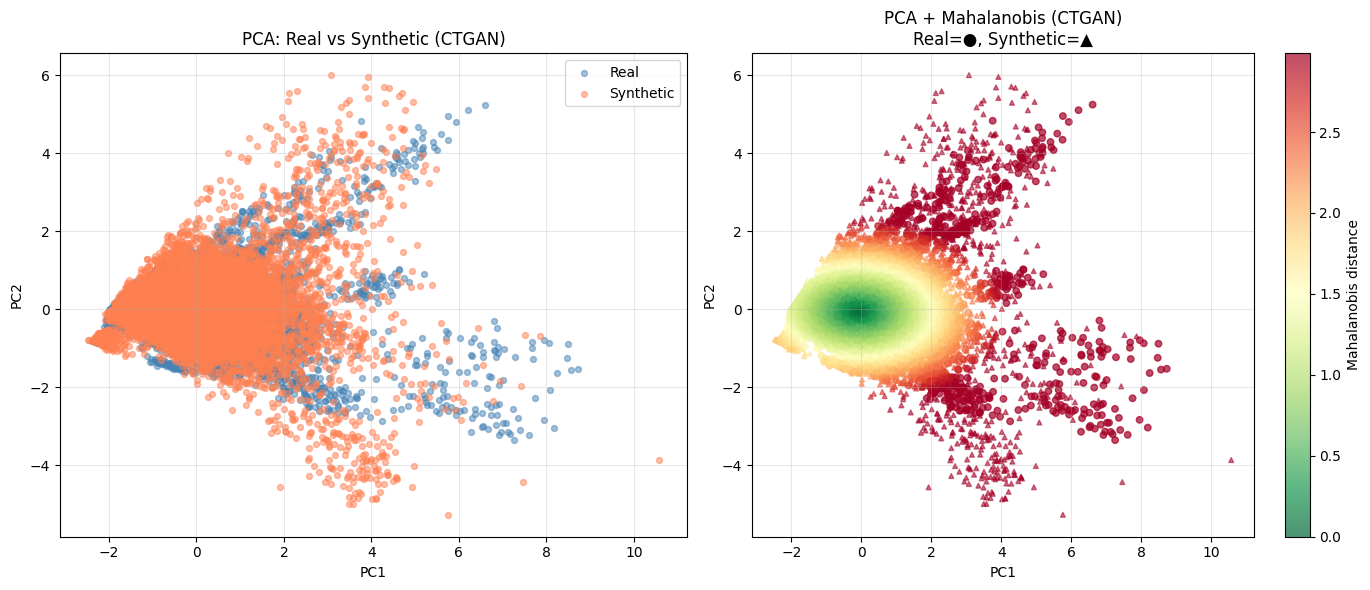

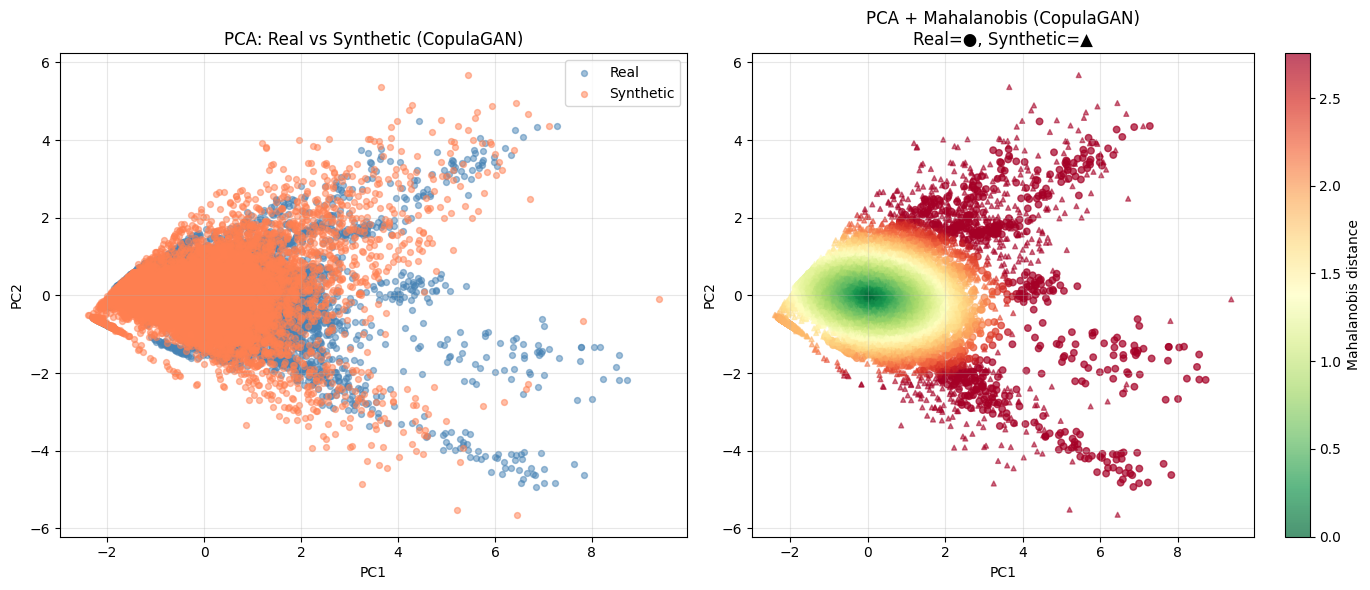

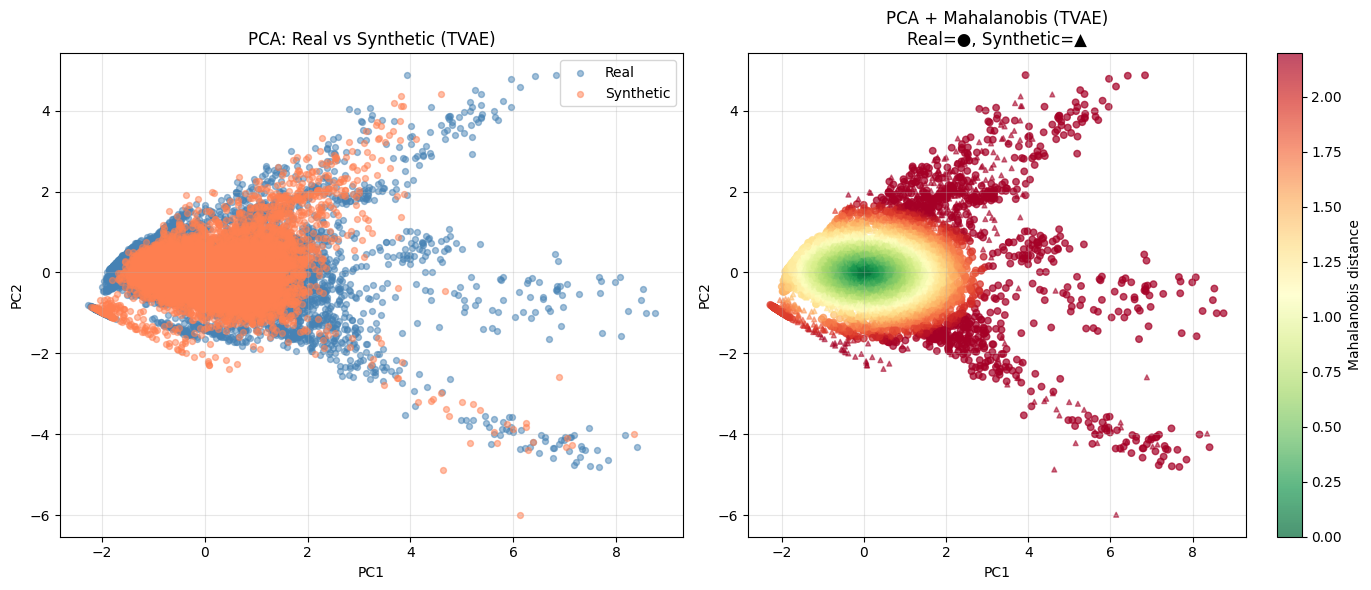

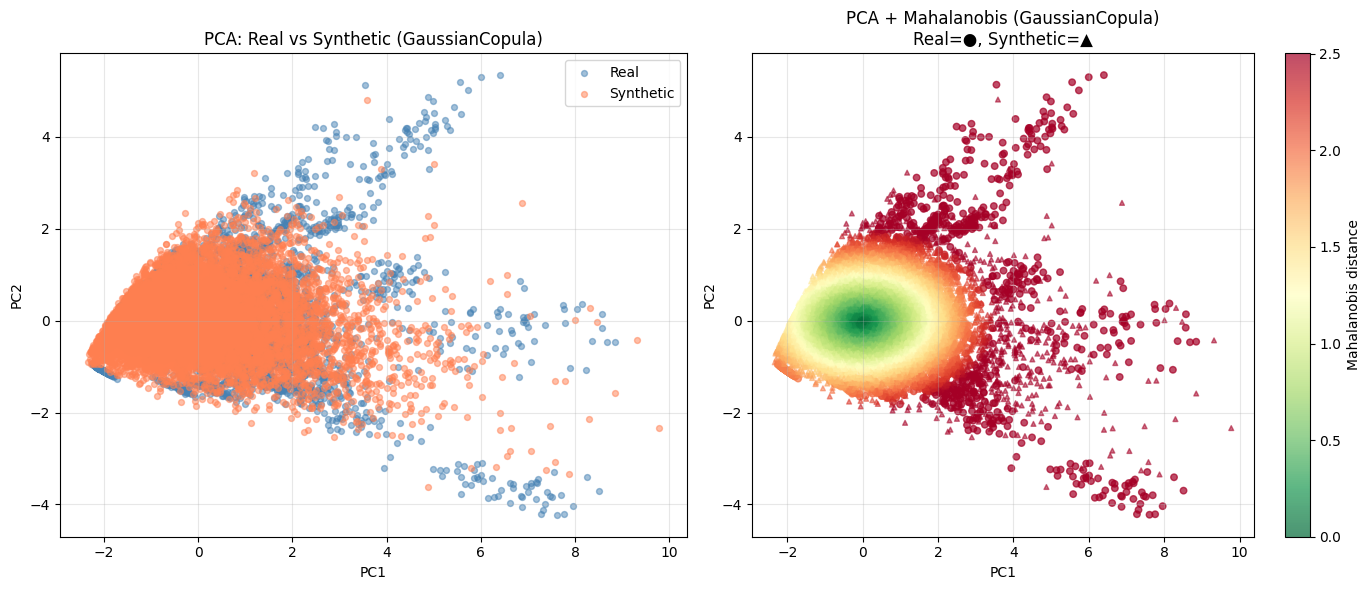

Metro Interstate Traffic Volume - PCA + Mahalanobis summary:


,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
2,TVAE,1.091656,0.796929,-0.294726
1,CopulaGAN,1.099226,1.115481,0.016255
3,GaussianCopula,1.093570,1.124839,0.031268
0,CTGAN,1.104006,1.213082,0.109076


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

target_col = "traffic_volume"

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c not in ["ID", "Diabetes_binary", target_col]]

X_r = real_df[feature_cols].to_numpy(dtype=np.float64)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=np.float64)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = np.linalg.pinv(cov_z + reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
print("Metro Interstate Traffic Volume - PCA + Mahalanobis summary:")
display(summary_df)

In [54]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models_Secondary_Mushroom.xlsx"
):
    dataset_name = "Secondary_Mushroom"
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            synth_df = synth_df.reindex(columns=real_df.columns)

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Dataset": dataset_name,
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = f"{dataset_name}_{model_name}"[:31]
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)

            summary_rows.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name=f"{dataset_name}_Summary"[:31], index=False)

    print(f"Excel file created: {filename}")

# ---- Run ----
target_col = "class"
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synth_source,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_Four_Models_Secondary_Mushroom.xlsx"
)


Excel file created: Hungarian_Mahalanobis_Four_Models_Secondary_Mushroom.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [55]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_confidence_per_sample_classification(model, X):
    proba = model.predict_proba(X)
    return np.max(proba, axis=1)  # higher confidence => more likely member

def privacy_metrics_mia_classification(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train.astype(str))
    y_test_enc = le.transform(y_test.astype(str))

    model.fit(X_train_s, y_train_enc)

    conf_train = model_confidence_per_sample_classification(model, X_train_s)
    conf_test = model_confidence_per_sample_classification(model, X_test_s)

    scores = np.concatenate([conf_train, conf_test])
    labels = np.concatenate([np.ones(len(conf_train)), np.zeros(len(conf_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

target_col = "class"
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_df = data.copy()

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

synth_df = synth_source["GaussianCopula"].reindex(columns=real_df.columns).copy()

X_train = real_df[feature_cols].to_numpy(dtype=np.float64)
y_train = real_df[target_col].to_numpy()

X_test = synth_df[feature_cols].to_numpy(dtype=np.float64)
y_test = synth_df[target_col].to_numpy()

model = LogisticRegression(max_iter=1000, random_state=42)
metrics = privacy_metrics_mia_classification(model, X_train, y_train, X_test, y_test)
print(metrics)


{'AUC': 0.49494582000000004, 'Advantage': np.float64(0.005600000000000049), 'TPR_at_FPR_001': np.float64(0.012)}


In [56]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

target_col = "class"

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]
X_train = data[feature_cols].to_numpy(dtype=np.float64)

if "synthetic_datasets" in globals():
    synth_source = synthetic_datasets
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_datasets` or `synthetic_data`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synth_source[model_name].reindex(columns=data.columns)[feature_cols].to_numpy(dtype=np.float64)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("Secondary Mushroom Dataset - MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)

Secondary Mushroom Dataset - MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CopulaGAN,0.601795,0.1639,0.0207,1.283229,1.600029
1,GaussianCopula,0.593068,0.1688,0.0228,1.283229,1.352269
2,CTGAN,0.589119,0.1335,0.0215,1.283229,1.480558
3,TVAE,0.393628,0.0001,0.0047,1.283229,1.000365
